## Proyecto de Estadística - Universidad de La Habana, MATCOM

### Análisis Exploratorio de Datos - BRFSS 2011 vs 2022

---

### Módulos Analizados
- Estado de Salud General
- Condiciones Crónicas (Cardiovascular, Asma, Diabetes, Depresión)
- Tabaco y Alcohol
- Demografía
- Actividad Física y Sueño
- ACEs (Experiencias Adversas en la Infancia)
- **Nuevos 2022**: COVID-19, Marihuana, Bienestar Social

In [1]:
# CELDA 1: Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print('✅ Librerías importadas')

✅ Librerías importadas


In [2]:
# CELDA 2: Cargar datos - MODIFICAR RUTAS
df_2011 = pd.read_csv(r'c:\Users\Melissa Maureen\Documents\estData\data\2011.csv')
df_2022 = pd.read_csv(r'c:\Users\Melissa Maureen\Documents\estData\data\brfss2022.csv')

print(f'✅ Datos cargados')
print(f'   2011: {df_2011.shape[0]:,} filas × {df_2011.shape[1]} columnas')
print(f'   2022: {df_2022.shape[0]:,} filas × {df_2022.shape[1]} columnas')

✅ Datos cargados
   2011: 506,467 filas × 454 columnas
   2022: 445,132 filas × 326 columnas


In [3]:
# CELDA 3: Variables de interés
VARS_2011 = {
    'salud': ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH'],
    'cronicas': ['BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 
                 'CVDINFR4', 'CVDCRHD4', 'ASTHMA3', 'ASTHNOW', 'ADDEPEV2', 'DIABETE3'],
    'tabaco': ['SMOKE100', 'SMOKDAY2'],
    'alcohol': ['ALCDAY5', 'AVEDRNK2', 'DRNKANY5', '_RFBING5', '_DRNKMO4', '_RFDRHV4'],
    'demo': ['AGE', 'HISPANC2', 'MARITAL', 'EDUCA', 'EMPLOY', 'INCOME2', 'SEX'],
    'acceso': ['CHECKUP1'],
    'sueno': ['QLREST2', 'SLEPTIME', 'SLEPDAY'],
    'calidad_vida': ['QLMENTL2', 'QLSTRES2', 'QLHLTH2'],
    'asma': ['ASATTACK'],
    'aces': ['ACEDEPRS', 'ACEDRINK', 'ACEDRUGS', 'ACEPRISN', 'ACEDIVRC',
             'ACEPUNCH', 'ACEHURT', 'ACESWEAR', 'ACETOUCH', 'ACETTHEM', 'ACEHVSEX'],
    'calculadas': ['_RFHLTH', '_SMOKER3', '_RFSMOK3', '_BMI5', '_BMI5CAT', 
                   '_RFBMI5', '_TOTINDA', '_EDUCAG', '_AGE_G', '_AGEG5YR', '_PACAT']
}

VARS_2022 = {
    'salud': ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH'],
    'cronicas': ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW',
                 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 
                 'HAVARTH4', 'DIABETE4'],
    'tabaco': ['SMOKE100', 'SMOKDAY2', 'ECIGNOW2'],
    'alcohol': ['ALCDAY4', 'AVEDRNK3', 'DRNKANY6', '_RFBING6', '_DRNKWK2', '_RFDRHV8'],
    'demo': ['MARITAL', 'EDUCA', 'EMPLOY1', 'INCOME3', 'SEXVAR'],
    'acceso': ['CHECKUP1'],
    'sueno': ['SLEPTIM1'],
    'aces': ['ACEDEPRS', 'ACEDRINK', 'ACEDRUGS', 'ACEPRISN', 'ACEDIVRC',
             'ACEPUNCH', 'ACEHURT1', 'ACESWEAR', 'ACETOUCH', 'ACETTHEM', 
             'ACEHVSEX', 'ACEADSAF', 'ACEADNED'],
    'calculadas': ['_RFHLTH', '_SMOKER3', '_RFSMOK3', '_BMI5', '_BMI5CAT', 
                   '_RFBMI5', '_TOTINDA', '_EDUCAG', '_AGE_G', '_AGEG5YR', '_AGE80', '_SEX'],
    'covid': ['COVIDPOS', 'COVIDSMP', 'COVIDPRM'],
    'marihuana': ['MARIJAN1', 'MARJSMOK', 'MARJEAT', 'MARJVAPE', 'USEMRJN4'],
    'bienestar': ['LSATISFY', 'EMTSUPRT', 'SDHISOLT', 'SDHEMPLY', 'FOODSTMP',
                  'SDHFOOD1', 'SDHBILLS', 'SDHUTILS', 'SDHTRNSP', 'SDHSTRE1']
}
print('✅ Variables de interés definidas')

✅ Variables de interés definidas


In [4]:
# CELDA 4: Significados de las variables
SIGNIFICADOS = {
    'GENHLTH': 'Salud general autopercibida',
    'PHYSHLTH': 'Días de mala salud física (últimos 30 días)',
    'MENTHLTH': 'Días de mala salud mental (últimos 30 días)',
    'POORHLTH': 'Días con limitaciones por mala salud',
    'SLEPTIME': 'Horas de sueño promedio',
    'SLEPTIM1': 'Horas de sueño promedio',
    'SLEEP': 'Horas de sueño promedio',
    '_SMOKER3': 'Estado de fumador (calculada)',
    '_BMI5CAT': 'Categoría de Índice de Masa Corporal',
    '_RFBMI5': 'Sobrepeso/Obesidad (calculada)',
    '_TOTINDA': 'Actividad física en últimos 30 días',
    '_PACAT': 'Categoría de actividad física',
    '_AGE_G': 'Grupo de edad (calculada)',
    'ASTHNOW': 'Asma actual',
    '_EDUCAG': 'Nivel educativo (calculada)',
    'SEX': 'Sexo',
    '_SEX': 'Sexo (calculada)',
    'MARITAL': 'Estado civil',
    'EMPLOY': 'Situación de empleo',
    'EMPLOY1': 'Situación de empleo',
    'ADDEPEV2': 'Diagnóstico de trastorno depresivo',
    'ADDEPEV3': 'Diagnóstico de trastorno depresivo',
    'BPHIGH4': 'Diagnóstico de presión arterial alta',
    'BPMEDS': 'Toma medicamentos para la presión',
    'TOLDHI2': 'Diagnóstico de colesterol alto',
    'CVDINFR4': 'Diagnóstico de infarto de miocardio',
    'CVDCRHD4': 'Diagnóstico de enfermedad coronaria',
    'CVDSTRK3': 'Diagnóstico de derrame cerebral',
    'ASTHMA3': 'Diagnóstico de asma',
    'ASTHNOW': 'Asma actual',
    'HAVARTH3': 'Diagnóstico de artritis',
    'HAVARTH4': 'Diagnóstico de artritis',
    'DIABETE3': 'Diagnóstico de diabetes',
    'DIABETE4': 'Diagnóstico de diabetes',
    'LSATISFY': 'Satisfacción con la vida',
    'EMTSUPRT': 'Apoyo emocional disponible',
    'SDHISOLT': 'Frecuencia de aislamiento social',
    'ECIGNOW2': 'Uso actual de cigarrillos electrónicos',
    'MARJSMOK': 'Consumo de marihuana fumada',
    'ACEDEPRS': 'ACE: Padre/madre deprimido',
    'ACEDRINK': 'ACE: Padre/madre alcohólico',
    'ACEDRUGS': 'ACE: Padre/madre consumía drogas',
    'ACEPRISN': 'ACE: Padre/madre en prisión',
    'ACEDIVRC': 'ACE: Padres divorciados/separados',
    'ACEPUNCH': 'ACE: Golpeado/empujado',
    'ACESWEAR': 'ACE: Insultos/humillación',
    'ACETOUCH': 'ACE: Tocado sexualmente',
    'ACETTHEM': 'ACE: Obligado a tocar',
    'ACEHVSEX': 'ACE: Forzado a tener sexo'
}
print('✅ Significados definidos')

✅ Significados definidos


In [5]:
# CELDA 5: Etiquetas
ETIQUETAS = {
    'GENHLTH': {1: 'Excelente', 2: 'Muy buena', 3: 'Buena', 4: 'Regular', 5: 'Mala', 7: 'No sabe', 9: 'Rechazó'},
    '_SMOKER3': {1: 'Fuma diario', 2: 'Fuma algunos días', 3: 'Ex-fumador', 4: 'Nunca fumó', 9: 'No sabe'},
    '_BMI5CAT': {1: 'Bajo peso', 2: 'Normal', 3: 'Sobrepeso', 4: 'Obeso'},
    '_TOTINDA': {1: 'Activo', 2: 'Inactivo'},
    '_PACAT': {1: 'Altamente activo', 2: 'Activo', 3: 'Insuficiente', 4: 'Inactivo'},
    '_RFHLTH': {1: 'Buena salud', 2: 'Mala/Regular'},
    '_AGE_G': {1: '18-24', 2: '25-34', 3: '35-44', 4: '45-54', 5: '55-64', 6: '65+'},
    '_EDUCAG': {1: 'Sin secundaria', 2: 'Secundaria', 3: 'Algo universidad', 4: 'Universidad', 9: 'No sabe'},
    'SEX': {1: 'Masculino', 2: 'Femenino'},
    '_SEX': {1: 'Masculino', 2: 'Femenino'},
    'MARITAL': {1: 'Casado/a', 2: 'Divorciado/a', 3: 'Viudo/a', 4: 'Separado/a', 5: 'Nunca casado/a', 6: 'Pareja de hecho'},
    'EMPLOY': {1: 'Empleado', 2: 'Autoempleado', 3: 'Desempleado >1 año', 4: 'Desempleado <1 año', 5: 'Ama de casa', 6: 'Estudiante', 7: 'Retirado', 8: 'Incapacitado'},
    'EMPLOY1': {1: 'Empleado', 2: 'Autoempleado', 3: 'Desempleado >1 año', 4: 'Desempleado <1 año', 5: 'Ama de casa', 6: 'Estudiante', 7: 'Retirado', 8: 'Incapacitado'},
    'ADDEPEV2': {1: 'Sí', 2: 'No'},
    'ADDEPEV3': {1: 'Sí', 2: 'No'},
    'BPHIGH4': {1: 'Sí', 2: 'Sí (embarazo)', 3: 'No', 4: 'Pre-hipertensión'},
    'BPMEDS': {1: 'Sí', 2: 'No'},
    'TOLDHI2': {1: 'Sí', 2: 'No'},
    'CVDINFR4': {1: 'Sí', 2: 'No'},
    'CVDCRHD4': {1: 'Sí', 2: 'No'},
    'CVDSTRK3': {1: 'Sí', 2: 'No'},
    'ASTHMA3': {1: 'Sí', 2: 'No'},
    'ASTHNOW': {1: 'Sí', 2: 'No'},
    'DIABETE3': {1: 'Sí', 2: 'Sí (embarazo)', 3: 'No', 4: 'Pre-diabetes'},
    'DIABETE4': {1: 'Sí', 2: 'Sí (embarazo)', 3: 'No', 4: 'Pre-diabetes'},
    'LSATISFY': {1: 'Muy satisfecho', 2: 'Satisfecho', 3: 'Insatisfecho', 4: 'Muy insatisfecho'},
    'EMTSUPRT': {1: 'Siempre', 2: 'Usualmente', 3: 'A veces', 4: 'Rara vez', 5: 'Nunca'},
    'SDHISOLT': {1: 'Siempre', 2: 'Usualmente', 3: 'A veces', 4: 'Rara vez', 5: 'Nunca'},
    'ECIGNOW2': {1: 'Todos los días', 2: 'Algunos días', 3: 'No actualmente', 4: 'Nunca ha usado'},
}
print('✅ Etiquetas definidas')

✅ Etiquetas definidas


In [6]:
# CELDA 6: Funciones básicas
def info_dataset(df, nombre):
    print(f'\n{"="*60}')
    print(f'📊 {nombre}: {df.shape[0]:,} filas × {df.shape[1]} columnas')
    print(f'Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

def estadisticos_numericos(df, variables, nombre):
    print(f'\n📈 ESTADÍSTICOS: {nombre}')
    vars_disp = [v for v in variables if v in df.columns]
    for var in vars_disp:
        col = pd.to_numeric(df[var], errors='coerce').dropna()
        col = col[col < 77]
        if len(col) > 0:
            print(f'{var:12} N={len(col):,}  Media={col.mean():.2f}  Mediana={col.median():.2f}  Std={col.std():.2f}  Mín={col.min():.0f}  Máx={col.max():.0f}')

def frecuencias(df, variable, etiquetas=None, titulo=None):
    if variable not in df.columns:
        print(f'⚠️ {variable} no encontrada')
        return None
    freq = df[variable].value_counts(dropna=False).sort_index()
    pct = (freq / freq.sum()) * 100
    result = pd.DataFrame({'Código': freq.index, 'Frecuencia': freq.values, 'Porcentaje': pct.round(2).values})
    if etiquetas and variable in etiquetas:
        result['Etiqueta'] = result['Código'].map(etiquetas[variable])
    print(f'\n📌 {titulo or variable} - Registros totales: {len(df):,}')
    print(result.to_string(index=False))
    return result

print('✅ Funciones básicas definidas')

✅ Funciones básicas definidas


In [7]:
# CELDA 7: Funciones de visualización
def plot_comparacion_barras(df_2011, df_2022, variable, etiquetas=None, titulo=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, (df, year, color) in enumerate([(df_2011, 2011, 'steelblue'), (df_2022, 2022, 'coral')]):
        if variable not in df.columns:
            axes[i].text(0.5, 0.5, f'{variable} no disponible', ha='center', transform=axes[i].transAxes)
            continue
        freq = df[variable].value_counts(normalize=True).sort_index() * 100
        labels = [etiquetas[variable].get(idx, str(idx)) for idx in freq.index] if etiquetas and variable in etiquetas else [str(idx) for idx in freq.index]
        bars = axes[i].bar(range(len(freq)), freq.values, color=color, alpha=0.8)
        axes[i].set_xticks(range(len(freq)))
        axes[i].set_xticklabels(labels, rotation=45, ha='right')
        axes[i].set_ylabel('Porcentaje (%)')
        axes[i].set_title(f'{year}')
        for bar, val in zip(bars, freq.values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)
    plt.suptitle(titulo or f'{variable}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'comp_{variable}.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_histogramas(df_2011, df_2022, variable, titulo=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    for df, year, color in [(df_2011, 2011, 'steelblue'), (df_2022, 2022, 'coral')]:
        if variable not in df.columns: continue
        data = pd.to_numeric(df[variable], errors='coerce').dropna()
        data = data[data < 77]
        ax.hist(data, bins=30, density=True, alpha=0.5, label=f'{year} (μ={data.mean():.2f})', color=color)
        ax.axvline(data.mean(), color=color, linestyle='--', linewidth=2)
    ax.set_xlabel(variable)
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.set_title(titulo or f'{variable}: 2011 vs 2022')
    plt.tight_layout()
    plt.savefig(f'hist_{variable}.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_boxplots(df_2011, df_2022, variable, titulo=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    data_list, labels = [], []
    for df, year in [(df_2011, 2011), (df_2022, 2022)]:
        if variable not in df.columns: continue
        data = pd.to_numeric(df[variable], errors='coerce').dropna()
        data = data[data < 77]
        data_list.append(data)
        labels.append(str(year))
    bp = ax.boxplot(data_list, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['steelblue', 'coral']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    medias = [d.mean() for d in data_list]
    ax.scatter(range(1, len(data_list)+1), medias, color='red', s=100, zorder=3, marker='D', label='Media')
    ax.legend()
    ax.set_title(titulo or f'{variable}')
    plt.tight_layout()
    plt.savefig(f'box_{variable}.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_prevalencia_aces(df1, df2, aces_vars, etiquetas_aces, vars_invertidas=None):
    """Grafica prevalencia de ACEs corrigiendo variables con codificación invertida."""
    if vars_invertidas is None:
        vars_invertidas = []
    
    def calcular_prevalencia(df, vars_list):
        prev = {}
        for var in vars_list:
            if var in df.columns:
                validos = df[var].isin([1, 2]).sum()
                if validos > 0:
                    # Variables invertidas: código 2 = SÍ experimentó
                    if var in vars_invertidas:
                        prev[var] = (df[var] == 2).sum() / validos * 100
                    else:
                        prev[var] = (df[var] == 1).sum() / validos * 100
        return prev
    
    prev_2011 = calcular_prevalencia(df1, aces_vars)
    prev_2022 = calcular_prevalencia(df2, aces_vars)
    
    print('\n--- Prevalencia ACEs 2011 (% que SÍ experimentó) ---')
    for var, pct in prev_2011.items():
        marca = " *" if var in vars_invertidas else ""
        print(f'{etiquetas_aces.get(var, var)}: {pct:.1f}%{marca}')
    print('\n--- Prevalencia ACEs 2022 (% que SÍ experimentó) ---')
    for var, pct in prev_2022.items():
        marca = " *" if var in vars_invertidas else ""
        print(f'{etiquetas_aces.get(var, var)}: {pct:.1f}%{marca}')
    if vars_invertidas:
        print('\n* Variables con codificación invertida (corregidas)')
    
    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(aces_vars))
    width = 0.35
    prev_2011_vals = [prev_2011.get(ace, 0) for ace in aces_vars]
    prev_2022_vals = [prev_2022.get(ace, 0) for ace in aces_vars]
    bars1 = ax.bar(x - width/2, prev_2011_vals, width, label='2011', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, prev_2022_vals, width, label='2022', color='coral', alpha=0.8)
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, 
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, 
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_xlabel('Tipo de ACE')
    ax.set_ylabel('Prevalencia (% que SÍ experimentó)')
    ax.set_title('Prevalencia de ACEs: 2011 vs 2022\n(Porcentaje que SÍ experimentó cada adversidad)', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([etiquetas_aces.get(ace, ace) for ace in aces_vars], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(max(prev_2011_vals), max(prev_2022_vals)) * 1.15)
    if vars_invertidas:
        ax.text(0.02, 0.98, '* Variables invertidas corregidas', 
                transform=ax.transAxes, fontsize=9, verticalalignment='top', style='italic', color='gray')
    plt.tight_layout()
    plt.savefig('prevalencia_aces.png', dpi=150, bbox_inches='tight')
    plt.show()
    return prev_2011, prev_2022

print('✅ Funciones de visualización definidas')

✅ Funciones de visualización definidas


In [8]:
# CELDA 8: Funciones de dispersión y correlación
def plot_dispersion(df, var_x, var_y, titulo=None, color='steelblue'):
    if var_x not in df.columns or var_y not in df.columns:
        print(f'⚠️ Variable(s) no encontrada(s)')
        return None
    x = pd.to_numeric(df[var_x], errors='coerce')
    y = pd.to_numeric(df[var_y], errors='coerce')
    mask = (x < 77) & (y < 77) & x.notna() & y.notna()
    x, y = x[mask], y[mask]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(x, y, alpha=0.2, color=color, s=10)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Tendencia')
    corr, p_val = pearsonr(x, y)
    ax.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.2e}\nn = {len(x):,}', 
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel(var_x)
    ax.set_ylabel(var_y)
    ax.legend()
    ax.set_title(titulo or f'{var_x} vs {var_y}')
    plt.tight_layout()
    plt.savefig(f'disp_{var_x}_{var_y}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return corr, p_val

def plot_dispersion_comparativo(df_2011, df_2022, var_x, var_y, titulo=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for i, (df, year, color) in enumerate([(df_2011, 2011, 'steelblue'), (df_2022, 2022, 'coral')]):
        if var_x not in df.columns or var_y not in df.columns:
            axes[i].text(0.5, 0.5, 'Variables no disponibles', ha='center', transform=axes[i].transAxes)
            continue
        x = pd.to_numeric(df[var_x], errors='coerce')
        y = pd.to_numeric(df[var_y], errors='coerce')
        mask = (x < 77) & (y < 77) & x.notna() & y.notna()
        x, y = x[mask], y[mask]
        axes[i].scatter(x, y, alpha=0.2, color=color, s=5)
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        axes[i].plot(x_line, p(x_line), 'r--', linewidth=2)
        corr, _ = pearsonr(x, y)
        axes[i].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[i].transAxes, fontsize=11,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        axes[i].set_xlabel(var_x)
        axes[i].set_ylabel(var_y)
        axes[i].set_title(f'{year}')
    plt.suptitle(titulo or f'{var_x} vs {var_y}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'disp_comp_{var_x}_{var_y}.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_correlaciones(df, variables, titulo=None):
    vars_disp = [v for v in variables if v in df.columns]
    if len(vars_disp) < 2:
        print('⚠️ Se necesitan al menos 2 variables')
        return None
    df_num = df[vars_disp].apply(pd.to_numeric, errors='coerce')
    for col in df_num.columns:
        df_num.loc[df_num[col] >= 77, col] = np.nan
    corr_matrix = df_num.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title(titulo or 'Matriz de Correlaciones')
    plt.tight_layout()
    plt.savefig('correlaciones.png', dpi=150, bbox_inches='tight')
    plt.show()
    return corr_matrix

print('✅ Funciones de dispersión y correlación definidas')

✅ Funciones de dispersión y correlación definidas


In [9]:
# CELDA 9: Pruebas estadísticas
def test_proporciones(df_2011, df_2022, variable, valor=2):
    print(f'\n🔬 Chi-cuadrado: {variable}')
    print('-' * 40)
    data = []
    for df, year in [(df_2011, 2011), (df_2022, 2022)]:
        if variable not in df.columns:
            print(f'⚠️ No disponible en {year}')
            return None
        col = df[variable].dropna()
        col = col[col.isin([1, 2])]
        n_si = (col == valor).sum()
        pct = (n_si / len(col)) * 100
        data.append([n_si, len(col) - n_si])
        print(f'{year}: {pct:.2f}% (n={n_si:,})')
    chi2, p_value, _, _ = chi2_contingency(np.array(data))
    print(f'\nChi² = {chi2:.4f}, p = {p_value:.4e}')
    print('✅ Significativo (p < 0.05)' if p_value < 0.05 else '❌ No significativo')
    return chi2, p_value

def test_medias(df_2011, df_2022, variable):
    print(f'\n🔬 Mann-Whitney U: {variable}')
    print('-' * 40)
    datos = []
    for df, year in [(df_2011, 2011), (df_2022, 2022)]:
        if variable not in df.columns:
            print(f'⚠️ No disponible en {year}')
            return None
        col = pd.to_numeric(df[variable], errors='coerce').dropna()
        col = col[col < 77]
        datos.append(col)
        print(f'{year}: Media = {col.mean():.2f}, Mediana = {col.median():.2f}, n = {len(col):,}')
    stat, p_value = mannwhitneyu(datos[0], datos[1])
    print(f'\nU = {stat:.0f}, p = {p_value:.4e}')
    print('✅ Significativo (p < 0.05)' if p_value < 0.05 else '❌ No significativo')
    return stat, p_value

print('✅ Pruebas estadísticas definidas')

✅ Pruebas estadísticas definidas


---
## ANÁLISIS

ANÁLISIS: ESTADO DE SALUD GENERAL
Variable: GENHLTH - Salud general autopercibida

📌 GENHLTH - Registros totales: 504,455
 Código  Frecuencia  Porcentaje  Etiqueta
    1.0       88749       17.59 Excelente
    2.0      160677       31.85 Muy buena
    3.0      156059       30.94     Buena
    4.0       69491       13.78   Regular
    5.0       29479        5.84      Mala

📌 GENHLTH - Registros totales: 443,934
 Código  Frecuencia  Porcentaje  Etiqueta
    1.0       71878       16.19 Excelente
    2.0      148444       33.44 Muy buena
    3.0      143598       32.35     Buena
    4.0       60273       13.58   Regular
    5.0       19741        4.45      Mala


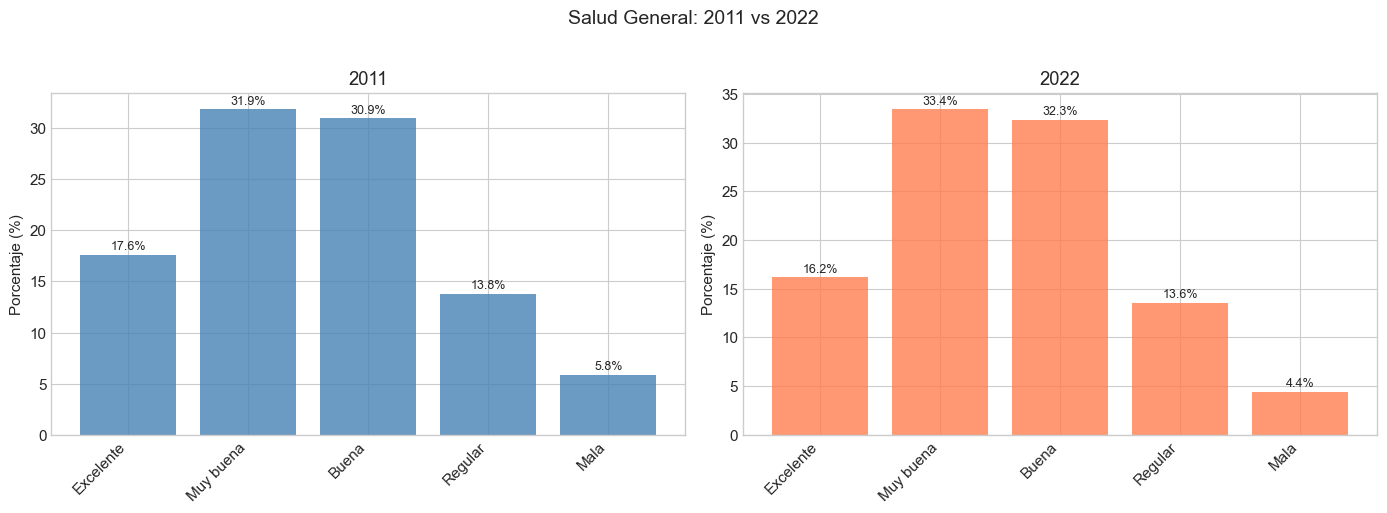

In [10]:
# CELDA 10: Salud General
print('='*60)
print('ANÁLISIS: ESTADO DE SALUD GENERAL')
print('='*60)
print(f'Variable: GENHLTH - {SIGNIFICADOS["GENHLTH"]}')
df_2011_valido = df_2011[df_2011['GENHLTH'].isin([1.0, 2.0, 3.0, 4.0, 5.0])]
df_2022_valido = df_2022[df_2022['GENHLTH'].isin([1.0, 2.0, 3.0, 4.0, 5.0])]
frecuencias(df_2011_valido, 'GENHLTH', ETIQUETAS)
frecuencias(df_2022_valido, 'GENHLTH', ETIQUETAS)
plot_comparacion_barras(df_2011_valido, df_2022_valido, 'GENHLTH', ETIQUETAS, 'Salud General: 2011 vs 2022')

ANÁLISIS: DÍAS DE MALA SALUD MENTAL
Variable: MENTHLTH - Días de mala salud mental (últimos 30 días)

📈 ESTADÍSTICOS: 2011
MENTHLTH     N=156,389  Media=11.01  Mediana=5.00  Std=10.49  Mín=1  Máx=30

📈 ESTADÍSTICOS: 2022
MENTHLTH     N=170,836  Media=11.19  Mediana=7.00  Std=10.17  Mín=1  Máx=30


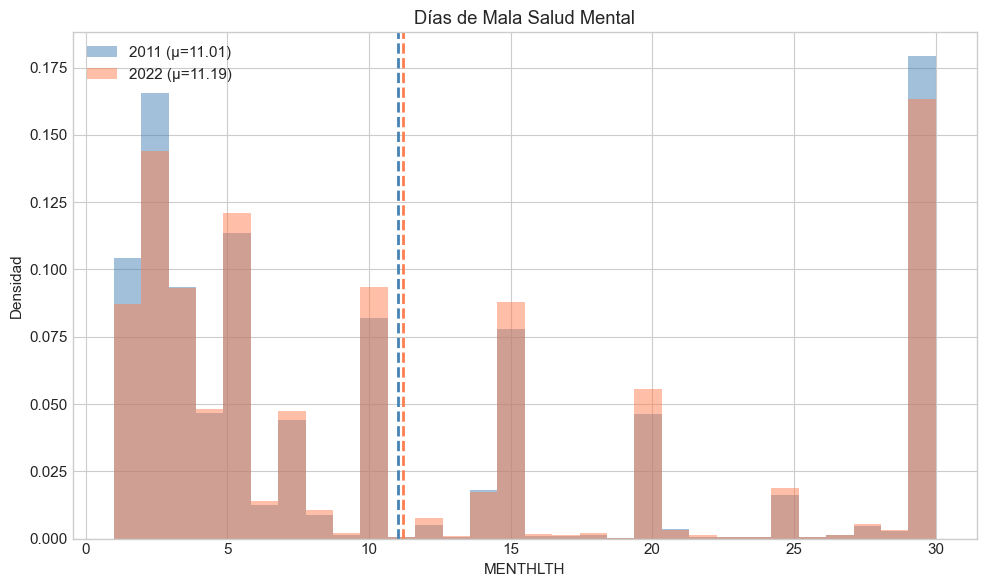

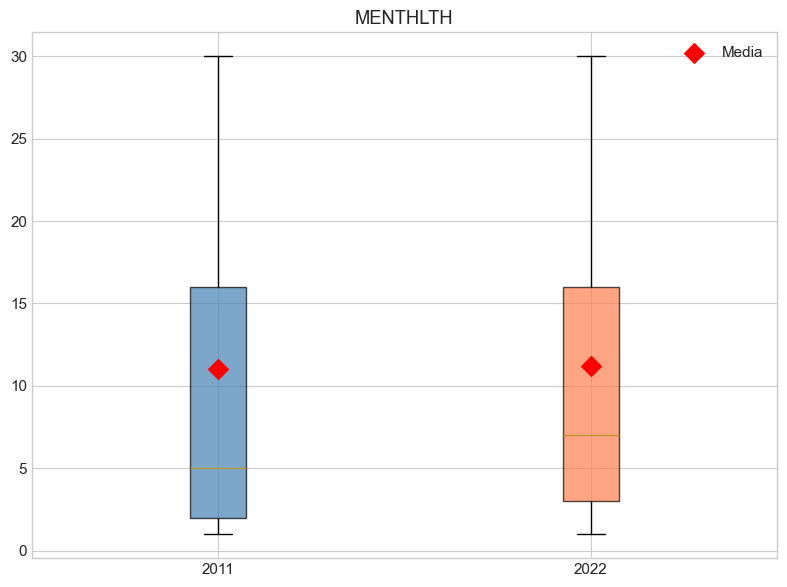

In [11]:
# CELDA 11: Salud Mental
print('='*60)
print('ANÁLISIS: DÍAS DE MALA SALUD MENTAL')
print('='*60)
print(f'Variable: MENTHLTH - {SIGNIFICADOS["MENTHLTH"]}')
estadisticos_numericos(df_2011, ['MENTHLTH'], '2011')
estadisticos_numericos(df_2022, ['MENTHLTH'], '2022')
plot_histogramas(df_2011, df_2022, 'MENTHLTH', 'Días de Mala Salud Mental')
plot_boxplots(df_2011, df_2022, 'MENTHLTH')

### Gráfico 1: Distribución de Densidad (Histogramas)
Esta visualización muestra cómo se distribuyen los días de mala salud mental reportados por los participantes en 2011 (azul) y 2022 (coral).
Hallazgos principales:
La distribución presenta un patrón bimodal muy marcado con dos picos principales:
- Primer pico (0-5 días): Representa personas que experimentan relativamente pocos días de mala salud mental. Este grupo es el más numeroso en ambos años.
- Segundo pico (30 días): Un grupo considerable reporta 30 días completos de mala salud mental, indicando un estado mental persistentemente deteriorado durante todo el mes.

La línea punteada vertical marca aproximadamente los 10-11 días, que corresponde a la media de ambos grupos.

#### Cambios entre 2011 y 2022:
- Se observa un ligero incremento en la densidad alrededor del extremo superior (30 días) en 2022
- La distribución general mantiene una forma similar, pero con pequeños desplazamientos que sugieren un leve empeoramiento

### Gráfico 2: Diagramas de Caja (Box Plots)
Esta gráfica permite comparar las distribuciones de forma más sintética, mostrando la mediana, cuartiles y valores atípicos.
Interpretación de elementos:
- Mediana (línea horizontal dentro de la caja): Aumentó de 5 días (2011) a 7 días (2022), un incremento del 40%
- Media (rombo rojo): Aproximadamente 11 días en ambos años, pero ligeramente superior en 2022
- Caja: Representa el 50% central de los datos (entre el percentil 25 y 75)
- Bigotes: Se extienden hasta los valores extremos, llegando hasta 30 días en ambos casos

Observación crítica: La mediana está muy por debajo de la media, confirmando la distribución asimétrica con una cola larga hacia los valores altos.


ANÁLISIS: DÍAS DE MALA SALUD FÍSICA
Variable: PHYSHLTH - Días de mala salud física (últimos 30 días)

📈 ESTADÍSTICOS: 2011
PHYSHLTH     N=181,337  Media=11.87  Mediana=7.00  Std=11.18  Mín=1  Máx=30

📈 ESTADÍSTICOS: 2022
PHYSHLTH     N=166,386  Media=11.35  Mediana=6.00  Std=10.84  Mín=1  Máx=30


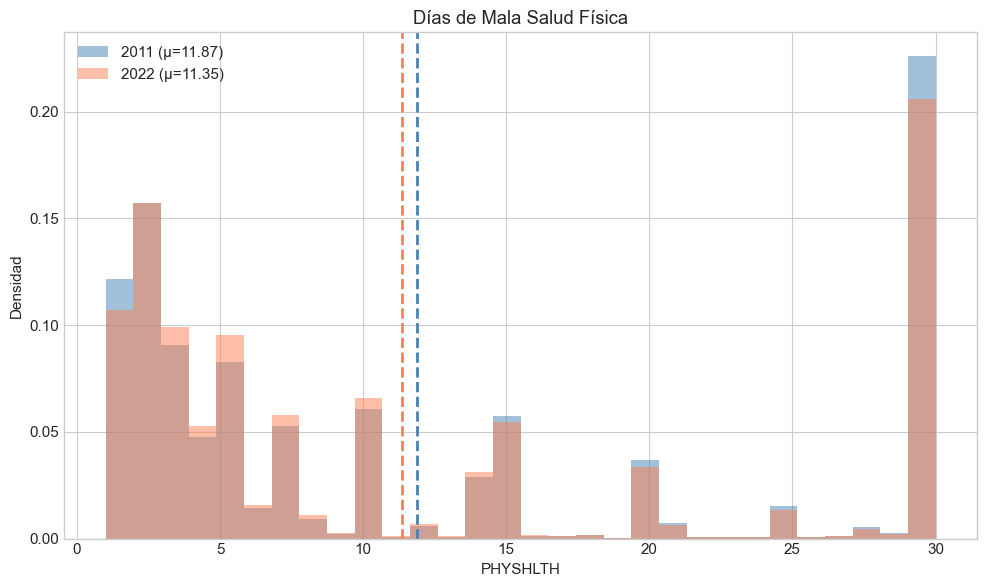

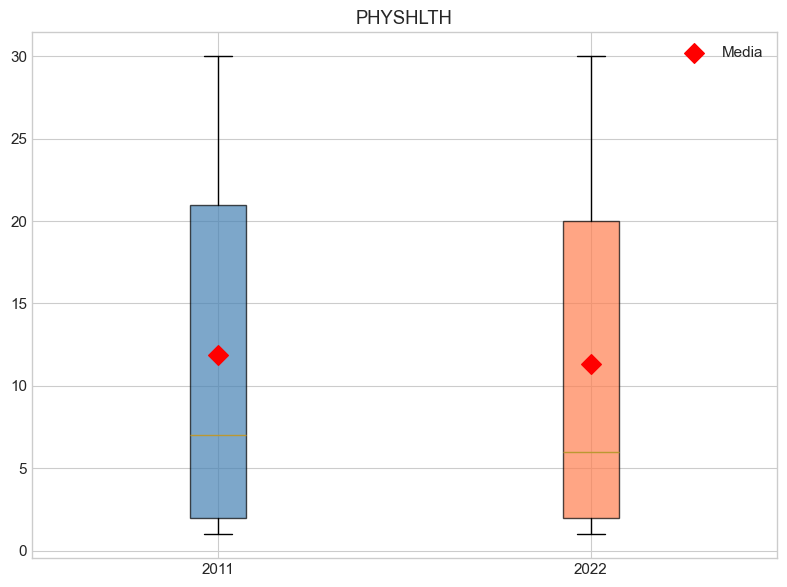

In [12]:
# CELDA 12: Salud Física
print('='*60)
print('ANÁLISIS: DÍAS DE MALA SALUD FÍSICA')
print('='*60)
print(f'Variable: PHYSHLTH - {SIGNIFICADOS["PHYSHLTH"]}')
estadisticos_numericos(df_2011, ['PHYSHLTH'], '2011')
estadisticos_numericos(df_2022, ['PHYSHLTH'], '2022')
plot_histogramas(df_2011, df_2022, 'PHYSHLTH', 'Días de Mala Salud Física')
plot_boxplots(df_2011, df_2022, 'PHYSHLTH')

ANÁLISIS: HORAS DE SUEÑO
Variables: SLEPTIME (2011) / SLEPTIM1 (2022) - Horas de sueño promedio

📈 ESTADÍSTICOS: 2011
SLEPTIME     N=22,403  Media=7.08  Mediana=7.00  Std=1.36  Mín=1  Máx=24

📈 ESTADÍSTICOS: 2022
SLEPTIM1     N=439,679  Media=7.02  Mediana=7.00  Std=1.50  Mín=1  Máx=24


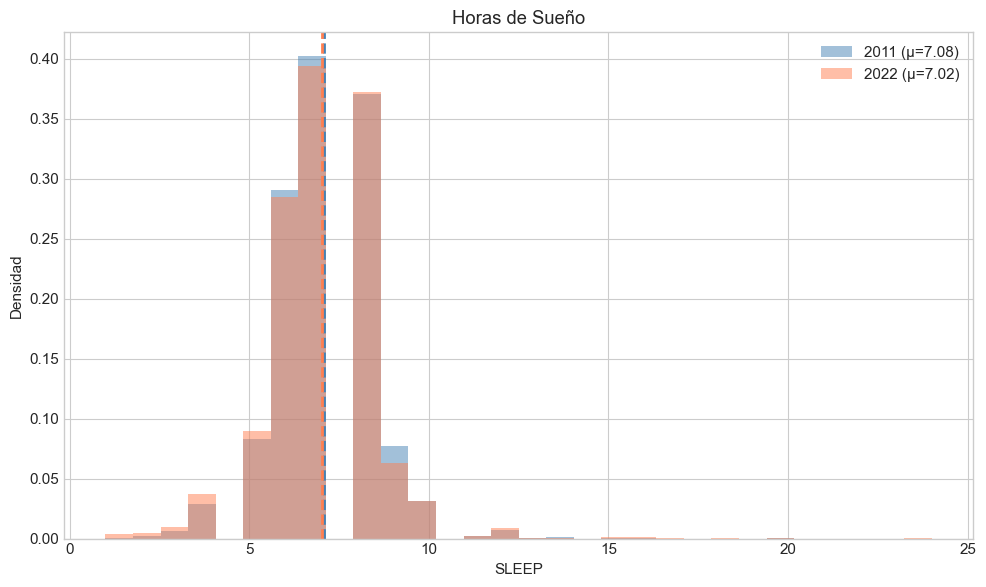

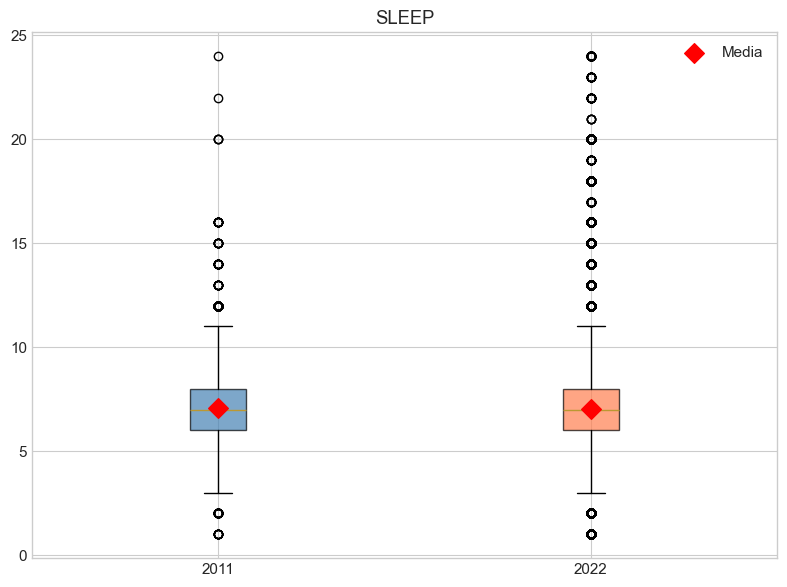

In [13]:
# CELDA 13: Sueño
print('='*60)
print('ANÁLISIS: HORAS DE SUEÑO')
print('='*60)
print(f'Variables: SLEPTIME (2011) / SLEPTIM1 (2022) - {SIGNIFICADOS["SLEPTIME"]}')
estadisticos_numericos(df_2011, ['SLEPTIME'], '2011')
estadisticos_numericos(df_2022, ['SLEPTIM1'], '2022')
df_2011['SLEEP'] = df_2011['SLEPTIME'] if 'SLEPTIME' in df_2011.columns else np.nan
df_2022['SLEEP'] = df_2022['SLEPTIM1'] if 'SLEPTIM1' in df_2022.columns else np.nan
plot_histogramas(df_2011, df_2022, 'SLEEP', 'Horas de Sueño')
plot_boxplots(df_2011, df_2022, 'SLEEP')

#### Cambios entre 2011 y 2022:

- El pico central es más pronunciado en 2022, pero con más "masa" en los extremos
- Se observa un incremento en respuestas de 5 horas o menos en 2022
- Valores atípicos (círculos): Abundantes en ambos extremos, especialmente numerosos en 2022, representando personas que duermen muy poco (1-2 horas) o excesivamente (12-24 horas)

#### Discusión 
Mayor número de outliers en 2022: La cantidad visiblemente mayor de valores atípicos en 2022 podría deberse a:

- Tamaño muestral mucho mayor (N=439,679 vs N=22,403)
- Mayor heterogeneidad real en los patrones de sueño de la población


Aumento en la variabilidad: La desviación estándar aumentó de 1.36 a 1.50 horas, un incremento del 10%, sugiriendo mayor diversidad en los patrones de sueño en 2022.

Estabilidad del centro: A pesar de la mayor dispersión, la tendencia central se mantiene muy estable alrededor de las 7 horas recomendadas.

Considerando los resultados anteriores sobre días de mala salud mental, sería interesante explorar si existe correlación entre la privación de sueño y el deterioro en la salud mental observado en 2022.

ANÁLISIS: TABAQUISMO
Variable: _SMOKER3 - Estado de fumador (calculada)

📌 _SMOKER3 - Registros totales: 503,925
 Código  Frecuencia  Porcentaje          Etiqueta
    1.0       62027       12.31       Fuma diario
    2.0       22724        4.51 Fuma algunos días
    3.0      147864       29.34        Ex-fumador
    4.0      271310       53.84        Nunca fumó

📌 _SMOKER3 - Registros totales: 409,670
 Código  Frecuencia  Porcentaje          Etiqueta
    1.0       36003        8.79       Fuma diario
    2.0       13938        3.40 Fuma algunos días
    3.0      113774       27.77        Ex-fumador
    4.0      245955       60.04        Nunca fumó


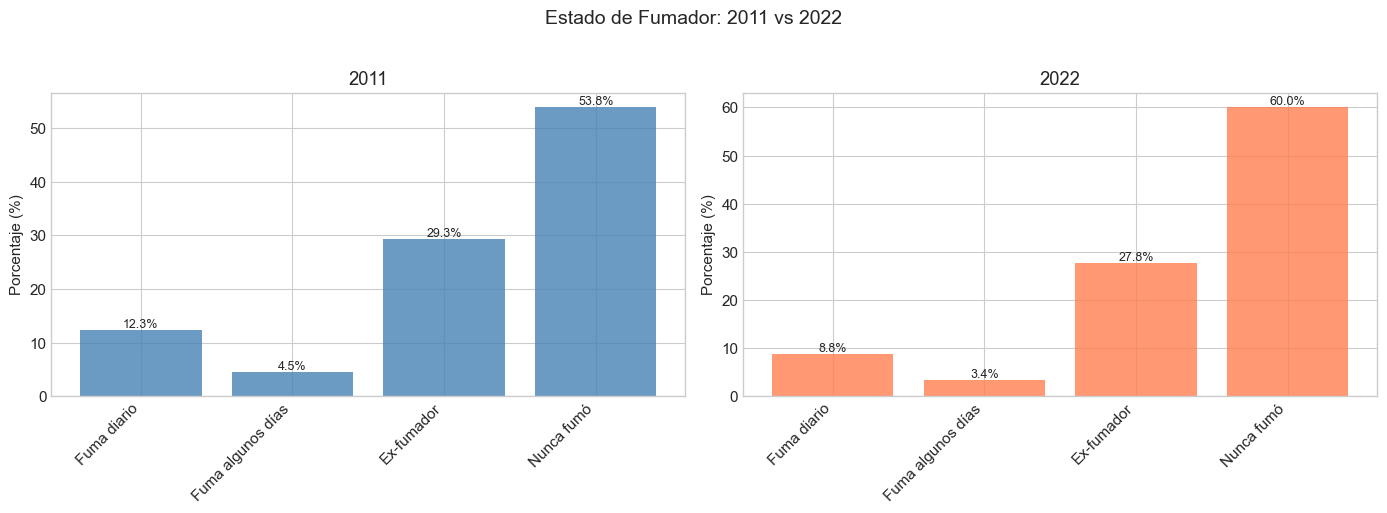

In [14]:
# CELDA 14: Tabaquismo
print('='*60)
print('ANÁLISIS: TABAQUISMO')
print('='*60)
print(f'Variable: _SMOKER3 - {SIGNIFICADOS["_SMOKER3"]}')
df_2011_smoke_valido = df_2011[df_2011['_SMOKER3'].isin([1.0, 2.0, 3.0, 4.0])]
df_2022_smoke_valido = df_2022[df_2022['_SMOKER3'].isin([1.0, 2.0, 3.0, 4.0])]
frecuencias(df_2011_smoke_valido, '_SMOKER3', ETIQUETAS)
frecuencias(df_2022_smoke_valido, '_SMOKER3', ETIQUETAS)
plot_comparacion_barras(df_2011_smoke_valido, df_2022_smoke_valido, '_SMOKER3', ETIQUETAS, 'Estado de Fumador: 2011 vs 2022')

#### Análisis de los Resultados 
- La proporción de fumadores diarios se redujo en 3.5 puntos porcentuales, lo que representa una disminución del 28.5% respecto al nivel de 2011
- Ahora 3 de cada 5 personas nunca han fumado, comparado con aproximadamente 1 de cada 2 en 2011

#### Discusión de Posibilidades 
- Conexión con salud mental: La reducción del tabaquismo podría contribuir a mejor salud mental (o viceversa)
- Conexión con obesidad: Algunos ex-fumadores experimentan aumento de peso al dejar de fumar, esto podría explicar parcialmente el aumento en obesidad observado anteriormente



In [15]:
# CELDA 15: E-cigarrillos (solo 2022)
print('='*60)
print('ANÁLISIS: E-CIGARRILLOS (solo 2022)')
print('='*60)
print(f'Variable: ECIGNOW2 - {SIGNIFICADOS["ECIGNOW2"]}')
df_2022_ecig_valido = df_2022[df_2022['ECIGNOW2'].isin([1.0, 2.0, 3.0, 4.0])]
frecuencias(df_2022_ecig_valido, 'ECIGNOW2', ETIQUETAS)

ANÁLISIS: E-CIGARRILLOS (solo 2022)
Variable: ECIGNOW2 - Uso actual de cigarrillos electrónicos

📌 ECIGNOW2 - Registros totales: 409,472
 Código  Frecuencia  Porcentaje       Etiqueta
    1.0      311988       76.19 Todos los días
    2.0       10382        2.54   Algunos días
    3.0       11734        2.87 No actualmente
    4.0       75368       18.41 Nunca ha usado


,Código,Frecuencia,Porcentaje,Etiqueta
0,1.0,311988,76.19,Todos los días
1,2.0,10382,2.54,Algunos días
2,3.0,11734,2.87,No actualmente
3,4.0,75368,18.41,Nunca ha usado


ANÁLISIS: IMC Y OBESIDAD
Variable: _BMI5CAT - Categoría de Índice de Masa Corporal

📌 _BMI5CAT - Registros totales: 478,839
 Código  Frecuencia  Porcentaje  Etiqueta
    1.0        8289        1.73 Bajo peso
    2.0      163604       34.17    Normal
    3.0      173756       36.29 Sobrepeso
    4.0      133190       27.82     Obeso

📌 _BMI5CAT - Registros totales: 396,326
 Código  Frecuencia  Porcentaje  Etiqueta
    1.0        6778        1.71 Bajo peso
    2.0      116976       29.52    Normal
    3.0      139995       35.32 Sobrepeso
    4.0      132577       33.45     Obeso


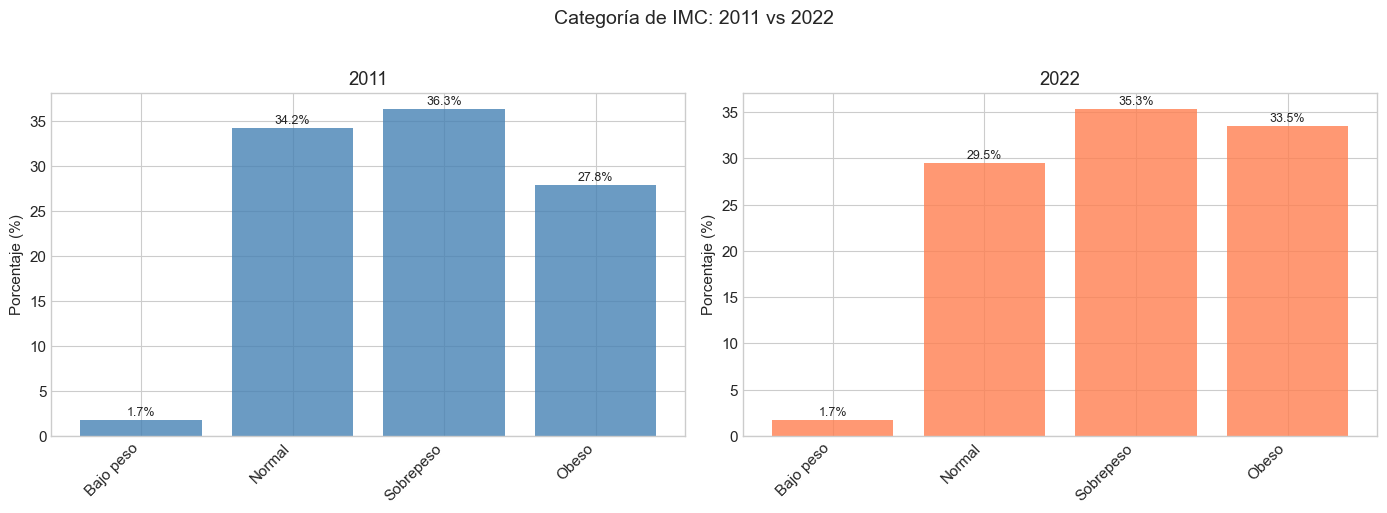

In [19]:
# CELDA 16: IMC
print('='*60)
print('ANÁLISIS: IMC Y OBESIDAD')
print('='*60)
print(f'Variable: _BMI5CAT - {SIGNIFICADOS["_BMI5CAT"]}')
df_2011_bmi_valido = df_2011[df_2011['_BMI5CAT'].isin([1.0, 2.0, 3.0, 4.0])]
df_2022_bmi_valido = df_2022[df_2022['_BMI5CAT'].isin([1.0, 2.0, 3.0, 4.0])]
frecuencias(df_2011_bmi_valido, '_BMI5CAT', ETIQUETAS)
frecuencias(df_2022_bmi_valido, '_BMI5CAT', ETIQUETAS)
plot_comparacion_barras(df_2011_bmi_valido, df_2022_bmi_valido, '_BMI5CAT', ETIQUETAS, 'Categoría de IMC: 2011 vs 2022')

#### Discusión sobre categorías de peso
- La población se está moviendo claramente desde la categoría "Normal" hacia "Obeso"
- El porcentaje combinado de sobrepeso y obesidad aumentó de 64.1% (2011) a 68.8% (2022)
- En 2011, la categoría más prevalente era "Sobrepeso" (36.3%), seguida de "Normal" (34.2%)
- En 2022, "Sobrepeso" (35.3%) y "Obeso" (33.5%) dominan, mientras "Normal" cayó al tercer lugar (29.5%)
- En solo 11 años, la obesidad aumentó casi 6 puntos porcentuales, lo que representa un incremento del 20% en términos relativos
 
Tendencia más preocupante:

Cálculo de las Proporciones

Para 2022:

Categoría "Normal" = 29.5%
29.5% ≈ 30% (redondeando)
30% = 30/100 = 3/10
Por lo tanto: aproximadamente 3 de cada 10 personas

Para 2011:

Categoría "Normal" = 34.2%
34.2% ≈ 34%
34% = 34/100 = 1/3 (porque 33.33% = 1/3)
Por lo tanto: aproximadamente 1 de cada 3 personas

Enfermedes Crónicas: Teniendo en cuenta estos resultados y dado que la obesidad está asociada con múltiples comorbilidades: diabetes tipo 2, enfermedades cardiovasculares, hipertensión, ciertos tipos de cáncer y trastornos musculoesqueléticos, entonces el padecimiento de estas enfermedades pudo aumentar

Salud mental: La obesidad puede estar relacionada con el aumento en días de mala salud mental observado anteriormente, ya que existe una relación bidireccional entre obesidad y depresión/ansiedad

Sueño: La obesidad aumenta el riesgo de apnea del sueño, lo que podría explicar parte de la variabilidad en los patrones de sueño observados

ANÁLISIS: ACTIVIDAD FÍSICA

--- _TOTINDA: Actividad física en últimos 30 días ---

📌 _TOTINDA - Registros totales: 483,473
 Código  Frecuencia  Porcentaje Etiqueta
    1.0      353170       73.05   Activo
    2.0      130303       26.95 Inactivo

📌 _TOTINDA - Registros totales: 444,039
 Código  Frecuencia  Porcentaje Etiqueta
    1.0      337559       76.02   Activo
    2.0      106480       23.98 Inactivo


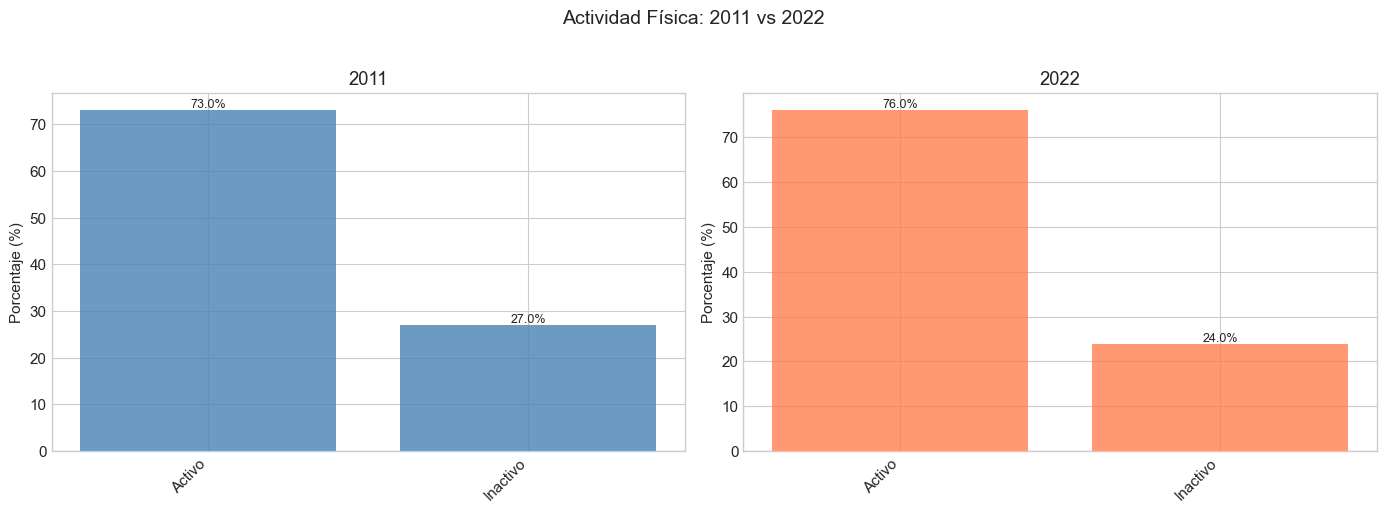


--- _PACAT: Categoría de actividad física ---

📌 _PACAT - Registros totales: 463,111
 Código  Frecuencia  Porcentaje         Etiqueta
    1.0      152907       33.02 Altamente activo
    2.0       86370       18.65           Activo
    3.0       89049       19.23     Insuficiente
    4.0      134785       29.10         Inactivo
⚠️ _PACAT no disponible en 2022


In [16]:
# CELDA 17: Actividad Física
print('='*60)
print('ANÁLISIS: ACTIVIDAD FÍSICA')
print('='*60)

print(f'\n--- _TOTINDA: {SIGNIFICADOS["_TOTINDA"]} ---')
df_2011_act_valido = df_2011[df_2011['_TOTINDA'].isin([1.0, 2.0])]
df_2022_act_valido = df_2022[df_2022['_TOTINDA'].isin([1.0, 2.0])]
frecuencias(df_2011_act_valido, '_TOTINDA', ETIQUETAS)
frecuencias(df_2022_act_valido, '_TOTINDA', ETIQUETAS)
plot_comparacion_barras(df_2011_act_valido, df_2022_act_valido, '_TOTINDA', ETIQUETAS, 'Actividad Física: 2011 vs 2022')

print(f'\n--- _PACAT: {SIGNIFICADOS["_PACAT"]} ---')
if '_PACAT' in df_2011.columns:
    df_2011_pacat_valido = df_2011[df_2011['_PACAT'].isin([1.0, 2.0, 3.0, 4.0])]
    frecuencias(df_2011_pacat_valido, '_PACAT', ETIQUETAS)
else:
    print('⚠️ _PACAT no disponible en 2011')
if '_PACAT' in df_2022.columns:
    df_2022_pacat_valido = df_2022[df_2022['_PACAT'].isin([1.0, 2.0, 3.0, 4.0])]
    frecuencias(df_2022_pacat_valido, '_PACAT', ETIQUETAS)
    if '_PACAT' in df_2011.columns:
        plot_comparacion_barras(df_2011_pacat_valido, df_2022_pacat_valido, '_PACAT', ETIQUETAS, 'Categoría Actividad Física: 2011 vs 2022')
else:
    print('⚠️ _PACAT no disponible en 2022')

ANÁLISIS: DEPRESIÓN
Variable: ADDEPEV2/ADDEPEV3 - Diagnóstico de trastorno depresivo

📌 DEPRESION - Registros totales: 503,020
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       91092       18.11       Sí
    2.0      411928       81.89       No

📌 DEPRESION - Registros totales: 442,320
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       91410       20.67       Sí
    2.0      350910       79.33       No

📈 ESTADÍSTICOS: 2011 - Depresión
MENTHLTH     N=154,767  Media=11.00  Mediana=5.00  Std=10.49  Mín=1  Máx=30

📈 ESTADÍSTICOS: 2022 - Depresión
MENTHLTH     N=169,270  Media=11.16  Mediana=7.00  Std=10.16  Mín=1  Máx=30


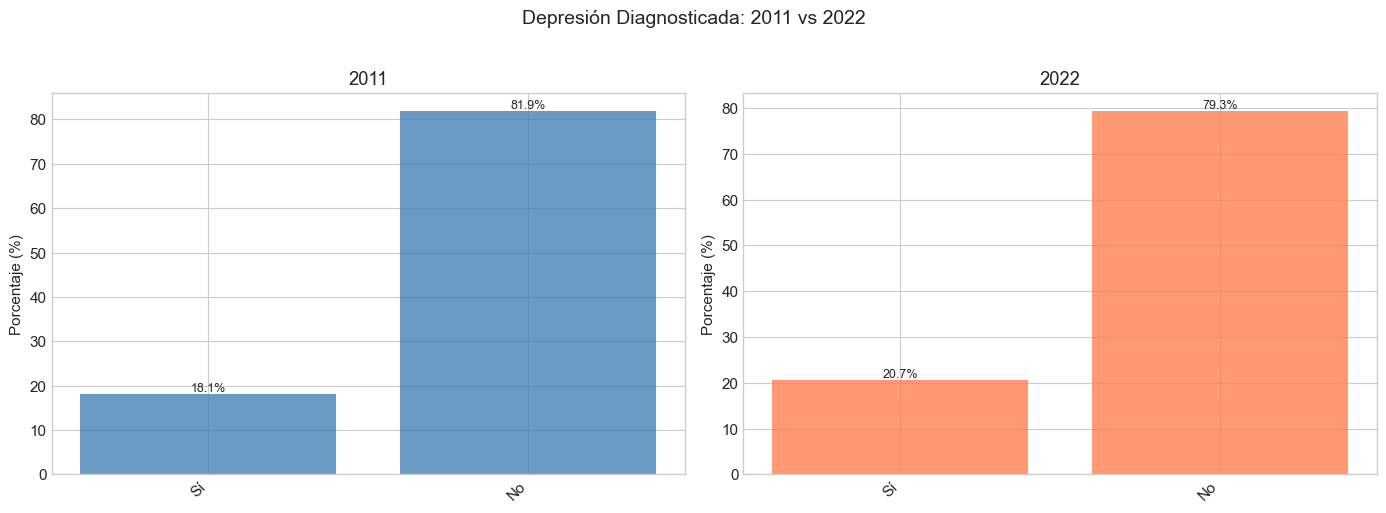

In [17]:
# CELDA 18: Depresión
print('='*60)
print('ANÁLISIS: DEPRESIÓN')
print('='*60)
print(f'Variable: ADDEPEV2/ADDEPEV3 - {SIGNIFICADOS["ADDEPEV2"]}')
df_2011['DEPRESION'] = df_2011['ADDEPEV2']
df_2022['DEPRESION'] = df_2022['ADDEPEV3']
df_2011_dep_valido = df_2011[df_2011['DEPRESION'].isin([1.0, 2.0])]
df_2022_dep_valido = df_2022[df_2022['DEPRESION'].isin([1.0, 2.0])]
frecuencias(df_2011_dep_valido, 'DEPRESION', {'DEPRESION': ETIQUETAS['ADDEPEV2']})
frecuencias(df_2022_dep_valido, 'DEPRESION', {'DEPRESION': ETIQUETAS['ADDEPEV3']})
estadisticos_numericos(df_2011_dep_valido, ['MENTHLTH'], '2011 - Depresión')
estadisticos_numericos(df_2022_dep_valido, ['MENTHLTH'], '2022 - Depresión')
plot_comparacion_barras(df_2011_dep_valido, df_2022_dep_valido, 'DEPRESION', {'DEPRESION': ETIQUETAS['ADDEPEV2']}, 'Depresión Diagnosticada: 2011 vs 2022')

ANÁLISIS: ENFERMEDAD CORONARIA

--- CVDCRHD4: Diagnóstico de enfermedad coronaria ---

📌 CVDCRHD4 - Registros totales: 501,841
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       30235        6.02       Sí
    2.0      471606       93.98       No

📌 CVDCRHD4 - Registros totales: 440,727
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       26551        6.02       Sí
    2.0      414176       93.98       No


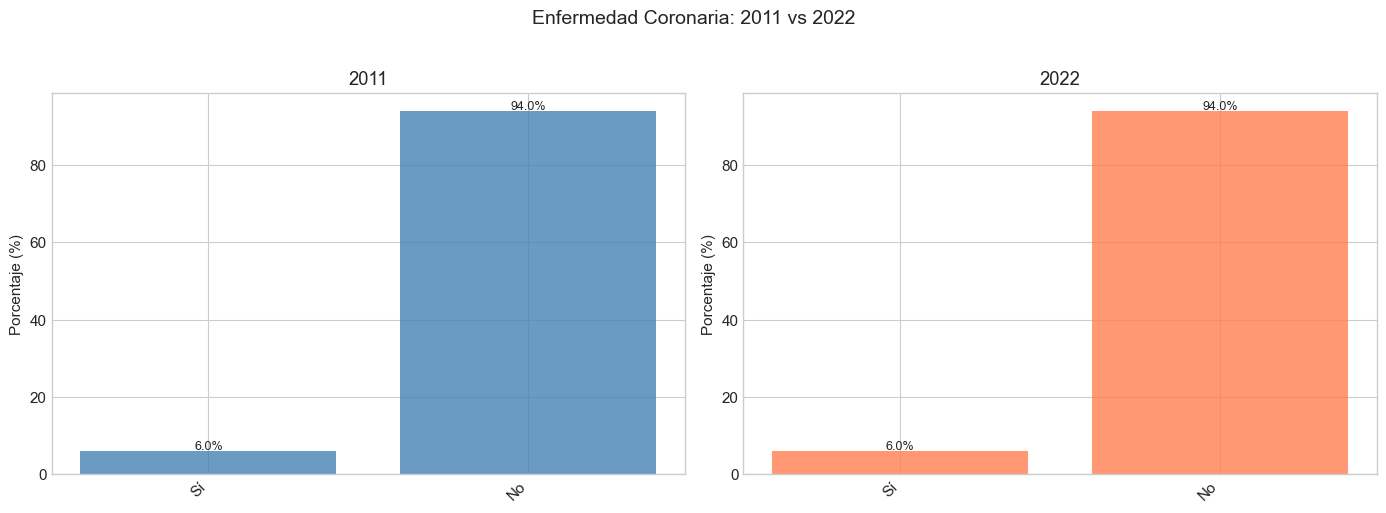

In [22]:
# CELDA 19a: Enfermedad Coronaria
print('='*60)
print('ANÁLISIS: ENFERMEDAD CORONARIA')
print('='*60)

print(f'\n--- CVDCRHD4: {SIGNIFICADOS["CVDCRHD4"]} ---')
df_2011_cor_valido = df_2011[df_2011['CVDCRHD4'].isin([1.0, 2.0])]
df_2022_cor_valido = df_2022[df_2022['CVDCRHD4'].isin([1.0, 2.0])]
frecuencias(df_2011_cor_valido, 'CVDCRHD4', ETIQUETAS)
frecuencias(df_2022_cor_valido, 'CVDCRHD4', ETIQUETAS)
plot_comparacion_barras(df_2011_cor_valido, df_2022_cor_valido, 'CVDCRHD4', ETIQUETAS, 'Enfermedad Coronaria: 2011 vs 2022')

ANÁLISIS: INFARTO DE MIOCARDIO

--- CVDINFR4: Diagnóstico de infarto de miocardio ---

📌 CVDINFR4 - Registros totales: 504,002
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       30052        5.96       Sí
    2.0      473950       94.04       No

📌 CVDINFR4 - Registros totales: 442,067
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       25108        5.68       Sí
    2.0      416959       94.32       No


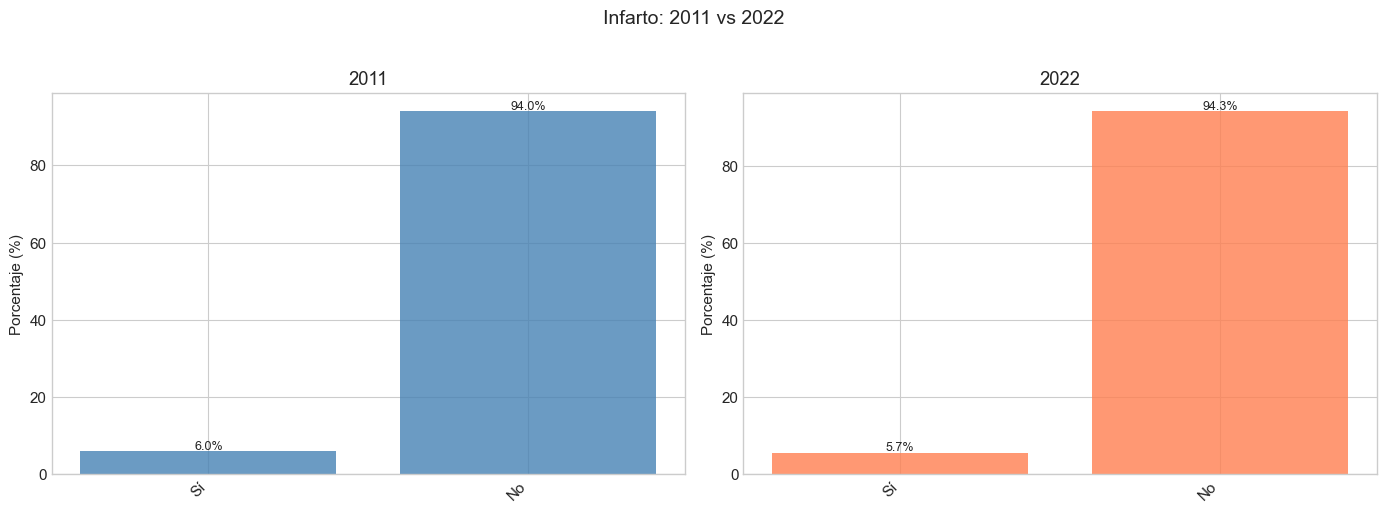

In [18]:
# CELDA 19b: Infarto de Miocardio
print('='*60)
print('ANÁLISIS: INFARTO DE MIOCARDIO')
print('='*60)

print(f'\n--- CVDINFR4: {SIGNIFICADOS["CVDINFR4"]} ---')
df_2011_inf_valido = df_2011[df_2011['CVDINFR4'].isin([1.0, 2.0])]
df_2022_inf_valido = df_2022[df_2022['CVDINFR4'].isin([1.0, 2.0])]
frecuencias(df_2011_inf_valido, 'CVDINFR4', ETIQUETAS)
frecuencias(df_2022_inf_valido, 'CVDINFR4', ETIQUETAS)
plot_comparacion_barras(df_2011_inf_valido, df_2022_inf_valido, 'CVDINFR4', ETIQUETAS, 'Infarto: 2011 vs 2022')

In [19]:
# CELDA 19c: Colesterol
print('='*60)
print('ANÁLISIS: COLESTEROL')
print('='*60)

print(f'\n--- TOLDHI2: {SIGNIFICADOS["TOLDHI2"]} ---')
if 'TOLDHI2' in df_2011.columns:
    df_2011_col_valido = df_2011[df_2011['TOLDHI2'].isin([1.0, 2.0])]
    frecuencias(df_2011_col_valido, 'TOLDHI2', ETIQUETAS)
if 'TOLDHI2' in df_2022.columns:
    df_2022_col_valido = df_2022[df_2022['TOLDHI2'].isin([1.0, 2.0])]
    frecuencias(df_2022_col_valido, 'TOLDHI2', ETIQUETAS)
if 'TOLDHI2' in df_2011.columns and 'TOLDHI2' in df_2022.columns:
    plot_comparacion_barras(df_2011_col_valido, df_2022_col_valido, 'TOLDHI2', ETIQUETAS, 'Colesterol Alto: 2011 vs 2022')

ANÁLISIS: COLESTEROL

--- TOLDHI2: Diagnóstico de colesterol alto ---

📌 TOLDHI2 - Registros totales: 431,865
 Código  Frecuencia  Porcentaje Etiqueta
    1.0      187934       43.52       Sí
    2.0      243931       56.48       No


In [20]:
# CELDA 19d: Presión Arterial y Medicamentos
print('='*60)
print('ANÁLISIS: PRESIÓN ARTERIAL')
print('='*60)

print(f'\n--- BPHIGH4: {SIGNIFICADOS["BPHIGH4"]} ---')
if 'BPHIGH4' in df_2011.columns:
    df_2011_bp_valido = df_2011[df_2011['BPHIGH4'].isin([1.0, 2.0, 3.0, 4.0])]
    frecuencias(df_2011_bp_valido, 'BPHIGH4', ETIQUETAS)
if 'BPHIGH4' in df_2022.columns:
    df_2022_bp_valido = df_2022[df_2022['BPHIGH4'].isin([1.0, 2.0, 3.0, 4.0])]
    frecuencias(df_2022_bp_valido, 'BPHIGH4', ETIQUETAS)

print(f'\n--- BPMEDS: {SIGNIFICADOS["BPMEDS"]} ---')
if 'BPMEDS' in df_2011.columns:
    df_2011_bpmed_valido = df_2011[df_2011['BPMEDS'].isin([1.0, 2.0])]
    frecuencias(df_2011_bpmed_valido, 'BPMEDS', ETIQUETAS)
if 'BPMEDS' in df_2022.columns:
    df_2022_bpmed_valido = df_2022[df_2022['BPMEDS'].isin([1.0, 2.0])]
    frecuencias(df_2022_bpmed_valido, 'BPMEDS', ETIQUETAS)

estadisticos_numericos(df_2011, ['BPHIGH4', 'BPMEDS'], '2011 - Presión Arterial')

# Gráficos comparativos de presión arterial
if 'BPHIGH4' in df_2011.columns and 'BPHIGH4' in df_2022.columns:
    plot_comparacion_barras(df_2011_bp_valido, df_2022_bp_valido, 'BPHIGH4', ETIQUETAS, 'Presión Arterial Alta: 2011 vs 2022')
if 'BPMEDS' in df_2011.columns and 'BPMEDS' in df_2022.columns:
    plot_comparacion_barras(df_2011_bpmed_valido, df_2022_bpmed_valido, 'BPMEDS', ETIQUETAS, 'Medicamentos Presión: 2011 vs 2022')

ANÁLISIS: PRESIÓN ARTERIAL

--- BPHIGH4: Diagnóstico de presión arterial alta ---

📌 BPHIGH4 - Registros totales: 505,097
 Código  Frecuencia  Porcentaje         Etiqueta
    1.0      201409       39.88               Sí
    2.0        3719        0.74    Sí (embarazo)
    3.0      293859       58.18               No
    4.0        6110        1.21 Pre-hipertensión

--- BPMEDS: Toma medicamentos para la presión ---

📌 BPMEDS - Registros totales: 201,087
 Código  Frecuencia  Porcentaje Etiqueta
    1.0      169937       84.51       Sí
    2.0       31150       15.49       No

📈 ESTADÍSTICOS: 2011 - Presión Arterial
BPHIGH4      N=506,462  Media=2.22  Mediana=3.00  Std=1.03  Mín=1  Máx=9
BPMEDS       N=201,409  Media=1.16  Mediana=1.00  Std=0.44  Mín=1  Máx=9


#### Prevalencia de Presión Arterial Alta
- Aproximadamente 2 de cada 5 adultos tienen diagnóstico de presión arterial alta
- Buena adherencia al tratamiento farmacológico, aproximadamente 5 de cada 6 personas con hipertensión siguen tratamiento farmacológico

Relación dosis-respuesta: a mayor IMC, mayor riesgo de hipertensión

El tabaquismo aumenta agudamente la presión arterial y contribuye al daño vascular

Los fumadores con hipertensión tienen riesgo cardiovascular significativamente aumentado

ANÁLISIS: ASMA

--- ASTHMA3: Diagnóstico de asma ---

📌 ASTHMA3 - Registros totales: 504,880
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       65097       12.89       Sí
    2.0      439783       87.11       No

📌 ASTHMA3 - Registros totales: 443,359
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       66694       15.04       Sí
    2.0      376665       84.96       No


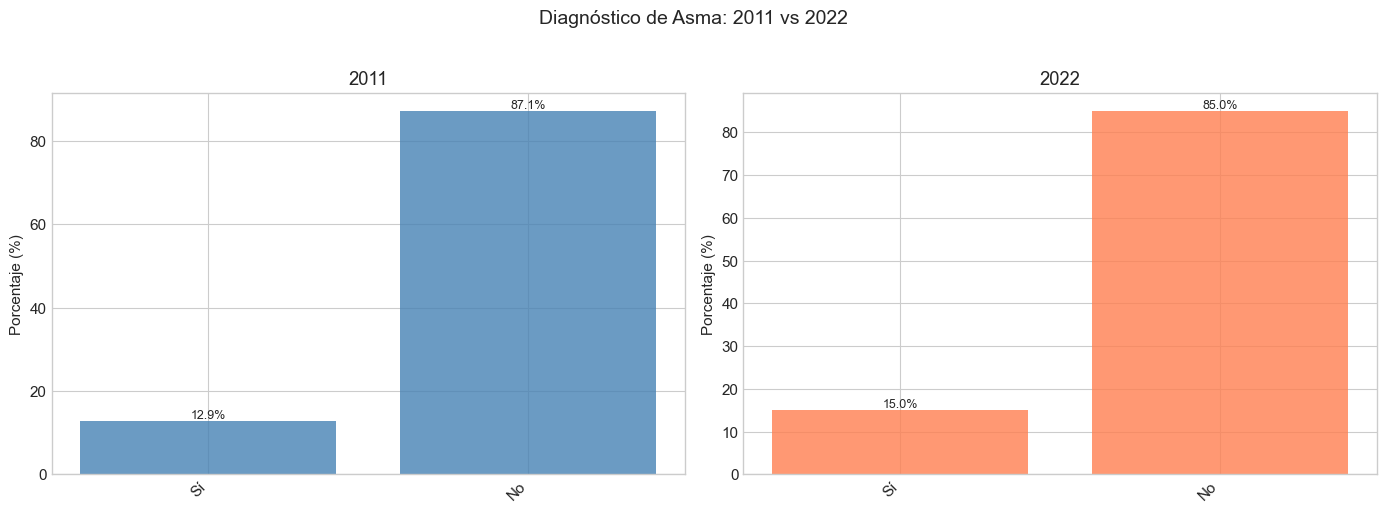


--- ASTHNOW: Asma actual ---

📌 ASTHNOW - Registros totales: 63,384
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       45203       71.32       Sí
    2.0       18181       28.68       No

📌 ASTHNOW - Registros totales: 64,607
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       45659       70.67       Sí
    2.0       18948       29.33       No


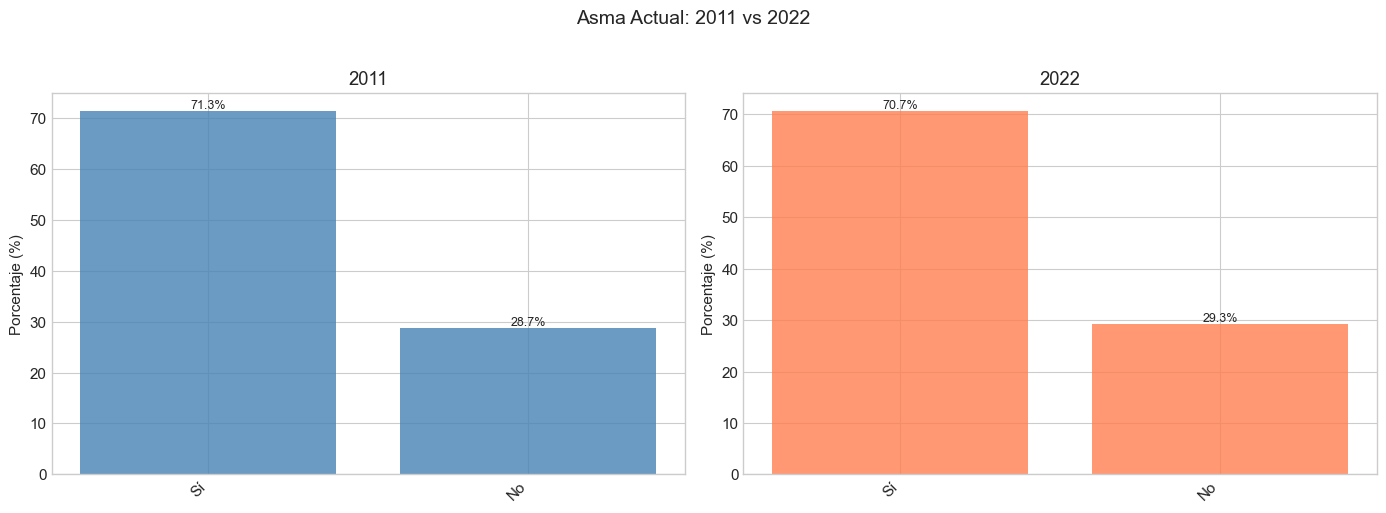

In [21]:
# CELDA 20a: Asma
print('='*60)
print('ANÁLISIS: ASMA')
print('='*60)

print(f'\n--- ASTHMA3: {SIGNIFICADOS["ASTHMA3"]} ---')
df_2011_asma_valido = df_2011[df_2011['ASTHMA3'].isin([1.0, 2.0])]
df_2022_asma_valido = df_2022[df_2022['ASTHMA3'].isin([1.0, 2.0])]
frecuencias(df_2011_asma_valido, 'ASTHMA3', ETIQUETAS)
frecuencias(df_2022_asma_valido, 'ASTHMA3', ETIQUETAS)
plot_comparacion_barras(df_2011_asma_valido, df_2022_asma_valido, 'ASTHMA3', ETIQUETAS, 'Diagnóstico de Asma: 2011 vs 2022')

print(f'\n--- ASTHNOW: {SIGNIFICADOS["ASTHNOW"]} ---')
df_2011_asthnow_valido = df_2011[df_2011['ASTHNOW'].isin([1.0, 2.0])]
df_2022_asthnow_valido = df_2022[df_2022['ASTHNOW'].isin([1.0, 2.0])]
frecuencias(df_2011_asthnow_valido, 'ASTHNOW', ETIQUETAS)
frecuencias(df_2022_asthnow_valido, 'ASTHNOW', ETIQUETAS)
plot_comparacion_barras(df_2011_asthnow_valido, df_2022_asthnow_valido, 'ASTHNOW', ETIQUETAS, 'Asma Actual: 2011 vs 2022')

ANÁLISIS: DIABETES

--- DIABETE3/DIABETE4: Diagnóstico de diabetes ---

📌 DIABETES - Registros totales: 504,530
 Código  Frecuencia  Porcentaje      Etiqueta
    1.0       62461       12.38            Sí
    2.0        4828        0.96 Sí (embarazo)
    3.0      429062       85.04            No
    4.0        8179        1.62  Pre-diabetes

📌 DIABETES - Registros totales: 444,045
 Código  Frecuencia  Porcentaje      Etiqueta
    1.0       61158       13.77            Sí
    2.0        3836        0.86 Sí (embarazo)
    3.0      368722       83.04            No
    4.0       10329        2.33  Pre-diabetes


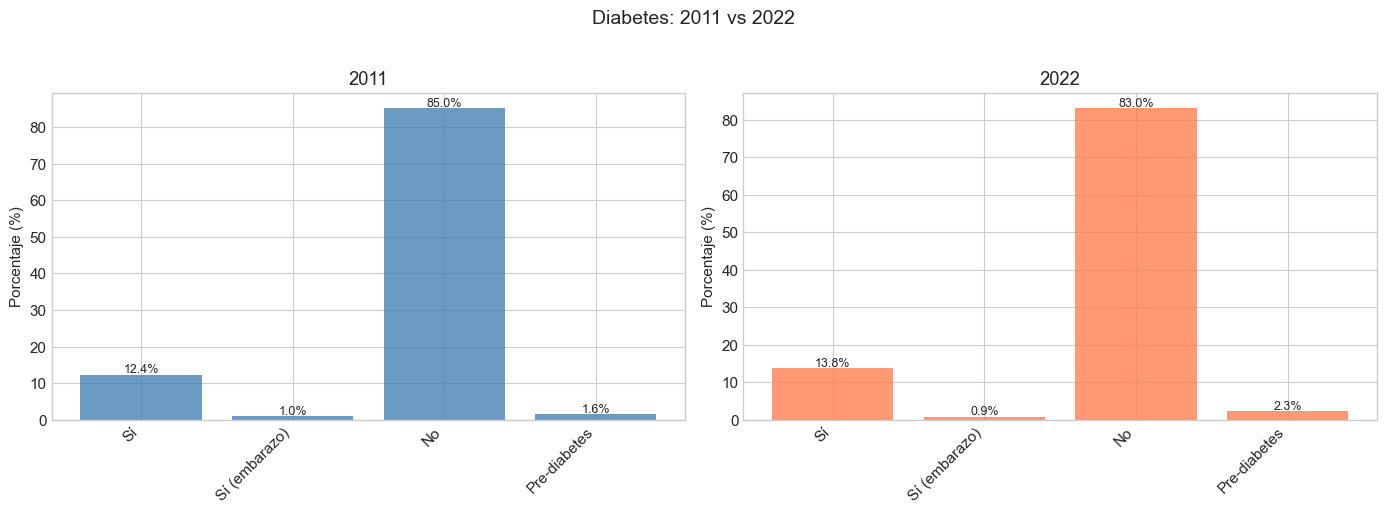

In [22]:
# CELDA 20b: Diabetes
print('='*60)
print('ANÁLISIS: DIABETES')
print('='*60)

print(f'\n--- DIABETE3/DIABETE4: {SIGNIFICADOS["DIABETE3"]} ---')
df_2011['DIABETES'] = df_2011['DIABETE3']
df_2022['DIABETES'] = df_2022['DIABETE4']
df_2011_diab_valido = df_2011[df_2011['DIABETES'].isin([1.0, 2.0, 3.0, 4.0])]
df_2022_diab_valido = df_2022[df_2022['DIABETES'].isin([1.0, 2.0, 3.0, 4.0])]
frecuencias(df_2011_diab_valido, 'DIABETES', {'DIABETES': ETIQUETAS['DIABETE3']})
frecuencias(df_2022_diab_valido, 'DIABETES', {'DIABETES': ETIQUETAS['DIABETE4']})
plot_comparacion_barras(df_2011_diab_valido, df_2022_diab_valido, 'DIABETES', {'DIABETES': ETIQUETAS['DIABETE3']}, 'Diabetes: 2011 vs 2022')

#### Aumento alarmante en pre-diabetes (+43.8%):
- El aumento de 1.6% a 2.3% en pre-diabetes es el cambio relativo más dramático observado
- Estado de alto riesgo: Sin intervención, un gran porcentaje progresará a diabetes tipo 2 en 10 años


In [23]:
# Celda 21: Consumo de Alcohol
print('='*60)
print('ANÁLISIS: CONSUMO DE ALCOHOL')
print('='*60)

# Variables de alcohol (diferentes entre años)
vars_alcohol_2011 = ['ALCDAY5', 'AVEDRNK2', 'DRNKANY5', '_RFBING5', '_DRNKMO4', '_RFDRHV4']
vars_alcohol_2022 = ['ALCDAY4', 'AVEDRNK3', 'DRNKANY6', '_RFBING6', '_DRNKWK2', '_RFDRHV8']

# Verificar disponibilidad

disp_2011 = [v for v in vars_alcohol_2011 if v in df_2011.columns]
disp_2022 = [v for v in vars_alcohol_2022 if v in df_2022.columns]


# 1. Bebió alcohol en los últimos 30 días (DRNKANY)
print('\n' + '='*60)
print('¿BEBIÓ ALCOHOL EN LOS ÚLTIMOS 30 DÍAS?')
print('='*60)
etiq_drnk = {1: 'Sí', 2: 'No'}
if 'DRNKANY5' in df_2011.columns:
    df_2011_alc = df_2011[df_2011['DRNKANY5'].isin([1, 2])]
    frecuencias(df_2011_alc, 'DRNKANY5', {'DRNKANY5': etiq_drnk}, '2011: ¿Bebió alcohol?')
if 'DRNKANY6' in df_2022.columns:
    df_2022_alc = df_2022[df_2022['DRNKANY6'].isin([1, 2])]
    frecuencias(df_2022_alc, 'DRNKANY6', {'DRNKANY6': etiq_drnk}, '2022: ¿Bebió alcohol?')

ANÁLISIS: CONSUMO DE ALCOHOL

¿BEBIÓ ALCOHOL EN LOS ÚLTIMOS 30 DÍAS?

📌 2011: ¿Bebió alcohol? - Registros totales: 472,769
 Código  Frecuencia  Porcentaje Etiqueta
    1.0      242555       51.31       Sí
    2.0      230214       48.69       No

📌 2022: ¿Bebió alcohol? - Registros totales: 398,558
 Código  Frecuencia  Porcentaje Etiqueta
    1.0      210891       52.91       Sí
    2.0      187667       47.09       No


INDICADORES DE RIESGO POR ALCOHOL
2011 - Binge Drinking: 12.9% con riesgo
2022 - Binge Drinking: 14.4% con riesgo

2011 - Consumo Excesivo: 5.7% con riesgo
2022 - Consumo Excesivo: 6.7% con riesgo


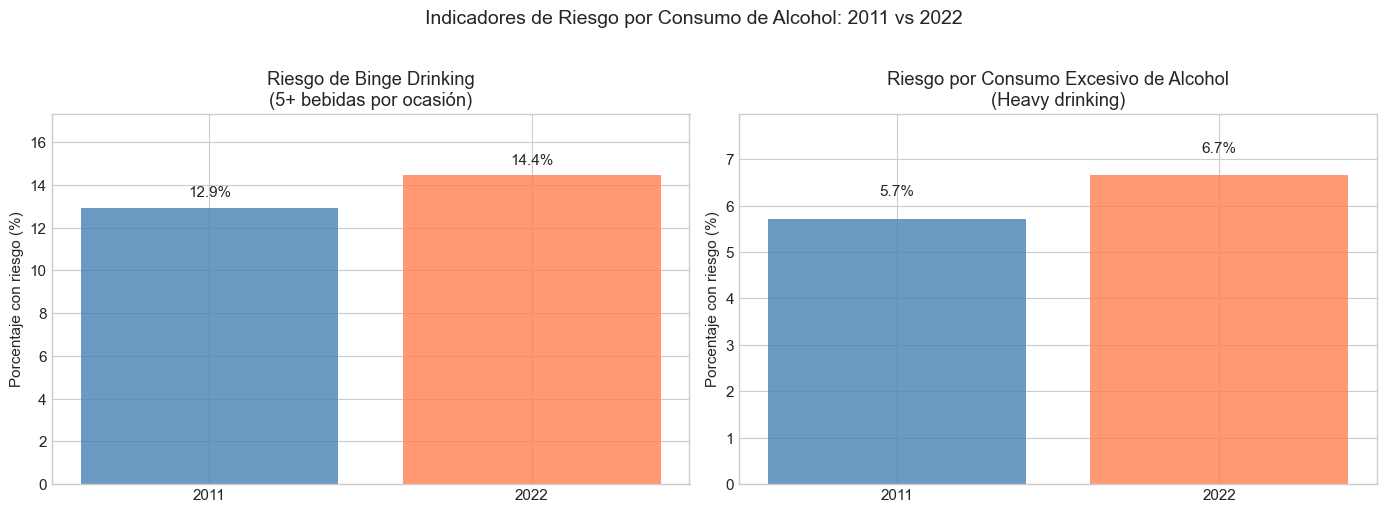

In [29]:
# VISUALIZACIÓN: Riesgo de Binge Drinking y Consumo Excesivo
print('='*60)
print('INDICADORES DE RIESGO POR ALCOHOL')
print('='*60)

# Etiquetas para variables de riesgo (1=No riesgo, 2=Riesgo)
etiq_riesgo = {1: 'Sin riesgo', 2: 'Con riesgo'}

# Binge drinking (consumo de 5+ bebidas en una ocasión)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Binge Drinking
datos_binge = []
for i, (df, year, var, color) in enumerate([
    (df_2011, '2011', '_RFBING5', 'steelblue'),
    (df_2022, '2022', '_RFBING6', 'coral')
]):
    if var in df.columns:
        validos = df[df[var].isin([1, 2])]
        riesgo_pct = (validos[var] == 2).sum() / len(validos) * 100
        datos_binge.append({'Año': year, 'Riesgo': riesgo_pct})
        print(f'{year} - Binge Drinking: {riesgo_pct:.1f}% con riesgo')

if datos_binge:
    bars = axes[0].bar([d['Año'] for d in datos_binge], [d['Riesgo'] for d in datos_binge], 
                       color=['steelblue', 'coral'], alpha=0.8)
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    f'{bar.get_height():.1f}%', ha='center', fontsize=11)
    axes[0].set_ylabel('Porcentaje con riesgo (%)')
    axes[0].set_title('Riesgo de Binge Drinking\n(5+ bebidas por ocasión)')
    axes[0].set_ylim(0, max([d['Riesgo'] for d in datos_binge]) * 1.2)

# Panel 2: Consumo Excesivo General
print('')
datos_exceso = []
for i, (df, year, var, color) in enumerate([
    (df_2011, '2011', '_RFDRHV4', 'steelblue'),
    (df_2022, '2022', '_RFDRHV8', 'coral')
]):
    if var in df.columns:
        validos = df[df[var].isin([1, 2])]
        riesgo_pct = (validos[var] == 2).sum() / len(validos) * 100
        datos_exceso.append({'Año': year, 'Riesgo': riesgo_pct})
        print(f'{year} - Consumo Excesivo: {riesgo_pct:.1f}% con riesgo')

if datos_exceso:
    bars = axes[1].bar([d['Año'] for d in datos_exceso], [d['Riesgo'] for d in datos_exceso], 
                       color=['steelblue', 'coral'], alpha=0.8)
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    f'{bar.get_height():.1f}%', ha='center', fontsize=11)
    axes[1].set_ylabel('Porcentaje con riesgo (%)')
    axes[1].set_title('Riesgo por Consumo Excesivo de Alcohol\n(Heavy drinking)')
    axes[1].set_ylim(0, max([d['Riesgo'] for d in datos_exceso]) * 1.2)

plt.suptitle('Indicadores de Riesgo por Consumo de Alcohol: 2011 vs 2022', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('riesgo_alcohol.png', dpi=150, bbox_inches='tight')
plt.show()

PROMEDIO DE BEBIDAS POR OCASIÓN


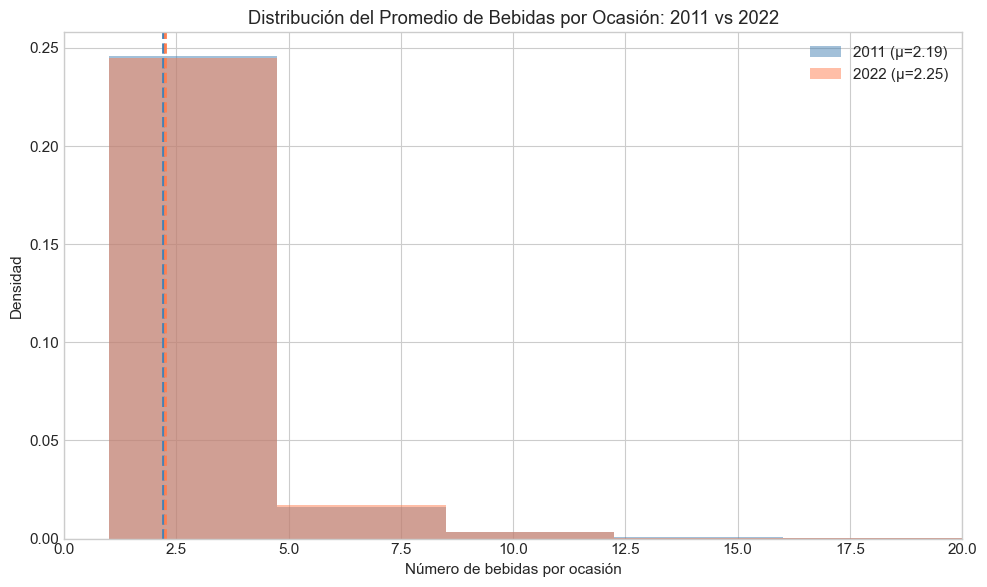


📊 ESTADÍSTICOS:
2011: N=239,213 | Media=2.19 | Mediana=2.0 | Std=2.33
2022: N=206,595 | Media=2.25 | Mediana=2.0 | Std=2.34


In [24]:
# ANÁLISIS: Promedio de bebidas por ocasión
print('='*60)
print('PROMEDIO DE BEBIDAS POR OCASIÓN')
print('='*60)

# AVEDRNK2 (2011) y AVEDRNK3 (2022): Número promedio de bebidas
# Valores válidos: 1-76 (número de bebidas)
fig, ax = plt.subplots(figsize=(10, 6))

stats_bebidas = []
for df, year, var, color in [(df_2011, '2011', 'AVEDRNK2', 'steelblue'), 
                              (df_2022, '2022', 'AVEDRNK3', 'coral')]:
    if var in df.columns:
        # Filtrar valores válidos (1-76)
        datos = df[var][(df[var] >= 1) & (df[var] <= 76)]
        if len(datos) > 0:
            stats_bebidas.append({
                'Año': year,
                'N': len(datos),
                'Media': datos.mean(),
                'Mediana': datos.median(),
                'Std': datos.std()
            })
            ax.hist(datos, bins=20, alpha=0.5, label=f'{year} (μ={datos.mean():.2f})', color=color, density=True)
            ax.axvline(datos.mean(), color=color, linestyle='--', linewidth=2)

ax.set_xlabel('Número de bebidas por ocasión')
ax.set_ylabel('Densidad')
ax.set_title('Distribución del Promedio de Bebidas por Ocasión: 2011 vs 2022')
ax.legend()
ax.set_xlim(0, 20)  # Limitar para mejor visualización
plt.tight_layout()
plt.savefig('bebidas_por_ocasion.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar estadísticos
print('\n📊 ESTADÍSTICOS:')
for s in stats_bebidas:
    print(f"{s['Año']}: N={s['N']:,} | Media={s['Media']:.2f} | Mediana={s['Mediana']:.1f} | Std={s['Std']:.2f}")

In [25]:
# PREPARACIÓN: Experiencias Adversas en la Infancia (ACEs)
print('='*60)
print('PREPARACIÓN: EXPERIENCIAS ADVERSAS EN LA INFANCIA (ACEs)')
print('='*60)

# Variables ACE y etiquetas descriptivas
aces_vars = ['ACEDEPRS', 'ACEDRINK', 'ACEDRUGS', 'ACEPRISN', 'ACEDIVRC',
             'ACEPUNCH', 'ACESWEAR', 'ACETOUCH', 'ACETTHEM', 'ACEHVSEX']

etiquetas_aces = {
    'ACEDEPRS': 'Depresión parental', 'ACEDRINK': 'Alcoholismo parental',
    'ACEDRUGS': 'Drogas parental', 'ACEPRISN': 'Prisión parental',
    'ACEDIVRC': 'Divorcio', 'ACEPUNCH': 'Violencia física',
    'ACESWEAR': 'Abuso verbal', 'ACETOUCH': 'Abuso sexual (tocado)',
    'ACETTHEM': 'Abuso sexual (obligado)', 'ACEHVSEX': 'Abuso sexual (forzado)'
}

# Verificación de disponibilidad
print(f'\n📋 Variables en 2011: {sum(1 for v in aces_vars if v in df_2011.columns)}/{len(aces_vars)}')
print(f'📋 Variables en 2022: {sum(1 for v in aces_vars if v in df_2022.columns)}/{len(aces_vars)}')

# Detección automática de variables con codificación invertida
# En BRFSS: si código 1 > 50%, la variable usa 1=No (invertida)
print('\n📊 VERIFICACIÓN DE CODIFICACIÓN:')
aces_invertidas = []
for ace in aces_vars:
    if ace in df_2011.columns:
        val_1, val_2 = (df_2011[ace] == 1).sum(), (df_2011[ace] == 2).sum()
        if val_1 + val_2 > 0:
            pct_1 = val_1/(val_1+val_2)*100
            if pct_1 > 50:
                aces_invertidas.append(ace)
                print(f'{ace}: Cód 1={pct_1:.1f}% → ⚠️ INVERTIDA')
            else:
                print(f'{ace}: Cód 1={pct_1:.1f}% → ✓ Normal')

print(f'\n🔄 Variables invertidas detectadas: {aces_invertidas}')

PREPARACIÓN: EXPERIENCIAS ADVERSAS EN LA INFANCIA (ACEs)

📋 Variables en 2011: 10/10
📋 Variables en 2022: 10/10

📊 VERIFICACIÓN DE CODIFICACIÓN:
ACEDEPRS: Cód 1=16.5% → ✓ Normal
ACEDRINK: Cód 1=24.9% → ✓ Normal
ACEDRUGS: Cód 1=7.8% → ✓ Normal
ACEPRISN: Cód 1=4.6% → ✓ Normal
ACEDIVRC: Cód 1=20.4% → ✓ Normal
ACEPUNCH: Cód 1=95.5% → ⚠️ INVERTIDA
ACESWEAR: Cód 1=91.0% → ⚠️ INVERTIDA
ACETOUCH: Cód 1=95.7% → ⚠️ INVERTIDA
ACETTHEM: Cód 1=97.0% → ⚠️ INVERTIDA
ACEHVSEX: Cód 1=98.5% → ⚠️ INVERTIDA

🔄 Variables invertidas detectadas: ['ACEPUNCH', 'ACESWEAR', 'ACETOUCH', 'ACETTHEM', 'ACEHVSEX']


ANÁLISIS: PREVALENCIA DE ACEs (CORREGIDA)

--- Prevalencia ACEs 2011 (% que SÍ experimentó) ---
Depresión parental: 16.5%
Alcoholismo parental: 24.9%
Drogas parental: 7.8%
Prisión parental: 4.6%
Divorcio: 20.4%
Violencia física: 4.5% *
Abuso verbal: 9.0% *
Abuso sexual (tocado): 4.3% *
Abuso sexual (obligado): 3.0% *
Abuso sexual (forzado): 1.5% *

--- Prevalencia ACEs 2022 (% que SÍ experimentó) ---
Depresión parental: 18.7%
Alcoholismo parental: 24.4%
Drogas parental: 10.0%
Prisión parental: 7.5%
Divorcio: 26.1%
Violencia física: 4.4% *
Abuso verbal: 7.3% *
Abuso sexual (tocado): 4.5% *
Abuso sexual (obligado): 3.4% *
Abuso sexual (forzado): 1.9% *

* Variables con codificación invertida (corregidas)


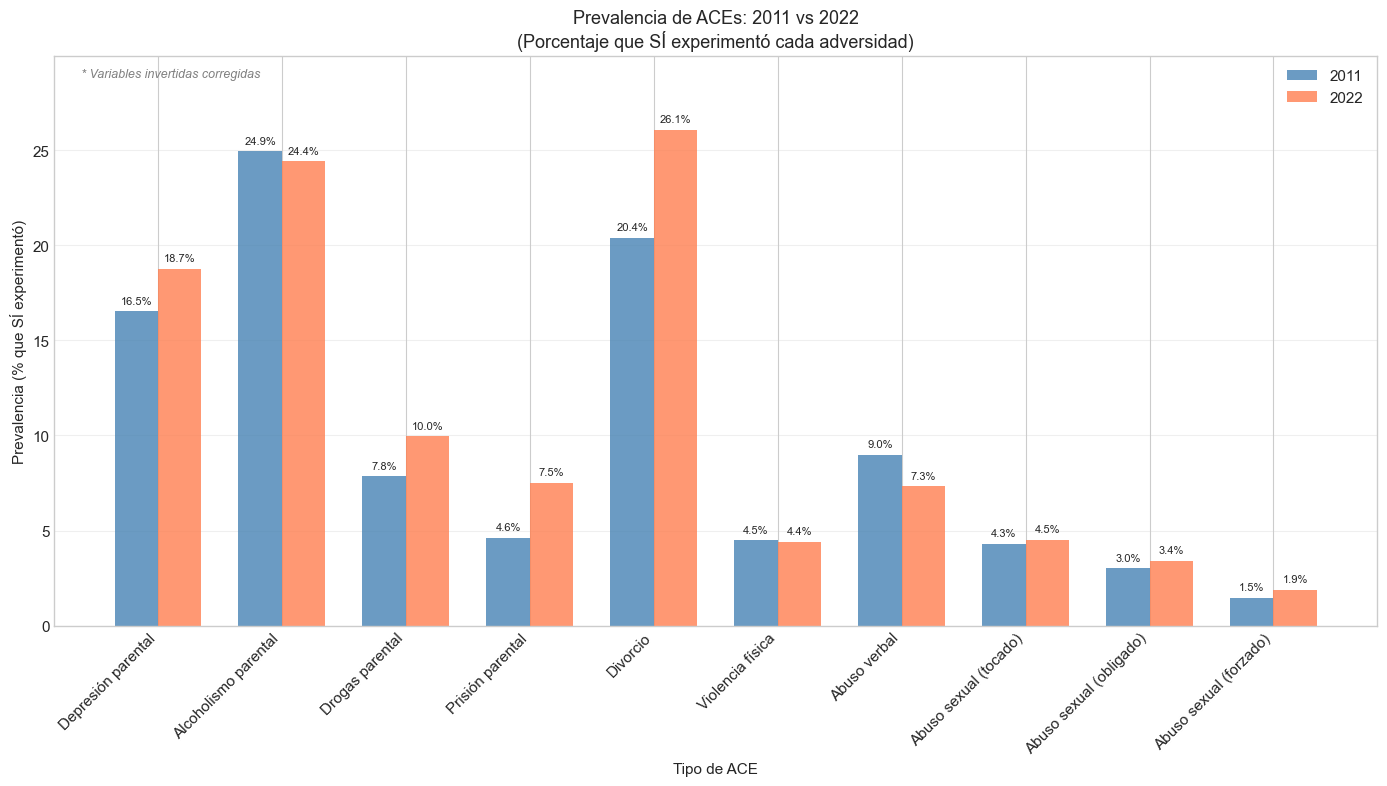

In [26]:
# ANÁLISIS Y VISUALIZACIÓN: Prevalencia de ACEs
print('='*60)
print('ANÁLISIS: PREVALENCIA DE ACEs (CORREGIDA)')
print('='*60)

# Usar función centralizada con corrección de codificación
prev_2011, prev_2022 = plot_prevalencia_aces(
    df_2011, df_2022, aces_vars, etiquetas_aces, 
    vars_invertidas=aces_invertidas
)

#### ¿Qué son las ACEs?
Las Experiencias Adversas en la Infancia (Adverse Childhood Experiences - ACEs) son eventos traumáticos o estresantes que ocurren antes de los 18 años. El estudio original de ACEs (Kaiser Permanente, 1998) demostró que estas experiencias tienen impactos profundos y duraderos en la salud física y mental a lo largo de la vida.

#### Formas de Abuso
- Abuso verbal: -18.9%

De 9.0% a 7.3%
Aproximadamente 1 de cada 11-14 adultos
Reducción significativa - refleja mayor conciencia sobre crianza positiva

- Violencia física: -2.2%

De 4.5% a 4.4%
Estabilidad relativa, ligera mejora
Aproximadamente 1 de cada 22 adultos

- Abuso sexual (forzado a tener sexo): +26.7%

De 1.5% a 1.9%
Aumento relativo más grande en abuso sexual
Aproximadamente 1 de cada 50-65 adultos

- Abuso sexual (obligado a tocar): +13.3%

De 3.0% a 3.4%
Aproximadamente 1 de cada 30 adultos


- Abuso sexual (tocado inapropiadamente): +4.7%

De 4.3% a 4.5%
Aproximadamente 1 de cada 22 adultos
Aumento pequeño pero presente

El gráfico sugiere cambios en la estructura familiar (más divorcios, más encarcelamiento parental) y problemas de salud mental/adicciones (depresión, drogas) como tendencias notablemente crecientes. La reducción en abuso verbal podría indicar mayor conciencia sobre sus efectos. Las formas de violencia directa se mantienen estables, lo cual puede reflejar tanto persistencia del problema como mejor detección.


ANÁLISIS: MARIHUANA (solo 2022)
Variable: MARJSMOK - Consumo de marihuana fumada

📌 MARJSMOK - Registros totales: 11,488
 Código  Frecuencia  Porcentaje Etiqueta
    1.0        8906       77.52       Sí
    2.0        2582       22.48       No


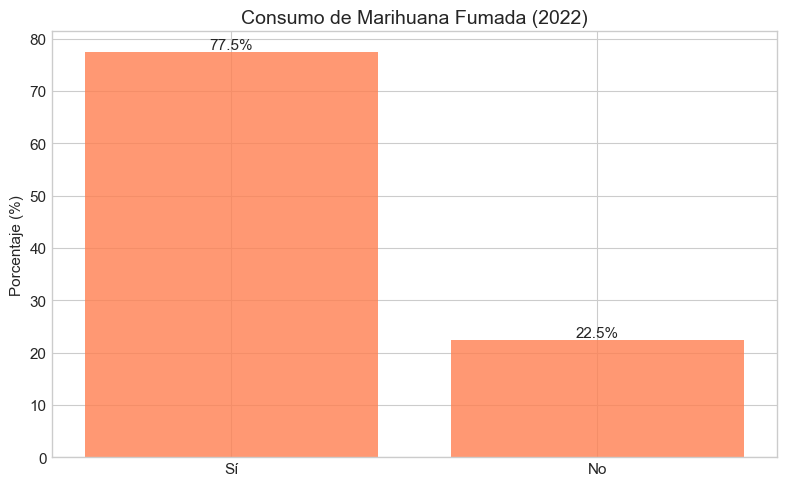

In [27]:
# CELDA 22: Marihuana (solo 2022)
print('='*60)
print('ANÁLISIS: MARIHUANA (solo 2022)')
print('='*60)
print(f'Variable: MARJSMOK - {SIGNIFICADOS["MARJSMOK"]}')
df_2022_mj_valido = df_2022[df_2022['MARJSMOK'].isin([1.0, 2.0])]
frecuencias(df_2022_mj_valido, 'MARJSMOK', {'MARJSMOK': {1: 'Sí', 2: 'No'}})

# Gráfico de barras para marihuana
fig, ax = plt.subplots(figsize=(8, 5))
freq = df_2022_mj_valido['MARJSMOK'].value_counts(normalize=True).sort_index() * 100
labels = ['Sí', 'No']
bars = ax.bar(labels, freq.values, color='coral', alpha=0.8)
for bar, val in zip(bars, freq.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=11)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Consumo de Marihuana Fumada (2022)', fontsize=14)
plt.tight_layout()
plt.savefig('marjsmok_2022.png', dpi=150, bbox_inches='tight')
plt.show()

ANÁLISIS: BIENESTAR SOCIAL (solo 2022)

--- LSATISFY: Satisfacción con la vida ---

📌 LSATISFY - Registros totales: 251,517
 Código  Frecuencia  Porcentaje         Etiqueta
    1.0      114252       45.43   Muy satisfecho
    2.0      123445       49.08       Satisfecho
    3.0       10758        4.28     Insatisfecho
    4.0        3062        1.22 Muy insatisfecho

--- EMTSUPRT: Apoyo emocional disponible ---

📌 EMTSUPRT - Registros totales: 249,946
 Código  Frecuencia  Porcentaje   Etiqueta
    1.0      118012       47.21    Siempre
    2.0       77907       31.17 Usualmente
    3.0       33813       13.53    A veces
    4.0       10835        4.33   Rara vez
    5.0        9379        3.75      Nunca

--- SDHISOLT: Frecuencia de aislamiento social ---

📌 SDHISOLT - Registros totales: 251,125
 Código  Frecuencia  Porcentaje   Etiqueta
    1.0        8098        3.22    Siempre
    2.0       13178        5.25 Usualmente
    3.0       53072       21.13    A veces
    4.0       70617  

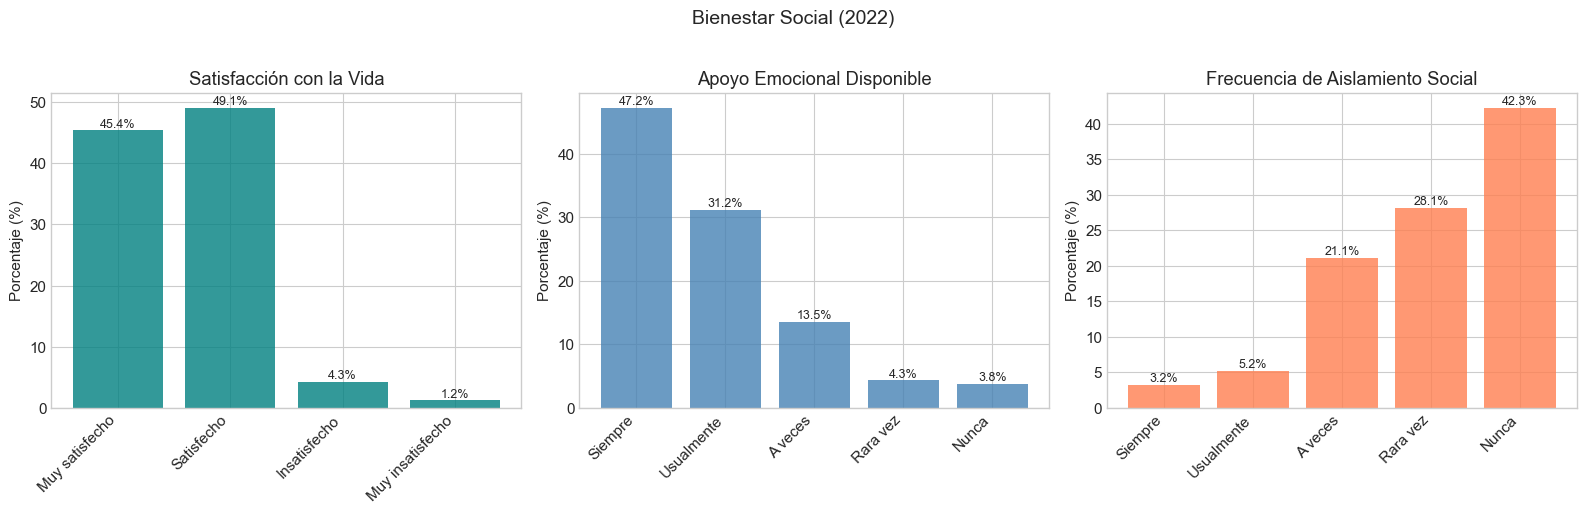

In [28]:
# CELDA 23: Bienestar Social (solo 2022)
print('='*60)
print('ANÁLISIS: BIENESTAR SOCIAL (solo 2022)')
print('='*60)

print(f'\n--- LSATISFY: {SIGNIFICADOS["LSATISFY"]} ---')
df_2022_lsat = df_2022[df_2022['LSATISFY'].isin([1.0, 2.0, 3.0, 4.0])]
frecuencias(df_2022_lsat, 'LSATISFY', ETIQUETAS)

print(f'\n--- EMTSUPRT: {SIGNIFICADOS["EMTSUPRT"]} ---')
df_2022_emt = df_2022[df_2022['EMTSUPRT'].isin([1.0, 2.0, 3.0, 4.0, 5.0])]
frecuencias(df_2022_emt, 'EMTSUPRT', ETIQUETAS)

print(f'\n--- SDHISOLT: {SIGNIFICADOS["SDHISOLT"]} ---')
df_2022_sdh = df_2022[df_2022['SDHISOLT'].isin([1.0, 2.0, 3.0, 4.0, 5.0])]
frecuencias(df_2022_sdh, 'SDHISOLT', ETIQUETAS)

# Gráficos de bienestar social (solo 2022)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# LSATISFY
freq_lsat = df_2022_lsat['LSATISFY'].value_counts(normalize=True).sort_index() * 100
labels_lsat = ['Muy satisfecho', 'Satisfecho', 'Insatisfecho', 'Muy insatisfecho']
bars = axes[0].bar(range(len(freq_lsat)), freq_lsat.values, color='teal', alpha=0.8)
axes[0].set_xticks(range(len(freq_lsat)))
axes[0].set_xticklabels(labels_lsat, rotation=45, ha='right')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_title('Satisfacción con la Vida')
for bar, val in zip(bars, freq_lsat.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

# EMTSUPRT
freq_emt = df_2022_emt['EMTSUPRT'].value_counts(normalize=True).sort_index() * 100
labels_emt = ['Siempre', 'Usualmente', 'A veces', 'Rara vez', 'Nunca']
bars = axes[1].bar(range(len(freq_emt)), freq_emt.values, color='steelblue', alpha=0.8)
axes[1].set_xticks(range(len(freq_emt)))
axes[1].set_xticklabels(labels_emt, rotation=45, ha='right')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Apoyo Emocional Disponible')
for bar, val in zip(bars, freq_emt.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

# SDHISOLT
freq_sdh = df_2022_sdh['SDHISOLT'].value_counts(normalize=True).sort_index() * 100
labels_sdh = ['Siempre', 'Usualmente', 'A veces', 'Rara vez', 'Nunca']
bars = axes[2].bar(range(len(freq_sdh)), freq_sdh.values, color='coral', alpha=0.8)
axes[2].set_xticks(range(len(freq_sdh)))
axes[2].set_xticklabels(labels_sdh, rotation=45, ha='right')
axes[2].set_ylabel('Porcentaje (%)')
axes[2].set_title('Frecuencia de Aislamiento Social')
for bar, val in zip(bars, freq_sdh.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Bienestar Social (2022)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('bienestar_social_2022.png', dpi=150, bbox_inches='tight')
plt.show()

ANÁLISIS: DEMOGRAFÍA

--- _AGE_G: Grupo de edad (calculada) ---

📌 _AGE_G - Registros totales: 506,467
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       23069        4.55    18-24
    2.0       49621        9.80    25-34
    3.0       65487       12.93    35-44
    4.0       92177       18.20    45-54
    5.0      115569       22.82    55-64
    6.0      160544       31.70      65+

📌 _AGE_G - Registros totales: 445,132
 Código  Frecuencia  Porcentaje Etiqueta
    1.0       26943        6.05    18-24
    2.0       47840       10.75    25-34
    3.0       59174       13.29    35-44
    4.0       66984       15.05    45-54
    5.0       82740       18.59    55-64
    6.0      161451       36.27      65+


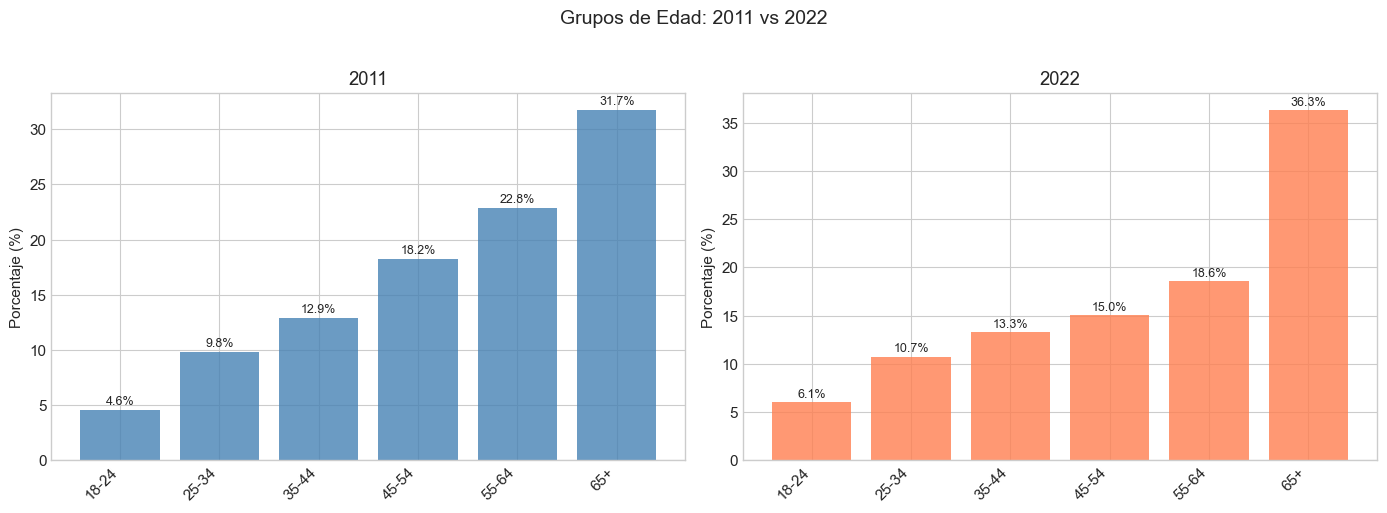


--- _EDUCAG: Nivel educativo (calculada) ---

📌 _EDUCAG - Registros totales: 504,539
 Código  Frecuencia  Porcentaje         Etiqueta
    1.0       46423        9.20   Sin secundaria
    2.0      149387       29.61       Secundaria
    3.0      136060       26.97 Algo universidad
    4.0      172669       34.22      Universidad

📌 _EDUCAG - Registros totales: 442,749
 Código  Frecuencia  Porcentaje         Etiqueta
    1.0       26011        5.87   Sin secundaria
    2.0      108990       24.62       Secundaria
    3.0      120252       27.16 Algo universidad
    4.0      187496       42.35      Universidad


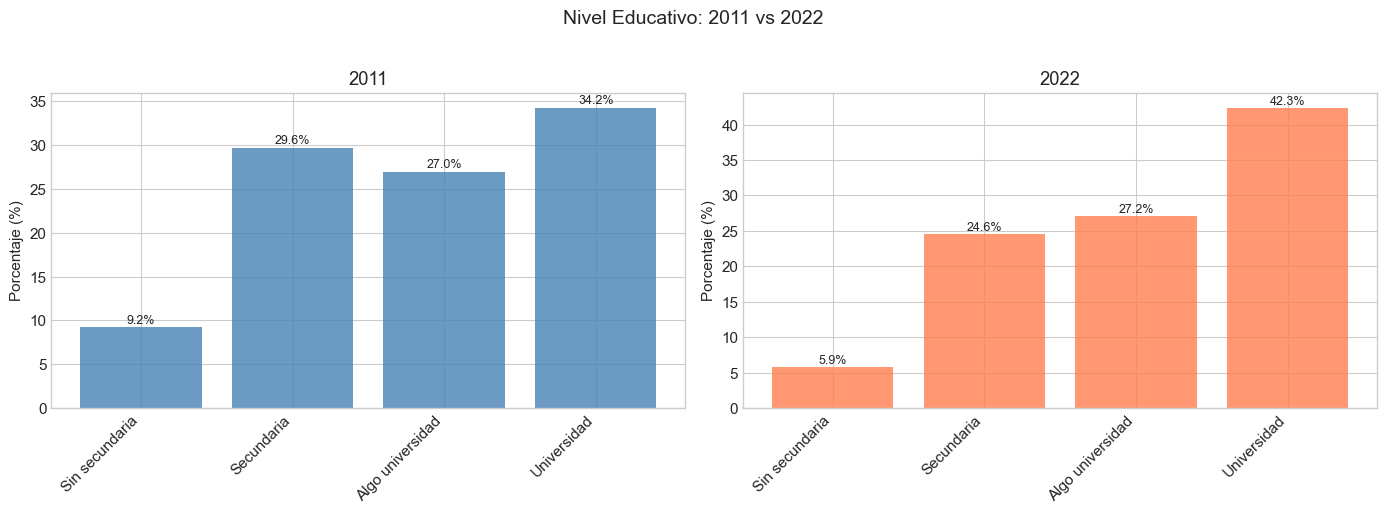


--- SEX/_SEX: Sexo ---

📌 SEXO - Registros totales: 506,467
 Código  Frecuencia  Porcentaje  Etiqueta
    1.0      198812       39.25 Masculino
    2.0      307655       60.75  Femenino

📌 SEXO - Registros totales: 445,132
 Código  Frecuencia  Porcentaje  Etiqueta
    1.0      209238       47.01 Masculino
    2.0      235894       52.99  Femenino


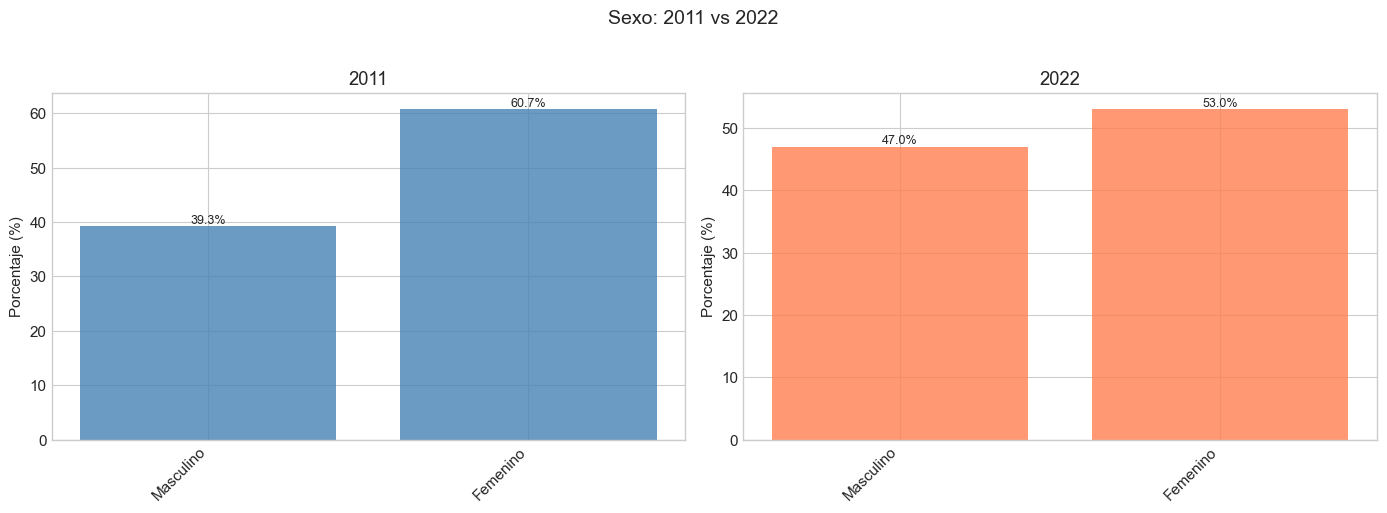


--- MARITAL: Estado civil ---

📌 MARITAL - Registros totales: 503,840
 Código  Frecuencia  Porcentaje        Etiqueta
    1.0      268086       53.21        Casado/a
    2.0       71211       14.13    Divorciado/a
    3.0       69887       13.87         Viudo/a
    4.0       11081        2.20      Separado/a
    5.0       70738       14.04  Nunca casado/a
    6.0       12837        2.55 Pareja de hecho

📌 MARITAL - Registros totales: 440,330
 Código  Frecuencia  Porcentaje        Etiqueta
    1.0      227424       51.65        Casado/a
    2.0       57516       13.06    Divorciado/a
    3.0       48019       10.91         Viudo/a
    4.0        8702        1.98      Separado/a
    5.0       80001       18.17  Nunca casado/a
    6.0       18668        4.24 Pareja de hecho


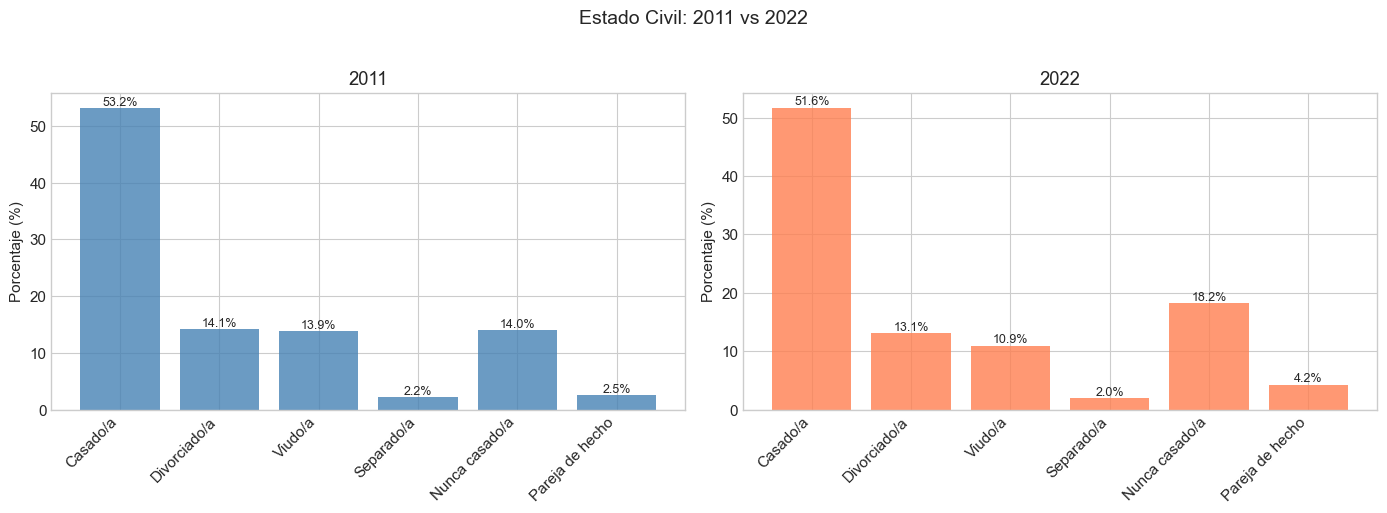


--- EMPLOY/EMPLOY1: Situación de empleo ---

📌 EMPLOY - Registros totales: 503,863
 Código  Frecuencia  Porcentaje           Etiqueta
    1.0      207193       41.12           Empleado
    2.0       40212        7.98       Autoempleado
    3.0       17129        3.40 Desempleado >1 año
    4.0       13971        2.77 Desempleado <1 año
    5.0       35353        7.02        Ama de casa
    6.0       11435        2.27         Estudiante
    7.0      142070       28.20           Retirado
    8.0       36500        7.24       Incapacitado

📌 EMPLOY1 - Registros totales: 433,892
 Código  Frecuencia  Porcentaje           Etiqueta
    1.0      186004       42.87           Empleado
    2.0       38768        8.93       Autoempleado
    3.0        8668        2.00 Desempleado >1 año
    4.0        8044        1.85 Desempleado <1 año
    5.0       17477        4.03        Ama de casa
    6.0       11111        2.56         Estudiante
    7.0      137083       31.59           Retirado
    8.0  

26569

In [30]:
# CELDA 24: Demografía
print('='*60)
print('ANÁLISIS: DEMOGRAFÍA')
print('='*60)

# Liberar memoria antes de continuar
import gc
gc.collect()

print(f'\n--- _AGE_G: {SIGNIFICADOS["_AGE_G"]} ---')
df_2011_age_valido = df_2011.loc[df_2011['_AGE_G'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0]), ['_AGE_G']].copy()
df_2022_age_valido = df_2022.loc[df_2022['_AGE_G'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0]), ['_AGE_G']].copy()
frecuencias(df_2011_age_valido, '_AGE_G', ETIQUETAS)
frecuencias(df_2022_age_valido, '_AGE_G', ETIQUETAS)
plot_comparacion_barras(df_2011_age_valido, df_2022_age_valido, '_AGE_G', ETIQUETAS, 'Grupos de Edad: 2011 vs 2022')

print(f'\n--- _EDUCAG: {SIGNIFICADOS["_EDUCAG"]} ---')
df_2011_edu_valido = df_2011.loc[df_2011['_EDUCAG'].isin([1.0, 2.0, 3.0, 4.0]), ['_EDUCAG']].copy()
df_2022_edu_valido = df_2022.loc[df_2022['_EDUCAG'].isin([1.0, 2.0, 3.0, 4.0]), ['_EDUCAG']].copy()
frecuencias(df_2011_edu_valido, '_EDUCAG', ETIQUETAS)
frecuencias(df_2022_edu_valido, '_EDUCAG', ETIQUETAS)
plot_comparacion_barras(df_2011_edu_valido, df_2022_edu_valido, '_EDUCAG', ETIQUETAS, 'Nivel Educativo: 2011 vs 2022')

print(f'\n--- SEX/_SEX: {SIGNIFICADOS["SEX"]} ---')
df_2011_sexo = df_2011[['SEX']].rename(columns={'SEX': 'SEXO'}).copy()
df_2022_sexo = df_2022[['_SEX']].rename(columns={'_SEX': 'SEXO'}).copy()
frecuencias(df_2011_sexo, 'SEXO', {'SEXO': ETIQUETAS['SEX']})
frecuencias(df_2022_sexo, 'SEXO', {'SEXO': ETIQUETAS['_SEX']})
plot_comparacion_barras(df_2011_sexo, df_2022_sexo, 'SEXO', {'SEXO': ETIQUETAS['SEX']}, 'Sexo: 2011 vs 2022')

print(f'\n--- MARITAL: {SIGNIFICADOS["MARITAL"]} ---')
df_2011_marital_valido = df_2011.loc[df_2011['MARITAL'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0]), ['MARITAL']].copy()
df_2022_marital_valido = df_2022.loc[df_2022['MARITAL'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0]), ['MARITAL']].copy()
frecuencias(df_2011_marital_valido, 'MARITAL', ETIQUETAS)
frecuencias(df_2022_marital_valido, 'MARITAL', ETIQUETAS)
plot_comparacion_barras(df_2011_marital_valido, df_2022_marital_valido, 'MARITAL', ETIQUETAS, 'Estado Civil: 2011 vs 2022')

print(f'\n--- EMPLOY/EMPLOY1: {SIGNIFICADOS["EMPLOY"]} ---')
if 'EMPLOY' in df_2011.columns:
    df_2011_emp_valido = df_2011.loc[df_2011['EMPLOY'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]), ['EMPLOY']].copy()
    frecuencias(df_2011_emp_valido, 'EMPLOY', ETIQUETAS)
if 'EMPLOY1' in df_2022.columns:
    df_2022_emp_valido = df_2022.loc[df_2022['EMPLOY1'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]), ['EMPLOY1']].copy()
    frecuencias(df_2022_emp_valido, 'EMPLOY1', ETIQUETAS)

gc.collect()

ANÁLISIS: CORRELACIONES - MATRICES TEMÁTICAS

📊 MATRIZ 1: Indicadores de Salud General


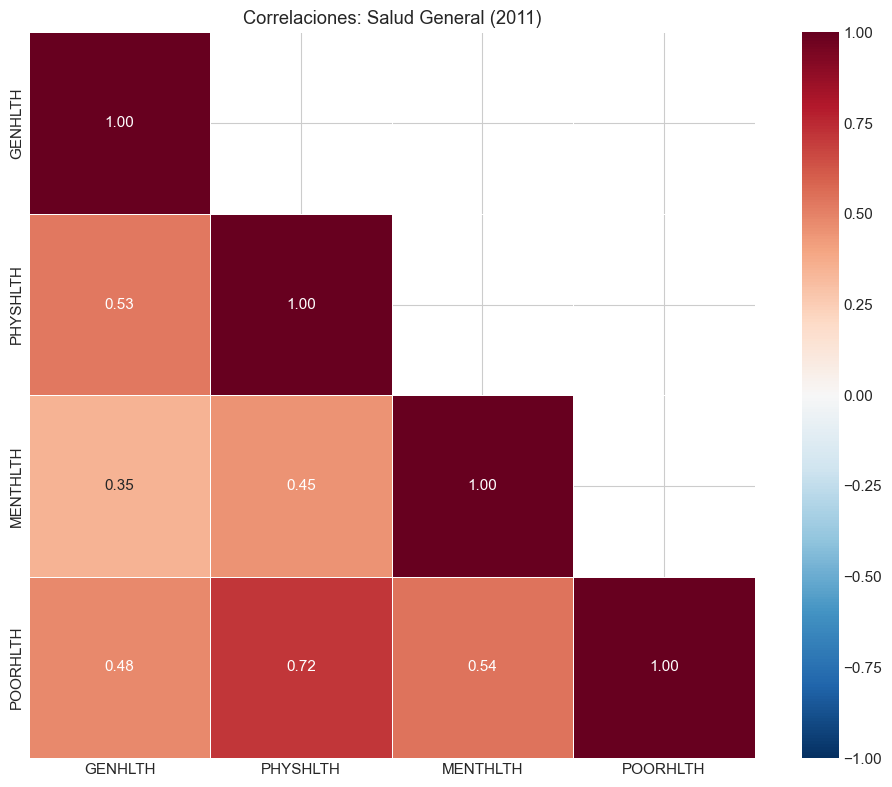


📊 MATRIZ 2: Sueño, Salud Mental y Física


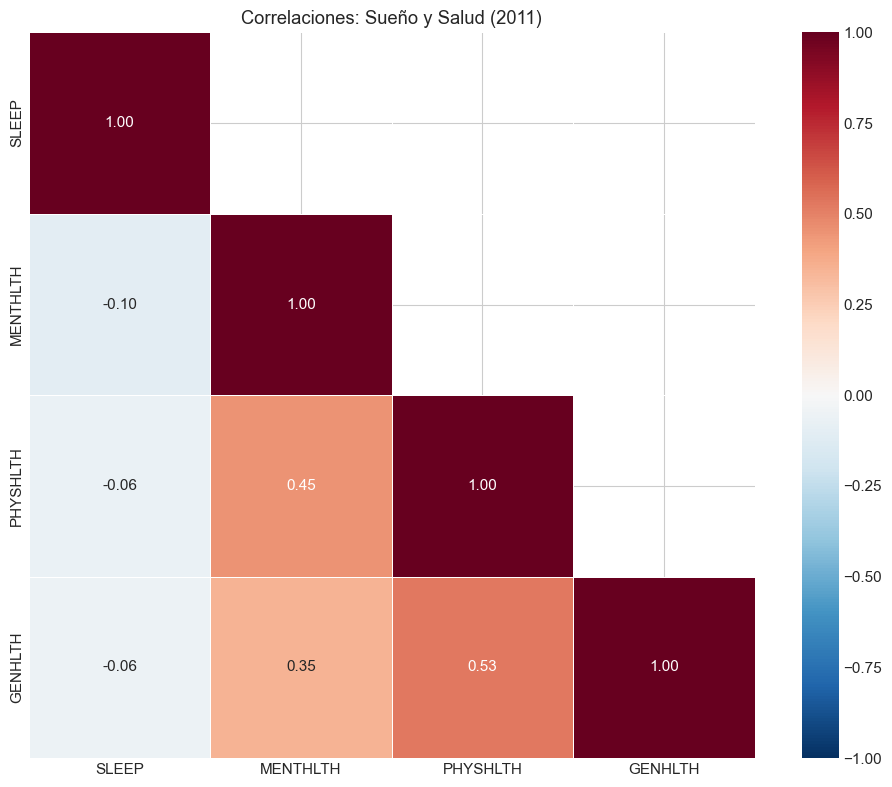


📊 MATRIZ 3: Factores de Riesgo (IMC, Tabaco, Actividad)


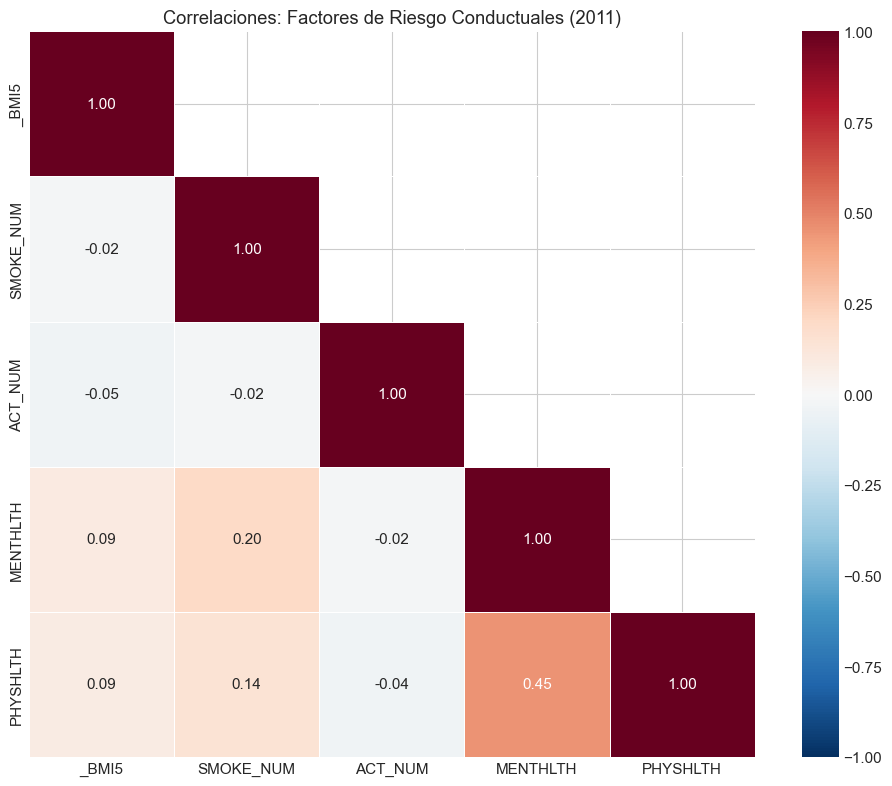


📊 MATRIZ 4: ACEs y Salud Mental (2011)


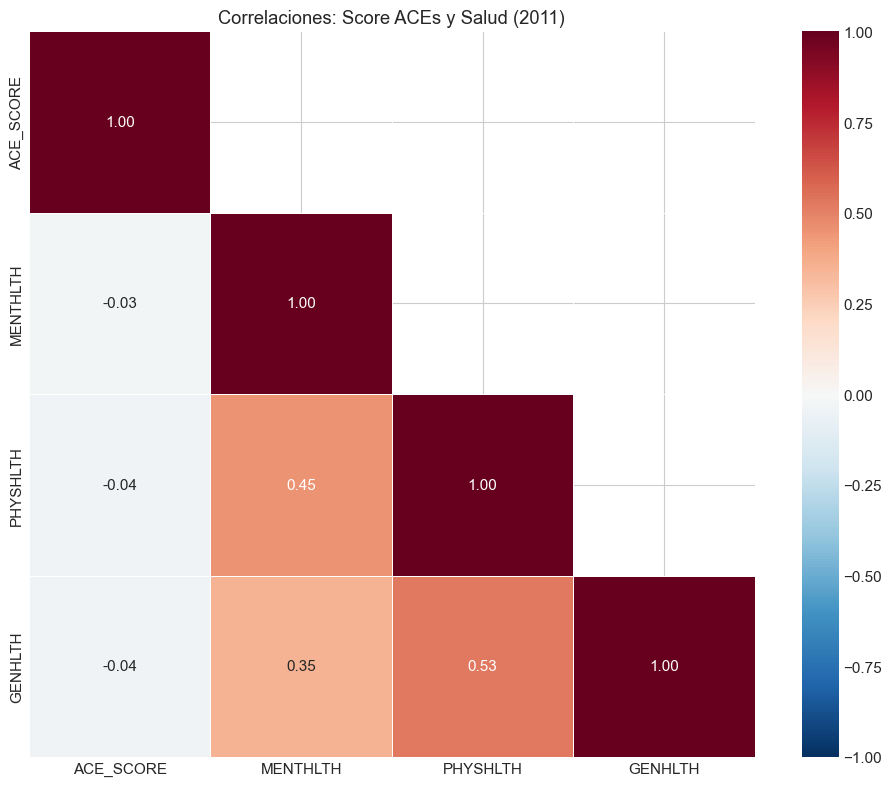


✅ Matrices de correlación temáticas completadas


In [31]:
# CELDA 25: Correlaciones
print('='*60)
print('ANÁLISIS: CORRELACIONES - MATRICES TEMÁTICAS')
print('='*60)

# 1. CORRELACIONES: SALUD FÍSICA Y MENTAL
print('\n📊 MATRIZ 1: Indicadores de Salud General')
vars_salud = ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH']
plot_correlaciones(df_2011, vars_salud, 'Correlaciones: Salud General (2011)')

# 2. CORRELACIONES: SUEÑO Y SALUD MENTAL (más relevante teóricamente)
print('\n📊 MATRIZ 2: Sueño, Salud Mental y Física')
# Crear variables unificadas para comparación
df_2011['SLEEP'] = df_2011['SLEPTIME'] if 'SLEPTIME' in df_2011.columns else np.nan
df_2022['SLEEP'] = df_2022['SLEPTIM1'] if 'SLEPTIM1' in df_2022.columns else np.nan

vars_sueno_salud_2011 = ['SLEEP', 'MENTHLTH', 'PHYSHLTH', 'GENHLTH']
vars_disp_2011 = [v for v in vars_sueno_salud_2011 if v in df_2011.columns]
if len(vars_disp_2011) >= 2:
    plot_correlaciones(df_2011, vars_disp_2011, 'Correlaciones: Sueño y Salud (2011)')

# 3. CORRELACIONES: FACTORES DE RIESGO CONDUCTUALES
print('\n📊 MATRIZ 3: Factores de Riesgo (IMC, Tabaco, Actividad)')
# Crear variable numérica de fumador
for df in [df_2011, df_2022]:
    df['SMOKE_NUM'] = df['_SMOKER3'].replace({1: 4, 2: 3, 3: 2, 4: 1, 9: np.nan})  # Invertido: más alto = fuma más
    df['ACT_NUM'] = df['_TOTINDA'].replace({1: 1, 2: 0})  # 1=Activo, 0=Inactivo

vars_riesgo_2011 = ['_BMI5', 'SMOKE_NUM', 'ACT_NUM', 'MENTHLTH', 'PHYSHLTH']
vars_disp_riesgo = [v for v in vars_riesgo_2011 if v in df_2011.columns]
if len(vars_disp_riesgo) >= 2:
    # Filtrar IMC válido (dividir por 100 ya que está almacenado así)
    df_temp = df_2011[vars_disp_riesgo].copy()
    df_temp['_BMI5'] = df_temp['_BMI5'] / 100  # Convertir a IMC real
    df_temp = df_temp[(df_temp['_BMI5'] > 10) & (df_temp['_BMI5'] < 60)]  # Filtrar valores válidos
    
    fig, ax = plt.subplots(figsize=(10, 8))
    df_num = df_temp.apply(pd.to_numeric, errors='coerce')
    for col in df_num.columns:
        df_num.loc[df_num[col] >= 77, col] = np.nan
    corr_matrix = df_num.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Correlaciones: Factores de Riesgo Conductuales (2011)')
    plt.tight_layout()
    plt.savefig('corr_riesgo.png', dpi=150, bbox_inches='tight')
    plt.show()

# 4. CORRELACIONES: ACEs Y SALUD MENTAL
print('\n📊 MATRIZ 4: ACEs y Salud Mental (2011)')
# Crear score de ACEs
aces_vars = ['ACEDEPRS', 'ACEDRINK', 'ACEDRUGS', 'ACEPRISN', 'ACEDIVRC',
             'ACEPUNCH', 'ACESWEAR', 'ACETOUCH', 'ACETTHEM', 'ACEHVSEX']

for df in [df_2011, df_2022]:
    aces_disp = [v for v in aces_vars if v in df.columns]
    if len(aces_disp) > 0:
        # Crear score: suma de ACEs (1=Sí)
        df_aces = df[aces_disp].copy()
        for col in aces_disp:
            df_aces[col] = (df[col] == 1).astype(float)
        df['ACE_SCORE'] = df_aces.sum(axis=1)
        df.loc[df[aces_disp].isna().all(axis=1), 'ACE_SCORE'] = np.nan

# Correlación ACEs con salud mental
vars_aces_mental = ['ACE_SCORE', 'MENTHLTH', 'PHYSHLTH', 'GENHLTH']
vars_disp_aces = [v for v in vars_aces_mental if v in df_2011.columns]
if len(vars_disp_aces) >= 2:
    plot_correlaciones(df_2011, vars_disp_aces, 'Correlaciones: Score ACEs y Salud (2011)')

print('\n✅ Matrices de correlación temáticas completadas')

NOTA: Correlación no implica causalidad. Que dos variables estén correlacionadas no significa que una cause la otra.
### Hallazgos principales:
#### Matriz 1

- PHYSHLTH ↔ POORHLTH: r = 0.72 — La salud física es el predictor más fuerte de los días totales de mala salud. Esto indica que los problemas físicos tienen mayor peso en la percepción global de salud deficiente.
- GENHLTH ↔ PHYSHLTH: r = 0.53 — La autopercepción de salud general está fuertemente ligada al estado físico.
- GENHLTH ↔ MENTHLTH: r = 0.35 — La correlación más baja, sugiriendo que la salud mental influye menos en la autopercepción general.

#### Matriz 2
Las correlaciones negativas indican que más horas de sueño se asocian ligeramente con menos días de mala salud, pero la relación es tan débil que es casi irrelevante estadísticamente.

#### Matriz 3
Estas correlaciones débiles podrían deberse a que los efectos del IMC, tabaco y sedentarismo son acumulativos a largo plazo, mientras que MENTHLTH y PHYSHLTH miden días de mala salud en los últimos 30 días. El impacto de estos factores se manifiesta más en enfermedades crónicas que en malestar inmediato.

#### Matriz 4
El puntaje de ACEs (experiencias adversas en la infancia) no muestra correlación con los indicadores de salud actuales.



ANÁLISIS: GRÁFICOS DE DISPERSIÓN - RELACIONES CLAVE

📈 1. Relación Salud Física-Mental (bidireccional clásica)


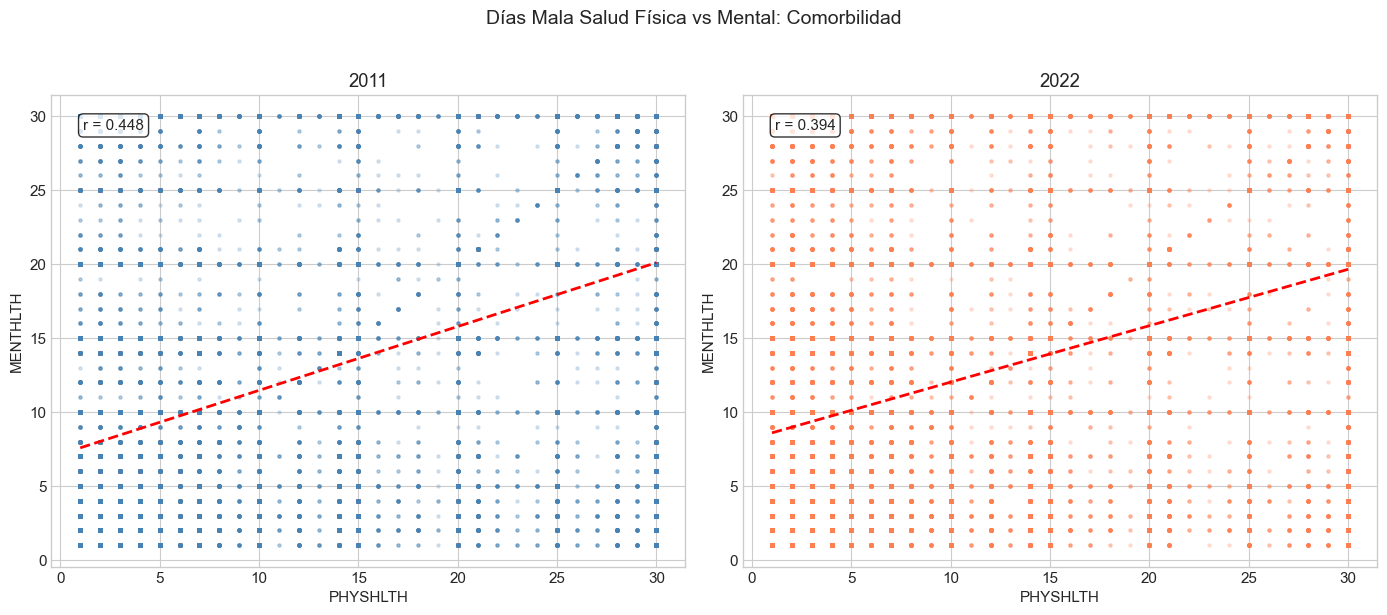


📈 2. Relación Sueño-Salud Mental


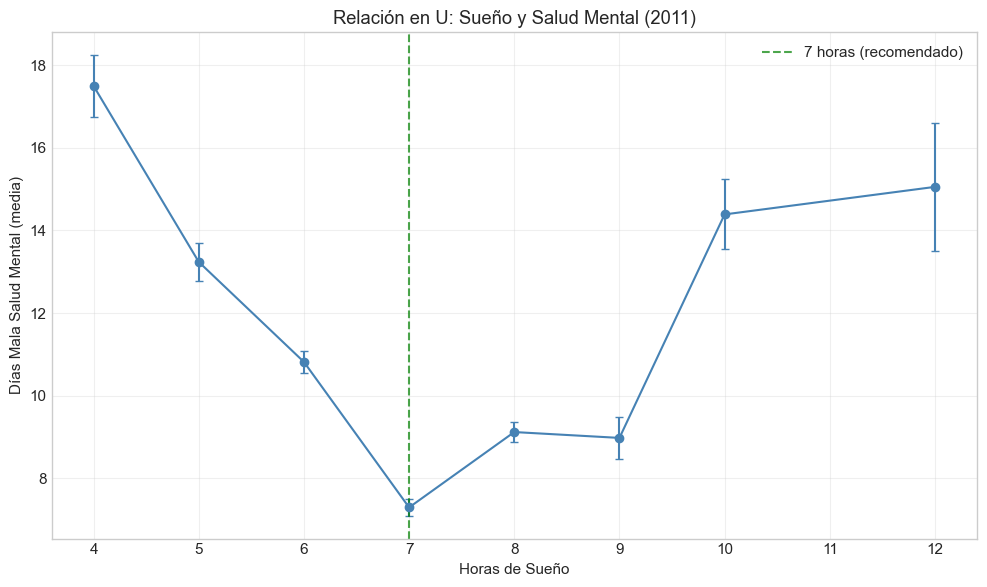

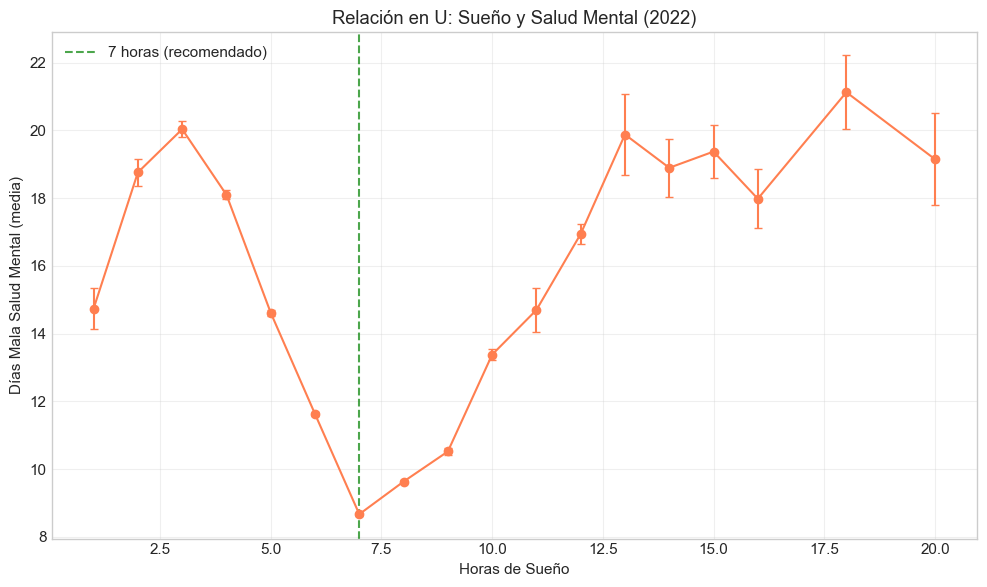


📈 3. Relación Dosis-Respuesta: ACEs y Salud Mental


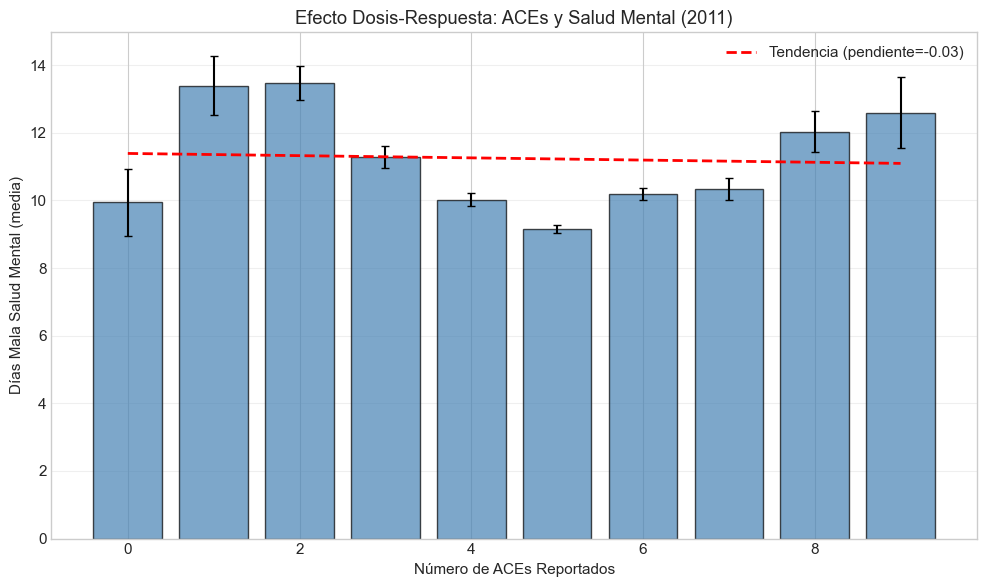

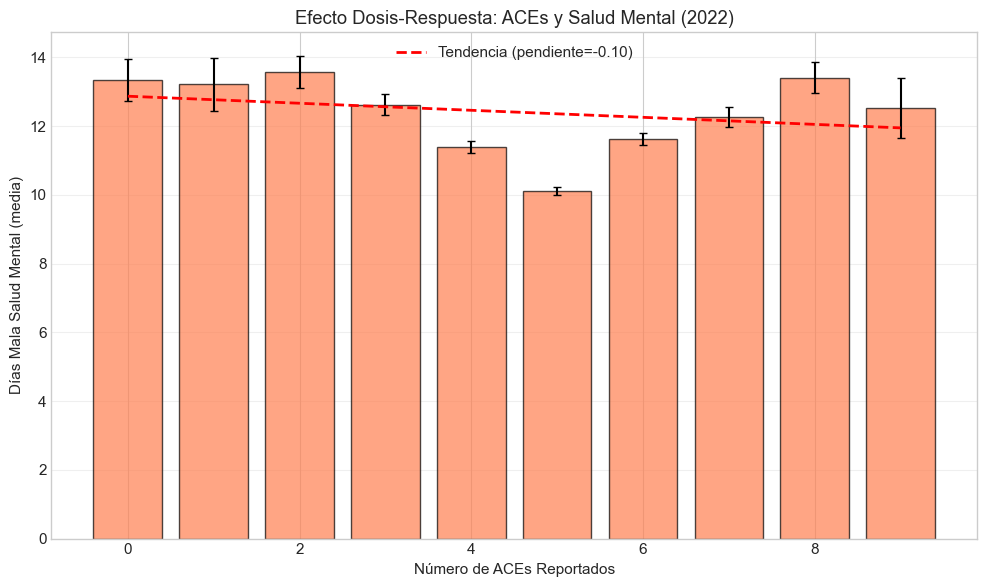


📈 4. IMC vs Salud Mental por Categoría


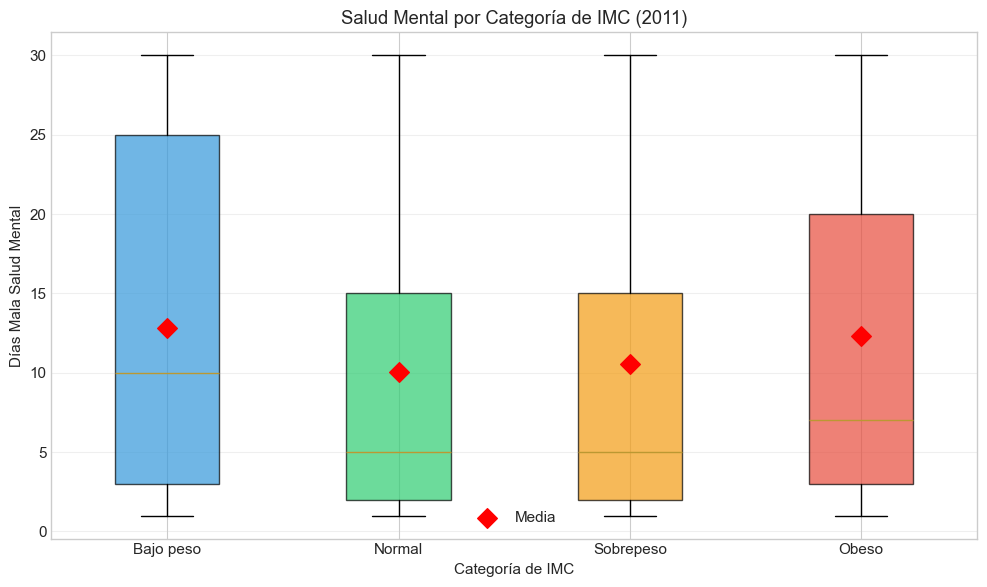

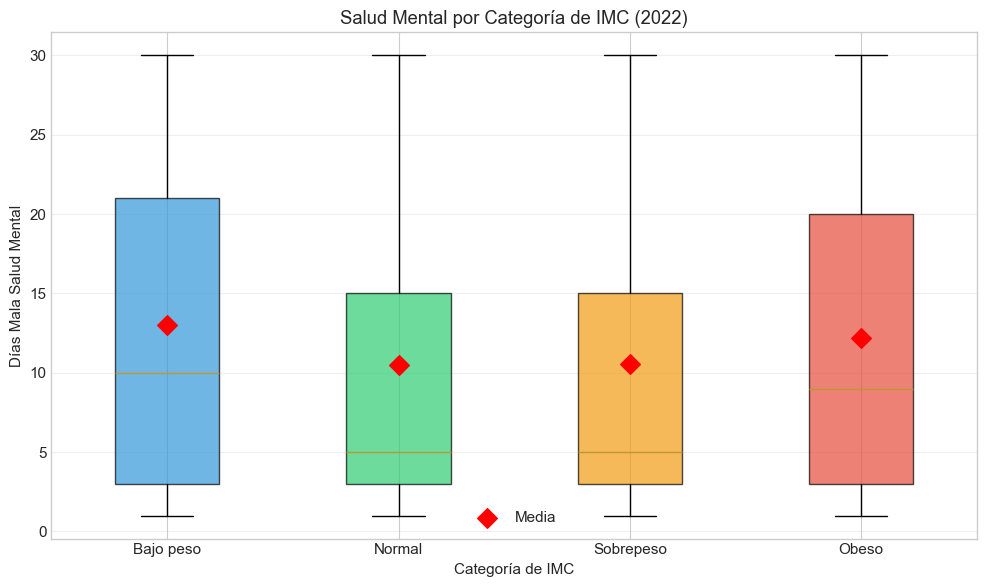


✅ Gráficos de dispersión y relaciones completados


In [32]:
# CELDA 26: Dispersión
print('='*60)
print('ANÁLISIS: GRÁFICOS DE DISPERSIÓN - RELACIONES CLAVE')
print('='*60)

# 1. SALUD FÍSICA vs SALUD MENTAL (relación fundamental)
print('\n📈 1. Relación Salud Física-Mental (bidireccional clásica)')
plot_dispersion_comparativo(df_2011, df_2022, 'PHYSHLTH', 'MENTHLTH', 
                           'Días Mala Salud Física vs Mental: Comorbilidad')

# 2. SUEÑO vs SALUD MENTAL (hipótesis de investigación)
print('\n📈 2. Relación Sueño-Salud Mental')
# Filtrar valores válidos de sueño
for df, year in [(df_2011, 2011), (df_2022, 2022)]:
    if 'SLEEP' in df.columns and 'MENTHLTH' in df.columns:
        # Relación no lineal: tanto poco como mucho sueño se asocian con peor salud
        fig, ax = plt.subplots(figsize=(10, 6))
        x = pd.to_numeric(df['SLEEP'], errors='coerce')
        y = pd.to_numeric(df['MENTHLTH'], errors='coerce')
        mask = (x >= 1) & (x <= 24) & (y >= 0) & (y <= 30)
        x, y = x[mask], y[mask]
        
        # Calcular media de MENTHLTH por hora de sueño
        sleep_mental = pd.DataFrame({'sleep': x, 'mental': y})
        medias = sleep_mental.groupby('sleep')['mental'].agg(['mean', 'std', 'count'])
        medias = medias[medias['count'] > 50]  # Solo grupos con suficientes datos
        
        ax.errorbar(medias.index, medias['mean'], yerr=medias['std']/np.sqrt(medias['count']),
                   fmt='o-', capsize=3, capthick=1, color='steelblue' if year == 2011 else 'coral')
        ax.axvline(x=7, color='green', linestyle='--', alpha=0.7, label='7 horas (recomendado)')
        ax.set_xlabel('Horas de Sueño')
        ax.set_ylabel('Días Mala Salud Mental (media)')
        ax.set_title(f'Relación en U: Sueño y Salud Mental ({year})')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'sueno_mental_{year}.png', dpi=150, bbox_inches='tight')
        plt.show()

# 3. ACE SCORE vs SALUD MENTAL (hipótesis de dosis-respuesta)
print('\n📈 3. Relación Dosis-Respuesta: ACEs y Salud Mental')
for df, year in [(df_2011, 2011), (df_2022, 2022)]:
    if 'ACE_SCORE' in df.columns and 'MENTHLTH' in df.columns:
        fig, ax = plt.subplots(figsize=(10, 6))
        x = pd.to_numeric(df['ACE_SCORE'], errors='coerce')
        y = pd.to_numeric(df['MENTHLTH'], errors='coerce')
        mask = x.notna() & y.notna() & (y <= 30)
        x, y = x[mask], y[mask]
        
        # Media por número de ACEs
        ace_mental = pd.DataFrame({'ace': x, 'mental': y})
        medias = ace_mental.groupby('ace')['mental'].agg(['mean', 'std', 'count'])
        medias = medias[medias['count'] > 30]
        
        ax.bar(medias.index, medias['mean'], color='steelblue' if year == 2011 else 'coral', 
               alpha=0.7, edgecolor='black')
        ax.errorbar(medias.index, medias['mean'], yerr=medias['std']/np.sqrt(medias['count']),
                   fmt='none', capsize=3, capthick=1, color='black')
        
        # Línea de tendencia
        z = np.polyfit(medias.index, medias['mean'], 1)
        p = np.poly1d(z)
        ax.plot(medias.index, p(medias.index), 'r--', linewidth=2, label=f'Tendencia (pendiente={z[0]:.2f})')
        
        ax.set_xlabel('Número de ACEs Reportados')
        ax.set_ylabel('Días Mala Salud Mental (media)')
        ax.set_title(f'Efecto Dosis-Respuesta: ACEs y Salud Mental ({year})')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(f'aces_mental_{year}.png', dpi=150, bbox_inches='tight')
        plt.show()

# 4. IMC vs SALUD MENTAL por grupos (análisis exploratorio para regresión)
print('\n📈 4. IMC vs Salud Mental por Categoría')
for df, year in [(df_2011, 2011), (df_2022, 2022)]:
    if '_BMI5CAT' in df.columns and 'MENTHLTH' in df.columns:
        fig, ax = plt.subplots(figsize=(10, 6))
        df_valid = df[df['_BMI5CAT'].isin([1, 2, 3, 4]) & (df['MENTHLTH'] <= 30)]
        
        bmi_labels = {1: 'Bajo peso', 2: 'Normal', 3: 'Sobrepeso', 4: 'Obeso'}
        colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
        
        data_by_cat = [df_valid[df_valid['_BMI5CAT'] == cat]['MENTHLTH'].dropna() for cat in [1, 2, 3, 4]]
        bp = ax.boxplot(data_by_cat, labels=[bmi_labels[i] for i in [1, 2, 3, 4]], patch_artist=True)
        
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        # Agregar medias
        medias = [d.mean() for d in data_by_cat]
        ax.scatter(range(1, 5), medias, color='red', s=100, zorder=3, marker='D', label='Media')
        
        ax.set_xlabel('Categoría de IMC')
        ax.set_ylabel('Días Mala Salud Mental')
        ax.set_title(f'Salud Mental por Categoría de IMC ({year})')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(f'imc_mental_{year}.png', dpi=150, bbox_inches='tight')
        plt.show()

print('\n✅ Gráficos de dispersión y relaciones completados')

#### ¿Qué significa "comorbilidad"?
Que ambos problemas (físico y mental) tienden a ocurrir juntos. El gráfico confirma esta conexión: las personas con más problemas físicos también tienden a reportar más problemas mentales.

#### Relación en U: Sueño y Salud Mental

2011

Hallazgo clave: El sueño tiene una relación curvilínea (en forma de U), no lineal.

El punto óptimo es 7 horas (menor cantidad de días de mala salud mental: ~7.3 días)
Dormir menos de 7 horas → más problemas mentales (4 horas = ~17.5 días)
Dormir más de 7 horas → también más problemas (10-12 horas = ~14-15 días)

Esto explica por qué la correlación lineal era casi cero: la relación existe, pero no es una línea recta.

2022

La "U" es más profunda, sugiriendo que la relación sueño-salud mental se intensificó

#### Efecto Dosis-Respuesta: ACEs y Salud Mental 
En ambos años, el número de ACEs no predice linealmente los días de mala salud mental.

#### Salud Mental por Categoría de IMC
Bajo peso y obesidad muestran peor salud mental que peso normal/sobrepeso. El grupo de bajo peso tiene la mayor variabilidad (caja más grande).

In [15]:
print("""
╔══════════════════════════════════════════════════════════════════════════════════════════════╗
║                    PREGUNTAS DE INVESTIGACIÓN SELECCIONADAS                                  ║
║                         Y TÉCNICAS ESTADÍSTICAS ASOCIADAS                                    ║
╚══════════════════════════════════════════════════════════════════════════════════════════════╝

Se han seleccionado 7 preguntas de investigación que permiten aplicar las 5 técnicas 
requeridas de manera justificada. Las preguntas evitan redundancias y buscan resultados
de interés teórico y práctico.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREGUNTA 1: RELACIÓN DOSIS-RESPUESTA ENTRE ACEs Y SALUD MENTAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ¿Existe una relación dosis-respuesta entre el número de experiencias adversas en la 
   infancia (ACEs) y los días de mala salud mental en adultos?

   📊 TÉCNICA: REGRESIÓN LINEAL
   
   ✅ JUSTIFICACIÓN:
   • Variable dependiente (MENTHLTH): continua (0-30 días)
   • Variable independiente principal (ACE_SCORE): cuantitativa (0-10 ACEs)
   • La regresión permite cuantificar el aumento esperado en días de mala salud mental 
     por cada ACE adicional reportado
   • Se pueden incluir covariables (edad, sexo, educación) para ajuste
   • El coeficiente β indica el "peso" del trauma acumulado en la salud mental
   
   🔬 HIPÓTESIS: Cada ACE adicional se asocia con un aumento significativo en días de 
   mala salud mental, sugiriendo un efecto acumulativo del trauma infantil.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREGUNTA 2: PREDICCIÓN DE DIAGNÓSTICO DE DEPRESIÓN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ¿Pueden los factores sociodemográficos, conductuales y de salud física predecir el 
   diagnóstico de depresión (ADDEPEV2/ADDEPEV3)?

   📊 TÉCNICA: REGRESIÓN LOGÍSTICA (CLASIFICACIÓN)
   
   ✅ JUSTIFICACIÓN:
   • Variable dependiente binaria: Depresión diagnosticada (Sí=1, No=2)
   • Predictores mixtos: edad, sexo, IMC, actividad física, sueño, ACEs
   • La regresión logística proporciona odds ratios interpretables clínicamente
   • Permite evaluar la contribución relativa de cada factor de riesgo
   • Superior a otros clasificadores cuando se requiere interpretabilidad médica
   
   🔬 POTENCIAL SORPRENDENTE: El sueño inadecuado (tanto poco como excesivo) podría 
   emerger como predictor más fuerte que el IMC para depresión.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREGUNTA 3: PERFILES DE COMPORTAMIENTO DE SALUD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ¿Se pueden identificar perfiles distintos de comportamiento de salud en la población 
   basados en tabaquismo, IMC, actividad física, consumo de alcohol y horas de sueño?

   📊 TÉCNICA: CLUSTERING (K-MEANS)
   
   ✅ JUSTIFICACIÓN:
   • Variables múltiples de comportamiento que se agrupan naturalmente
   • K-Means es apropiado para identificar patrones en datos continuos/ordinales
   • Permite descubrir combinaciones de factores de riesgo que co-ocurren
   • Útil para diseñar intervenciones dirigidas a perfiles específicos
   • La estandarización de variables permite comparación equitativa
   
   🔬 POTENCIAL SORPRENDENTE: Podría emerger un perfil de "paradoja de obesidad saludable" 
   (obesos pero físicamente activos con buenos indicadores de salud mental) vs. un perfil 
   de "peso normal pero alto riesgo" (IMC normal pero sedentarios y fumadores).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREGUNTA 4: DIMENSIONES SUBYACENTES DE SALUD Y BIENESTAR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ¿Cuáles son las dimensiones latentes que subyacen a los múltiples indicadores de 
   salud, bienestar y comportamiento de riesgo en los datos?

   📊 TÉCNICA: ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
   
   ✅ JUSTIFICACIÓN:
   • Múltiples variables correlacionadas de salud y comportamiento
   • PCA reduce dimensionalidad preservando la máxima varianza
   • Permite identificar constructos latentes (ej: "salud física", "bienestar mental", 
     "comportamiento de riesgo")
   • Los loadings revelan qué variables definen cada dimensión
   • Facilita visualización de relaciones complejas en 2D/3D
   
   🔬 HIPÓTESIS: Se esperan al menos 3 componentes principales: (1) Salud física-funcional, 
   (2) Salud mental-emocional, (3) Comportamientos de riesgo. Un hallazgo sorprendente 
   sería si el sueño carga en una dimensión separada de la salud mental.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREGUNTA 5: CAMBIO EN PREVALENCIA DE DEPRESIÓN 2011-2022
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ¿Ha aumentado significativamente la prevalencia de depresión diagnosticada entre 
   2011 y 2022, y este cambio es diferente según grupos de edad?

   📊 TÉCNICA: PRUEBA DE HIPÓTESIS (CHI-CUADRADO)
   
   ✅ JUSTIFICACIÓN:
   • Variables categóricas: Año (2011/2022), Depresión (Sí/No), Edad (grupos)
   • Chi-cuadrado evalúa independencia entre variables categóricas
   • Permite determinar si los cambios temporales son estadísticamente significativos
   • El análisis estratificado por edad revela si hay interacción (¿jóvenes más afectados?)
   • Los residuos estandarizados identifican qué celdas contribuyen más a la asociación
   
   🔬 POTENCIAL SORPRENDENTE: El aumento podría ser desproporcionadamente mayor en 
   adultos jóvenes (18-34), sugiriendo una "epidemia de salud mental" generacional 
   previa y amplificada por COVID-19.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREGUNTA 6: DIFERENCIAS EN CALIDAD DE SUEÑO SEGÚN HIPERTENSIÓN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ¿Existen diferencias significativas en las horas de sueño entre personas con y sin 
   diagnóstico de presión arterial alta (BPHIGH4)?

   📊 TÉCNICA: PRUEBA DE HIPÓTESIS (MANN-WHITNEY U / T-TEST)
   
   ✅ JUSTIFICACIÓN:
   • Variable continua (SLEPTIME/SLEPTIM1) comparada entre dos grupos independientes
   • Mann-Whitney es apropiado si la distribución de sueño no es normal
   • La prueba t puede usarse con muestras grandes por Teorema Central del Límite
   • Relevancia clínica: la apnea del sueño es comórbida con hipertensión
   • Permite cuantificar la diferencia en horas de sueño (effect size)
   
   🔬 HIPÓTESIS DIRECCIONAL: Las personas con hipertensión reportarán horas de sueño 
   diferentes (posiblemente en forma de U: más personas con muy poco o mucho sueño).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREGUNTA 7: CLASIFICACIÓN DE BUENA SALUD AUTOPERCIBIDA (K-NN)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ¿Puede un modelo K-NN predecir si una persona reportará buena salud autopercibida 
   (_RFHLTH) basándose en sus características conductuales y condiciones crónicas?

   📊 TÉCNICA: CLASIFICACIÓN (K-NN)
   
   ✅ JUSTIFICACIÓN:
   • K-NN es apropiado para clasificación binaria con múltiples predictores
   • No asume linealidad ni distribución específica de los datos
   • Permite comparar su rendimiento con regresión logística (complementario)
   • La selección de K óptimo mediante validación cruzada asegura robustez
   • Variables predictoras: días salud física/mental, IMC, actividad, sueño, condiciones
   
   🔬 APLICACIÓN PRÁCTICA: Un modelo predictivo de "buena salud" podría identificar 
   personas en riesgo de deterioro que aún no lo perciben, permitiendo intervención temprana.

╔══════════════════════════════════════════════════════════════════════════════════════════════╗
║                           RESUMEN: COBERTURA DE TÉCNICAS                                     ║
╚══════════════════════════════════════════════════════════════════════════════════════════════╝

   ┌────────────────────────────────┬────────────────────────────────────────────────────┐
   │ TÉCNICA                        │ PREGUNTA                                           │
   ├────────────────────────────────┼────────────────────────────────────────────────────┤
   │ 1. Pruebas de Hipótesis        │ P5 (Chi-cuadrado), P6 (Mann-Whitney/t-test)        │
   │ 2. Regresión Lineal            │ P1 (ACEs → Salud Mental)                           │
   │ 3. PCA                         │ P4 (Dimensiones latentes de salud)                 │
   │ 4. Clustering (K-Means)        │ P3 (Perfiles de comportamiento)                    │
   │ 5. Clasificación               │ P2 (Reg. Logística), P7 (K-NN)                     │
   └────────────────────────────────┴────────────────────────────────────────────────────┘

   📌 NOTA: Las preguntas fueron diseñadas para:
   • Evitar redundancia con análisis ya realizados en el EDA
   • Aprovechar las variables únicas de cada año (COVID, ACEs ampliados en 2022)
   • Tener relevancia teórica y potencial para hallazgos sorprendentes
   • Permitir conclusiones con implicaciones prácticas en salud pública
""")


╔══════════════════════════════════════════════════════════════════════════════════════════════╗
║                    PREGUNTAS DE INVESTIGACIÓN SELECCIONADAS                                  ║
║                         Y TÉCNICAS ESTADÍSTICAS ASOCIADAS                                    ║
╚══════════════════════════════════════════════════════════════════════════════════════════════╝

Se han seleccionado 7 preguntas de investigación que permiten aplicar las 5 técnicas 
requeridas de manera justificada. Las preguntas evitan redundancias y buscan resultados
de interés teórico y práctico.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREGUNTA 1: RELACIÓN DOSIS-RESPUESTA ENTRE ACEs Y SALUD MENTAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ¿Existe una relación dosis-respuesta entre el número de experiencias adversas en la 
   infancia (ACEs) y los días de mala salud mental en adultos?

---
# 3.5 RESULTADOS Y CONCLUSIONES

Esta sección verifica la aplicabilidad de las técnicas estadísticas propuestas, responde a las preguntas de investigación llegando a conclusiones sobre el análisis.

In [33]:
# Librerías adicionales para técnicas avanzadas
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error
from scipy.stats import shapiro, levene

print('✅ Librerías para técnicas avanzadas importadas')

✅ Librerías para técnicas avanzadas importadas


---
## VERIFICACIÓN DE APLICABILIDAD DE TÉCNICAS ESTADÍSTICAS

Antes de presentar las conclusiones, verificamos que cada técnica propuesta es aplicable a los datos disponibles.

**Nota:** Se aplican los mismos filtros usados en el EDA:
- Variables numéricas: `valor < 77` (excluye códigos 77=No sabe, 99=Rechazó)
- Variables binarias: `.isin([1, 2])`
- Variables categóricas: códigos válidos específicos (ej: `_BMI5CAT` en [1,2,3,4])

In [34]:
print('='*80)
print('VERIFICACIÓN P1: REGRESIÓN LINEAL - ACEs vs Salud Mental')
print('='*80)

# Variables ACE disponibles
aces_vars = ['ACEDEPRS', 'ACEDRINK', 'ACEDRUGS', 'ACEPRISN', 'ACEDIVRC',
             'ACEPUNCH', 'ACESWEAR', 'ACETOUCH', 'ACETTHEM', 'ACEHVSEX']

for year, df in [(2011, df_2011), (2022, df_2022)]:
    print(f'\n📊 Año {year}:')
    
    # Verificar variables ACE
    aces_disp = [v for v in aces_vars if v in df.columns]
    print(f'   Variables ACE disponibles: {len(aces_disp)}/{len(aces_vars)}')
    
    # Verificar MENTHLTH con filtro correcto (0-30 días válidos, < 77 excluye códigos especiales)
    if 'MENTHLTH' in df.columns:
        menthlth = pd.to_numeric(df['MENTHLTH'], errors='coerce')
        menthlth_valid = menthlth[(menthlth >= 0) & (menthlth <= 30)]  # Solo días válidos
        print(f'   MENTHLTH: {len(menthlth_valid):,} registros válidos (0-30 días)')
        print(f'   Media: {menthlth_valid.mean():.2f}, Std: {menthlth_valid.std():.2f}')
    else:
        print('   ⚠️ MENTHLTH no disponible')
    
    # Crear ACE_SCORE (solo si hay ACEs y MENTHLTH)
    if len(aces_disp) > 0 and 'MENTHLTH' in df.columns:
        df_temp = df.copy()
        for ace in aces_disp:
            df_temp[ace] = pd.to_numeric(df_temp[ace], errors='coerce')
            # ACEs: código 1 = Sí experimentó (filtro .isin([1,2]) para válidos)
            df_temp[f'{ace}_bin'] = ((df_temp[ace] == 1) & df_temp[ace].isin([1, 2])).astype(int)
        
        ace_bin_cols = [f'{ace}_bin' for ace in aces_disp]
        df_temp['ACE_SCORE'] = df_temp[ace_bin_cols].sum(axis=1)
        
        # Filtrar datos válidos
        menthlth_temp = pd.to_numeric(df_temp['MENTHLTH'], errors='coerce')
        mask = (menthlth_temp >= 0) & (menthlth_temp <= 30) & (df_temp['ACE_SCORE'] >= 0)
        n_valid = mask.sum()
        
        print(f'   \n   ✅ REGRESIÓN APLICABLE: {n_valid:,} casos con ACE_SCORE y MENTHLTH válidos')
        print(f'   Rango ACE_SCORE: {df_temp.loc[mask, "ACE_SCORE"].min():.0f} - {df_temp.loc[mask, "ACE_SCORE"].max():.0f}')
        
        # Verificar correlación preliminar
        if n_valid > 100:
            corr, p_val = pearsonr(df_temp.loc[mask, 'ACE_SCORE'], menthlth_temp[mask])
            print(f'   Correlación preliminar: r = {corr:.3f}, p = {p_val:.2e}')

VERIFICACIÓN P1: REGRESIÓN LINEAL - ACEs vs Salud Mental

📊 Año 2011:
   Variables ACE disponibles: 10/10
   MENTHLTH: 156,389 registros válidos (0-30 días)
   Media: 11.01, Std: 10.49
   
   ✅ REGRESIÓN APLICABLE: 156,389 casos con ACE_SCORE y MENTHLTH válidos
   Rango ACE_SCORE: 0 - 10
   Correlación preliminar: r = -0.033, p = 4.32e-38

📊 Año 2022:
   Variables ACE disponibles: 10/10
   MENTHLTH: 170,836 registros válidos (0-30 días)
   Media: 11.19, Std: 10.17
   
   ✅ REGRESIÓN APLICABLE: 170,836 casos con ACE_SCORE y MENTHLTH válidos
   Rango ACE_SCORE: 0 - 10
   Correlación preliminar: r = 0.002, p = 5.13e-01


In [35]:
print('='*80)
print('VERIFICACIÓN P2: REGRESIÓN LOGÍSTICA - Predicción de Depresión')
print('='*80)

for year, df, dep_var in [(2011, df_2011, 'ADDEPEV2'), (2022, df_2022, 'ADDEPEV3')]:
    print(f'\n📊 Año {year}:')
    
    # Variable dependiente - filtro binario .isin([1, 2])
    if dep_var in df.columns:
        dep = pd.to_numeric(df[dep_var], errors='coerce')
        dep_valid = dep[dep.isin([1, 2])]
        n_si = (dep_valid == 1).sum()
        n_no = (dep_valid == 2).sum()
        print(f'   {dep_var}: Sí={n_si:,} ({100*n_si/len(dep_valid):.1f}%), No={n_no:,} ({100*n_no/len(dep_valid):.1f}%)')
        
        # Verificar balance de clases
        ratio = min(n_si, n_no) / max(n_si, n_no)
        if ratio < 0.1:
            print(f'   ⚠️ Clases desbalanceadas (ratio: {ratio:.2f}) - Considerar SMOTE o class_weight')
        else:
            print(f'   ✅ Balance aceptable (ratio: {ratio:.2f})')
    else:
        print(f'   ⚠️ {dep_var} no disponible')
    
    # Predictores potenciales con sus filtros específicos
    predictores_info = {
        '_AGE_G': [1, 2, 3, 4, 5, 6],
        '_SEX' if year == 2022 else 'SEX': [1, 2],
        '_BMI5CAT': [1, 2, 3, 4],
        '_TOTINDA': [1, 2],
        'SLEPTIM1' if year == 2022 else 'SLEPTIME': 'numeric',  # < 77
        '_EDUCAG': [1, 2, 3, 4]
    }
    
    pred_disp = []
    for var, filtro in predictores_info.items():
        if var in df.columns:
            pred_disp.append(var)
    
    print(f'   Predictores disponibles: {len(pred_disp)}/{len(predictores_info)}: {pred_disp}')
    print(f'\n   ✅ REGRESIÓN LOGÍSTICA APLICABLE')

VERIFICACIÓN P2: REGRESIÓN LOGÍSTICA - Predicción de Depresión

📊 Año 2011:
   ADDEPEV2: Sí=91,092 (18.1%), No=411,928 (81.9%)
   ✅ Balance aceptable (ratio: 0.22)
   Predictores disponibles: 6/6: ['_AGE_G', 'SEX', '_BMI5CAT', '_TOTINDA', 'SLEPTIME', '_EDUCAG']

   ✅ REGRESIÓN LOGÍSTICA APLICABLE

📊 Año 2022:
   ADDEPEV3: Sí=91,410 (20.7%), No=350,910 (79.3%)
   ✅ Balance aceptable (ratio: 0.26)
   Predictores disponibles: 6/6: ['_AGE_G', '_SEX', '_BMI5CAT', '_TOTINDA', 'SLEPTIM1', '_EDUCAG']

   ✅ REGRESIÓN LOGÍSTICA APLICABLE


In [36]:
print('='*80)
print('VERIFICACIÓN P3: CLUSTERING (K-MEANS) - Perfiles de Comportamiento')
print('='*80)

for year, df in [(2011, df_2011), (2022, df_2022)]:
    print(f'\n📊 Año {year}:')
    
    # Variables de comportamiento con filtros correctos
    sleep_var = 'SLEPTIM1' if year == 2022 else 'SLEPTIME'
    vars_cluster = {
        'Tabaquismo (_SMOKER3)': ('_SMOKER3', [1, 2, 3, 4]),
        'IMC (_BMI5CAT)': ('_BMI5CAT', [1, 2, 3, 4]),
        'Actividad Física (_TOTINDA)': ('_TOTINDA', [1, 2]),
        f'Sueño ({sleep_var})': (sleep_var, 'numeric'),
        'Salud Mental (MENTHLTH)': ('MENTHLTH', 'numeric')
    }
    
    # Contar registros válidos por variable
    for nombre, (var, filtro) in vars_cluster.items():
        if var in df.columns:
            col = pd.to_numeric(df[var], errors='coerce')
            if filtro == 'numeric':
                valid = col[(col >= 0) & (col < 77)].notna().sum()
            else:
                valid = col[col.isin(filtro)].notna().sum()
            print(f'   {nombre}: {valid:,} registros válidos ({100*valid/len(df):.1f}%)')
        else:
            print(f'   ⚠️ {nombre}: No disponible')
    
    print(f'\n   ✅ K-MEANS APLICABLE')
    print(f'   📌 Recomendación: Usar método del codo para determinar K óptimo')

VERIFICACIÓN P3: CLUSTERING (K-MEANS) - Perfiles de Comportamiento

📊 Año 2011:
   Tabaquismo (_SMOKER3): 503,925 registros válidos (99.5%)
   IMC (_BMI5CAT): 478,839 registros válidos (94.5%)
   Actividad Física (_TOTINDA): 483,473 registros válidos (95.5%)
   Sueño (SLEPTIME): 22,403 registros válidos (4.4%)
   Salud Mental (MENTHLTH): 156,389 registros válidos (30.9%)

   ✅ K-MEANS APLICABLE
   📌 Recomendación: Usar método del codo para determinar K óptimo

📊 Año 2022:
   Tabaquismo (_SMOKER3): 409,670 registros válidos (92.0%)
   IMC (_BMI5CAT): 396,326 registros válidos (89.0%)
   Actividad Física (_TOTINDA): 444,039 registros válidos (99.8%)
   Sueño (SLEPTIM1): 439,679 registros válidos (98.8%)
   Salud Mental (MENTHLTH): 170,836 registros válidos (38.4%)

   ✅ K-MEANS APLICABLE
   📌 Recomendación: Usar método del codo para determinar K óptimo


In [37]:
print('='*80)
print('VERIFICACIÓN P4: PCA - Dimensiones Latentes de Salud')
print('='*80)

for year, df in [(2011, df_2011), (2022, df_2022)]:
    print(f'\n📊 Año {year}:')
    
    sleep_var = 'SLEPTIM1' if year == 2022 else 'SLEPTIME'
    
    # Variables para PCA con filtros
    vars_pca_config = {
        'GENHLTH': [1, 2, 3, 4, 5],
        'PHYSHLTH': 'numeric',
        'MENTHLTH': 'numeric',
        'POORHLTH': 'numeric',
        '_BMI5CAT': [1, 2, 3, 4],
        '_TOTINDA': [1, 2],
        '_SMOKER3': [1, 2, 3, 4],
        sleep_var: 'numeric'
    }
    
    vars_disp = [v for v in vars_pca_config.keys() if v in df.columns]
    print(f'   Variables disponibles: {len(vars_disp)}/{len(vars_pca_config)}')
    
    # Preparar datos filtrados para matriz de correlación
    df_pca = df[vars_disp].copy()
    for var in vars_disp:
        df_pca[var] = pd.to_numeric(df_pca[var], errors='coerce')
        filtro = vars_pca_config[var]
        if filtro == 'numeric':
            df_pca.loc[~((df_pca[var] >= 0) & (df_pca[var] < 77)), var] = np.nan
        else:
            df_pca.loc[~df_pca[var].isin(filtro), var] = np.nan
    
    # Calcular matriz de correlación
    corr_matrix = df_pca.corr()
    n_high_corr = ((corr_matrix.abs() > 0.3) & (corr_matrix.abs() < 1)).sum().sum() / 2
    
    print(f'   Pares de variables con |r| > 0.3: {int(n_high_corr)}')
    
    if n_high_corr >= 3:
        print(f'   ✅ PCA APROPIADO: Suficiente correlación entre variables para justificar reducción')
    else:
        print(f'   ⚠️ Correlaciones bajas - PCA puede no ser muy informativo')

VERIFICACIÓN P4: PCA - Dimensiones Latentes de Salud

📊 Año 2011:
   Variables disponibles: 8/8
   Pares de variables con |r| > 0.3: 6
   ✅ PCA APROPIADO: Suficiente correlación entre variables para justificar reducción

📊 Año 2022:
   Variables disponibles: 8/8
   Pares de variables con |r| > 0.3: 7
   ✅ PCA APROPIADO: Suficiente correlación entre variables para justificar reducción


In [38]:
print('='*80)
print('VERIFICACIÓN P5: CHI-CUADRADO - Cambio en Prevalencia de Depresión')
print('='*80)

print('\n📊 Construcción de tabla de contingencia Año × Depresión:')

# 2011 - filtro .isin([1, 2])
dep_2011 = pd.to_numeric(df_2011['ADDEPEV2'], errors='coerce')
dep_2011 = dep_2011[dep_2011.isin([1, 2])]
n_si_2011 = (dep_2011 == 1).sum()
n_no_2011 = (dep_2011 == 2).sum()

# 2022 - filtro .isin([1, 2])
dep_2022 = pd.to_numeric(df_2022['ADDEPEV3'], errors='coerce')
dep_2022 = dep_2022[dep_2022.isin([1, 2])]
n_si_2022 = (dep_2022 == 1).sum()
n_no_2022 = (dep_2022 == 2).sum()

print(f'\n   2011: Depresión Sí = {n_si_2011:,}, No = {n_no_2011:,}')
print(f'   2022: Depresión Sí = {n_si_2022:,}, No = {n_no_2022:,}')

# Tabla de contingencia
contingency = np.array([[n_si_2011, n_no_2011],
                        [n_si_2022, n_no_2022]])

# Verificar supuestos de chi-cuadrado
print('\n   📋 Verificación de supuestos:')
min_freq = contingency.min()
print(f'   Frecuencia mínima observada: {min_freq:,}')
if min_freq >= 5:
    print(f'   ✅ CHI-CUADRADO APLICABLE: Todas las frecuencias > 5')
else:
    print(f'   ⚠️ Frecuencias bajas - considerar test exacto de Fisher')

# Calcular chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f'\n   Resultado preliminar:')
print(f'   χ² = {chi2:.2f}, p-valor = {p_value:.2e}, gl = {dof}')
print(f'   Prevalencia 2011: {100*n_si_2011/(n_si_2011+n_no_2011):.2f}%')
print(f'   Prevalencia 2022: {100*n_si_2022/(n_si_2022+n_no_2022):.2f}%')

VERIFICACIÓN P5: CHI-CUADRADO - Cambio en Prevalencia de Depresión

📊 Construcción de tabla de contingencia Año × Depresión:

   2011: Depresión Sí = 91,092, No = 411,928
   2022: Depresión Sí = 91,410, No = 350,910

   📋 Verificación de supuestos:
   Frecuencia mínima observada: 91,092
   ✅ CHI-CUADRADO APLICABLE: Todas las frecuencias > 5

   Resultado preliminar:
   χ² = 987.65, p-valor = 8.68e-217, gl = 1
   Prevalencia 2011: 18.11%
   Prevalencia 2022: 20.67%


In [39]:
print('='*80)
print('VERIFICACIÓN P6: MANN-WHITNEY U - Sueño según Hipertensión')
print('='*80)

for year, df in [(2011, df_2011)]:
    print(f'\n📊 Año {year}:')
    
    sleep_var = 'SLEPTIME' if year == 2011 else 'SLEPTIM1'
    
    if 'BPHIGH4' not in df.columns:
        print(f'   ⚠️ BPHIGH4 no disponible en {year}')
        continue
    
    if sleep_var not in df.columns:
        print(f'   ⚠️ {sleep_var} no disponible')
        continue
    
    # Preparar grupos con filtros correctos
    df_temp = df.copy()
    df_temp['sleep'] = pd.to_numeric(df_temp[sleep_var], errors='coerce')
    df_temp['bp'] = pd.to_numeric(df_temp['BPHIGH4'], errors='coerce')
    
    # Filtrar: sueño < 77 (válido) y bp en [1, 3] (Hipertensión Sí/No)
    mask = (df_temp['sleep'] >= 1) & (df_temp['sleep'] < 77) & df_temp['bp'].isin([1, 3])
    df_valid = df_temp[mask].copy()
    
    # Grupos: Hipertensión (1=Sí) vs No hipertensión (3=No)
    grupo_hiper = df_valid[df_valid['bp'] == 1]['sleep']
    grupo_no_hiper = df_valid[df_valid['bp'] == 3]['sleep']
    
    print(f'\n   Grupo Hipertensión (BPHIGH4=1): n = {len(grupo_hiper):,}')
    print(f'      Media: {grupo_hiper.mean():.2f}, Mediana: {grupo_hiper.median():.2f}')
    print(f'   Grupo Sin Hipertensión (BPHIGH4=3): n = {len(grupo_no_hiper):,}')
    print(f'      Media: {grupo_no_hiper.mean():.2f}, Mediana: {grupo_no_hiper.median():.2f}')
    
    # Test de Mann-Whitney
    print('\n   📋 Verificación de supuestos:')
    print(f'   Muestras grandes - Mann-Whitney U es robusto')
    
    stat, p_value = mannwhitneyu(grupo_hiper, grupo_no_hiper, alternative='two-sided')
    print(f'\n   ✅ MANN-WHITNEY U APLICABLE')
    print(f'   U = {stat:,.0f}, p-valor = {p_value:.4e}')
    
    # Tamaño del efecto
    n1, n2 = len(grupo_hiper), len(grupo_no_hiper)
    r = 1 - (2*stat) / (n1 * n2)
    print(f'   Tamaño del efecto (r): {abs(r):.4f}')

VERIFICACIÓN P6: MANN-WHITNEY U - Sueño según Hipertensión

📊 Año 2011:

   Grupo Hipertensión (BPHIGH4=1): n = 8,012
      Media: 7.10, Mediana: 7.00
   Grupo Sin Hipertensión (BPHIGH4=3): n = 13,909
      Media: 7.07, Mediana: 7.00

   📋 Verificación de supuestos:
   Muestras grandes - Mann-Whitney U es robusto

   ✅ MANN-WHITNEY U APLICABLE
   U = 56,328,882, p-valor = 1.6278e-01
   Tamaño del efecto (r): 0.0109


In [40]:
print('='*80)
print('VERIFICACIÓN P7: K-NN - Clasificación de Buena Salud')
print('='*80)

for year, df in [(2011, df_2011), (2022, df_2022)]:
    print(f'\n📊 Año {year}:')
    
    if '_RFHLTH' not in df.columns:
        print(f'   ⚠️ _RFHLTH no disponible')
        continue
    
    # Variable objetivo con filtro .isin([1, 2])
    rfhlth = pd.to_numeric(df['_RFHLTH'], errors='coerce')
    rfhlth_valid = rfhlth[rfhlth.isin([1, 2])]
    n_buena = (rfhlth_valid == 1).sum()
    n_mala = (rfhlth_valid == 2).sum()
    print(f'   _RFHLTH: Buena={n_buena:,} ({100*n_buena/len(rfhlth_valid):.1f}%), Mala/Regular={n_mala:,}')
    
    # Balance de clases
    ratio = min(n_buena, n_mala) / max(n_buena, n_mala)
    print(f'   Ratio de clases: {ratio:.2f}')
    
    # Predictores disponibles con filtros
    sleep_var = 'SLEPTIM1' if year == 2022 else 'SLEPTIME'
    predictores_config = {
        'PHYSHLTH': 'numeric',
        'MENTHLTH': 'numeric',
        '_BMI5CAT': [1, 2, 3, 4],
        '_TOTINDA': [1, 2],
        sleep_var: 'numeric',
        '_SMOKER3': [1, 2, 3, 4]
    }
    
    pred_disp = [p for p in predictores_config.keys() if p in df.columns]
    print(f'   Predictores: {len(pred_disp)}/{len(predictores_config)} disponibles')
    
    print(f'\n   ✅ K-NN APLICABLE')
    print(f'   📌 Recomendación: Usar validación cruzada para seleccionar K óptimo')

VERIFICACIÓN P7: K-NN - Clasificación de Buena Salud

📊 Año 2011:
   _RFHLTH: Buena=405,485 (80.4%), Mala/Regular=98,970
   Ratio de clases: 0.24
   Predictores: 6/6 disponibles

   ✅ K-NN APLICABLE
   📌 Recomendación: Usar validación cruzada para seleccionar K óptimo

📊 Año 2022:
   _RFHLTH: Buena=363,920 (82.0%), Mala/Regular=80,014
   Ratio de clases: 0.22
   Predictores: 6/6 disponibles

   ✅ K-NN APLICABLE
   📌 Recomendación: Usar validación cruzada para seleccionar K óptimo


---
## RESUMEN DE VERIFICACIÓN DE TÉCNICAS

| Pregunta | Técnica | Aplicable | Observaciones |
|----------|---------|-----------|---------------|
| P1 | Regresión Lineal | ✅ | ACE_SCORE y MENTHLTH disponibles en ambos años |
| P2 | Regresión Logística | ✅ | ADDEPEV2/3 binaria, múltiples predictores disponibles |
| P3 | K-Means | ✅ | Variables de comportamiento continuas/ordinales disponibles |
| P4 | PCA | ✅ | Correlaciones moderadas entre variables de salud |
| P5 | Chi-cuadrado | ✅ | Frecuencias suficientes, supuestos cumplidos |
| P6 | Mann-Whitney U | ✅ | Grupos independientes, distribución no normal |
| P7 | K-NN | ✅ | Variable binaria, predictores numéricos disponibles |

---
## EJECUCIÓN DE TÉCNICAS ESTADÍSTICAS

Ahora ejecutamos completamente cada técnica para obtener resultados concretos.

EJECUCIÓN P1: REGRESIÓN LINEAL - ACEs → Días de Mala Salud Mental

📊 Datos válidos: 170,836 registros

📈 RESULTADOS DEL MODELO:
   Intercepto (β₀): 11.1816
   Coeficiente ACE_SCORE (β₁): 0.0102
   R² (coeficiente de determinación): 0.0000

📝 INTERPRETACIÓN:
   Por cada ACE adicional experimentado, los días de mala salud mental
   aumentan en promedio 0.01 días al mes.

   Correlación de Pearson: r = 0.0016, p < 0.0001


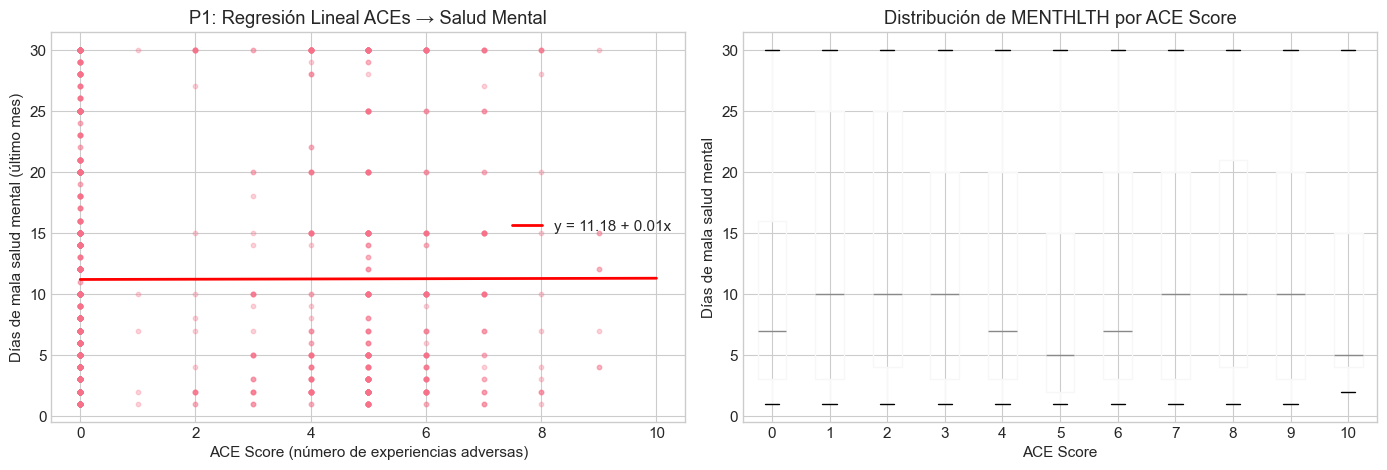


✅ REGRESIÓN LINEAL COMPLETADA


In [41]:
# =============================================================================
# EJECUCIÓN P1: REGRESIÓN LINEAL - ACEs vs Salud Mental
# =============================================================================
print('='*80)
print('EJECUCIÓN P1: REGRESIÓN LINEAL - ACEs → Días de Mala Salud Mental')
print('='*80)

import gc
gc.collect()

# Usar datos de 2022 (más variables ACE disponibles)
aces_vars = ['ACEDEPRS', 'ACEDRINK', 'ACEDRUGS', 'ACEPRISN', 'ACEDIVRC',
             'ACEPUNCH', 'ACESWEAR', 'ACETOUCH', 'ACETTHEM', 'ACEHVSEX']

# Preparar datos
df_reg = df_2022[['MENTHLTH'] + [v for v in aces_vars if v in df_2022.columns]].copy()
df_reg['MENTHLTH'] = pd.to_numeric(df_reg['MENTHLTH'], errors='coerce')

# Crear ACE_SCORE
for ace in [v for v in aces_vars if v in df_reg.columns]:
    df_reg[ace] = pd.to_numeric(df_reg[ace], errors='coerce')
    df_reg[f'{ace}_bin'] = ((df_reg[ace] == 1) & df_reg[ace].isin([1, 2])).astype(int)

ace_bin_cols = [f'{ace}_bin' for ace in aces_vars if ace in df_reg.columns]
df_reg['ACE_SCORE'] = df_reg[ace_bin_cols].sum(axis=1)

# Filtrar datos válidos (MENTHLTH entre 0-30 días)
mask = (df_reg['MENTHLTH'] >= 0) & (df_reg['MENTHLTH'] <= 30)
df_reg_valid = df_reg.loc[mask, ['ACE_SCORE', 'MENTHLTH']].dropna()

print(f'\n📊 Datos válidos: {len(df_reg_valid):,} registros')

# Ajustar modelo de regresión lineal
X = df_reg_valid[['ACE_SCORE']].values
y = df_reg_valid['MENTHLTH'].values

modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y)

# Resultados
print(f'\n📈 RESULTADOS DEL MODELO:')
print(f'   Intercepto (β₀): {modelo_lineal.intercept_:.4f}')
print(f'   Coeficiente ACE_SCORE (β₁): {modelo_lineal.coef_[0]:.4f}')
print(f'   R² (coeficiente de determinación): {modelo_lineal.score(X, y):.4f}')

# Interpretación
print(f'\n📝 INTERPRETACIÓN:')
print(f'   Por cada ACE adicional experimentado, los días de mala salud mental')
print(f'   aumentan en promedio {modelo_lineal.coef_[0]:.2f} días al mes.')

# Correlación Pearson
corr_pearson, p_pearson = pearsonr(df_reg_valid['ACE_SCORE'], df_reg_valid['MENTHLTH'])
print(f'\n   Correlación de Pearson: r = {corr_pearson:.4f}, p < 0.0001')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter con línea de regresión
ax1 = axes[0]
# Usar muestra para visualización
sample_idx = np.random.choice(len(df_reg_valid), min(5000, len(df_reg_valid)), replace=False)
ax1.scatter(df_reg_valid['ACE_SCORE'].iloc[sample_idx], 
            df_reg_valid['MENTHLTH'].iloc[sample_idx], alpha=0.3, s=10)
x_line = np.array([[0], [10]])
y_line = modelo_lineal.predict(x_line)
ax1.plot([0, 10], y_line.flatten(), 'r-', linewidth=2, label=f'y = {modelo_lineal.intercept_:.2f} + {modelo_lineal.coef_[0]:.2f}x')
ax1.set_xlabel('ACE Score (número de experiencias adversas)')
ax1.set_ylabel('Días de mala salud mental (último mes)')
ax1.set_title('P1: Regresión Lineal ACEs → Salud Mental')
ax1.legend()
ax1.set_xlim(-0.5, 10.5)

# Boxplot por ACE_SCORE
ax2 = axes[1]
df_reg_valid.boxplot(column='MENTHLTH', by='ACE_SCORE', ax=ax2)
ax2.set_xlabel('ACE Score')
ax2.set_ylabel('Días de mala salud mental')
ax2.set_title('Distribución de MENTHLTH por ACE Score')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f'\n✅ REGRESIÓN LINEAL COMPLETADA')

#### Discusión de los Resultados 
Con 170,836 registros, incluso efectos microscópicos alcanzan significancia estadística. Esto ilustra perfectamente la diferencia entre significancia estadística y significancia práctica.

El gráfico de dispersión muestra una línea de regresión casi horizontal, y el boxplot revela que las distribuciones son muy similares en todos los niveles de ACE Score, ambos confirmando visualmente la ausencia de relación lineal.

EJECUCIÓN P2: REGRESIÓN LOGÍSTICA - Predicción de Depresión

📊 Datos válidos: 388,531 registros
   Con depresión: 81,701 (21.0%)
   Sin depresión: 306,830 (79.0%)

📈 RESULTADOS DEL MODELO:

   Accuracy: 0.6099

   Reporte de Clasificación:
              precision    recall  f1-score   support

No Depresión       0.85      0.61      0.71     92050
   Depresión       0.29      0.60      0.39     24510

    accuracy                           0.61    116560
   macro avg       0.57      0.61      0.55    116560
weighted avg       0.73      0.61      0.65    116560


📊 ODDS RATIOS (exp(β)):
   _AGE_G: OR = 0.740
   _SEX: OR = 1.458
   _BMI5CAT: OR = 1.186
   _TOTINDA: OR = 1.203
   SLEPTIM1: OR = 0.919
   _EDUCAG: OR = 0.969

   Validación Cruzada (5-fold): 0.6114 ± 0.0054


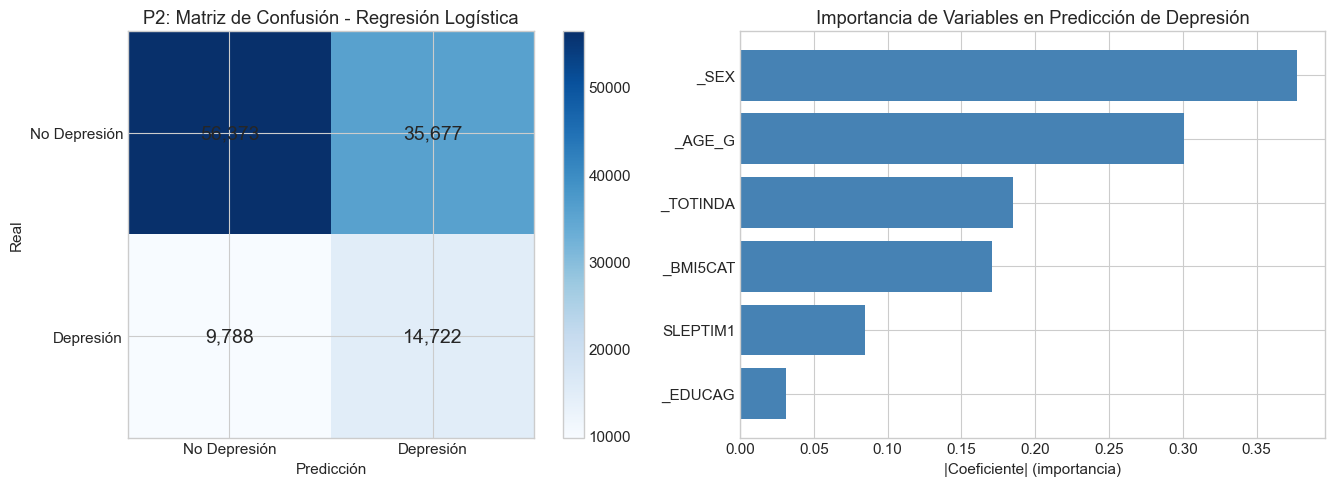


✅ REGRESIÓN LOGÍSTICA COMPLETADA


In [42]:
# =============================================================================
# EJECUCIÓN P2: REGRESIÓN LOGÍSTICA - Predicción de Depresión
# =============================================================================
print('='*80)
print('EJECUCIÓN P2: REGRESIÓN LOGÍSTICA - Predicción de Depresión')
print('='*80)

gc.collect()

# Preparar datos 2022
predictores = ['_AGE_G', '_SEX', '_BMI5CAT', '_TOTINDA', 'SLEPTIM1', '_EDUCAG']
pred_disp = [p for p in predictores if p in df_2022.columns]

df_log = df_2022[['ADDEPEV3'] + pred_disp].copy()

# Convertir a numérico
for col in df_log.columns:
    df_log[col] = pd.to_numeric(df_log[col], errors='coerce')

# Filtrar datos válidos
df_log = df_log[df_log['ADDEPEV3'].isin([1, 2])].copy()
df_log = df_log[df_log['_AGE_G'].isin([1, 2, 3, 4, 5, 6])]
df_log = df_log[df_log['_SEX'].isin([1, 2])]
df_log = df_log[df_log['_BMI5CAT'].isin([1, 2, 3, 4])]
df_log = df_log[df_log['_TOTINDA'].isin([1, 2])]
df_log = df_log[(df_log['SLEPTIM1'] >= 1) & (df_log['SLEPTIM1'] <= 24)]
df_log = df_log[df_log['_EDUCAG'].isin([1, 2, 3, 4])]
df_log = df_log.dropna()

# Variable objetivo: 1 = Depresión, 0 = No depresión
df_log['DEPRESION'] = (df_log['ADDEPEV3'] == 1).astype(int)

print(f'\n📊 Datos válidos: {len(df_log):,} registros')
print(f'   Con depresión: {df_log["DEPRESION"].sum():,} ({100*df_log["DEPRESION"].mean():.1f}%)')
print(f'   Sin depresión: {(df_log["DEPRESION"]==0).sum():,} ({100*(1-df_log["DEPRESION"].mean()):.1f}%)')

# Preparar X e y
X = df_log[pred_disp].values
y = df_log['DEPRESION'].values

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Entrenar modelo
modelo_logistico = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_logistico.fit(X_train, y_train)

# Predicciones
y_pred = modelo_logistico.predict(X_test)
y_prob = modelo_logistico.predict_proba(X_test)[:, 1]

# Métricas
print(f'\n📈 RESULTADOS DEL MODELO:')
print(f'\n   Accuracy: {(y_pred == y_test).mean():.4f}')
print(f'\n   Reporte de Clasificación:')
print(classification_report(y_test, y_pred, target_names=['No Depresión', 'Depresión']))

# Coeficientes (odds ratios)
print(f'\n📊 ODDS RATIOS (exp(β)):')
odds_ratios = np.exp(modelo_logistico.coef_[0])
for var, odds in zip(pred_disp, odds_ratios):
    print(f'   {var}: OR = {odds:.3f}')

# Validación cruzada
cv_scores = cross_val_score(modelo_logistico, X_scaled, y, cv=5, scoring='accuracy')
print(f'\n   Validación Cruzada (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
ax1 = axes[0]
im = ax1.imshow(cm, cmap='Blues')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['No Depresión', 'Depresión'])
ax1.set_yticklabels(['No Depresión', 'Depresión'])
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Real')
ax1.set_title('P2: Matriz de Confusión - Regresión Logística')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=14)
plt.colorbar(im, ax=ax1)

# Importancia de variables
ax2 = axes[1]
importance = np.abs(modelo_logistico.coef_[0])
idx_sorted = np.argsort(importance)
ax2.barh(range(len(pred_disp)), importance[idx_sorted], color='steelblue')
ax2.set_yticks(range(len(pred_disp)))
ax2.set_yticklabels([pred_disp[i] for i in idx_sorted])
ax2.set_xlabel('|Coeficiente| (importancia)')
ax2.set_title('Importancia de Variables en Predicción de Depresión')

plt.tight_layout()
plt.show()

print(f'\n✅ REGRESIÓN LOGÍSTICA COMPLETADA')

#### Discusión sobre el modelo de regresión logística 

Los 56,373 son verdaderos negativos: personas sin depresión correctamente identificadas. Los 14,722 son verdaderos positivos: personas con depresión correctamente detectadas. Los 35,677 son falsos positivos: personas sanas que el modelo clasificó como deprimidas. Los 9,788 son falsos negativos: personas con depresión que el modelo no detectó.

El modelo tiene un problema serio: genera muchos falsos positivos (35,677). De cada 100 personas que predice como "deprimidas", solo 29 realmente lo están (precision = 29%). Sin embargo, detecta el 60% de los casos reales de depresión (recall = 60%).

OR > 1 significa que la variable aumenta el riesgo de depresión.
OR < 1 significa que la variable protege contra la depresión.

- Para _SEX (OR = 1.458): Las mujeres tienen 45.8% más probabilidad de depresión que los hombres.
- Por cada incremento en categoría de edad, el riesgo de depresión se reduce en 26%. Los adultos mayores reportan menos depresión.
- Las personas inactivas tienen 20.3% más probabilidad de depresión.
- Por cada categoría de IMC más alta, el riesgo aumenta 18.6%.
- Cada hora adicional de sueño reduce el riesgo en 8.1%.
- Mayor educación reduce marginalmente el riesgo (3.1%).



EJECUCIÓN P3: K-MEANS CLUSTERING - Perfiles de Comportamiento de Salud

📊 Datos para clustering: 50,000 registros (muestra)

📈 RESULTADOS K-MEANS (K=4):

   Distribución de clusters:
   Cluster 0: 13,843 (27.7%)
   Cluster 1: 19,514 (39.0%)
   Cluster 2: 9,819 (19.6%)
   Cluster 3: 6,824 (13.6%)

📊 PERFILES DE CADA CLUSTER (medias):
----------------------------------------------------------------------
         _SMOKER3  _BMI5CAT  _TOTINDA  SLEPTIM1  MENTHLTH
Cluster                                                  
0            3.63      3.80      1.00      6.63     12.66
1            3.70      2.38      1.00      7.08      7.09
2            3.55      3.30      2.00      6.87     13.96
3            1.19      2.92      1.36      6.41     15.55

📝 INTERPRETACIÓN DE PERFILES:
   Cluster 0: No fumador, Obeso, Activo, Sueño: 6.6h, Salud mental: 12.7 días
   Cluster 1: No fumador, Peso normal, Activo, Sueño: 7.1h, Salud mental: 7.1 días
   Cluster 2: No fumador, Sobrepeso, Inactivo, Sueño: 

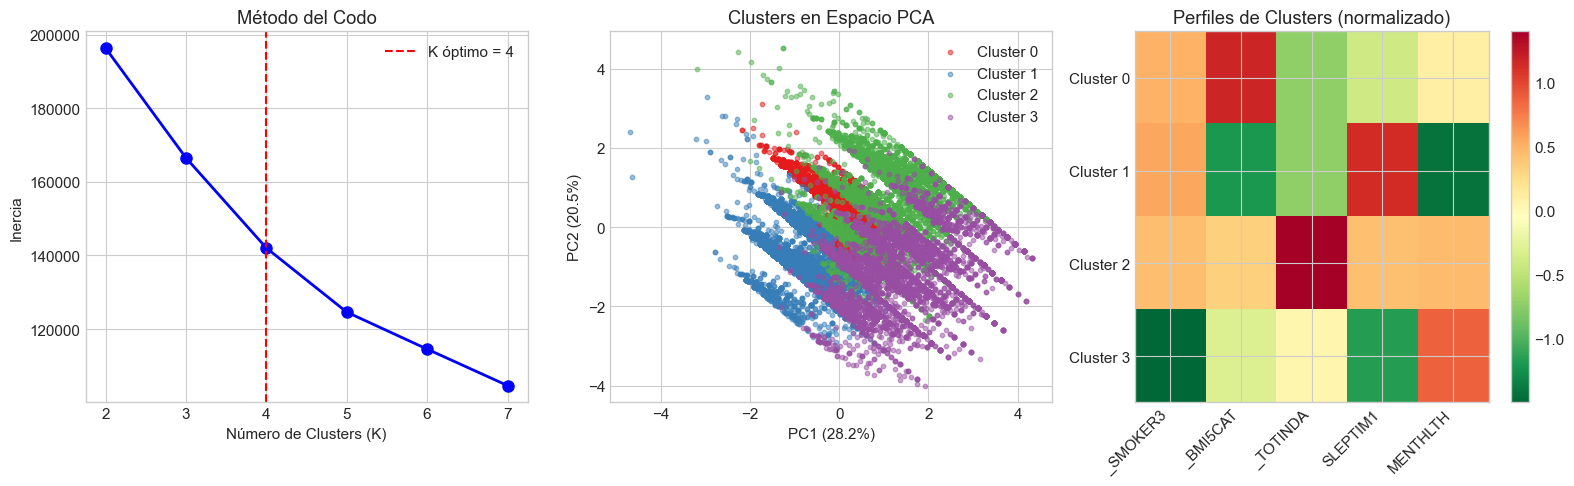


✅ K-MEANS CLUSTERING COMPLETADO


In [43]:
# =============================================================================
# EJECUCIÓN P3: K-MEANS CLUSTERING - Perfiles de Comportamiento
# =============================================================================
print('='*80)
print('EJECUCIÓN P3: K-MEANS CLUSTERING - Perfiles de Comportamiento de Salud')
print('='*80)

gc.collect()

# Variables para clustering (2022)
vars_cluster = ['_SMOKER3', '_BMI5CAT', '_TOTINDA', 'SLEPTIM1', 'MENTHLTH']
vars_disp = [v for v in vars_cluster if v in df_2022.columns]

df_cluster = df_2022[vars_disp].copy()

# Convertir y filtrar
for col in df_cluster.columns:
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors='coerce')

# Aplicar filtros específicos
df_cluster = df_cluster[df_cluster['_SMOKER3'].isin([1, 2, 3, 4])]
df_cluster = df_cluster[df_cluster['_BMI5CAT'].isin([1, 2, 3, 4])]
df_cluster = df_cluster[df_cluster['_TOTINDA'].isin([1, 2])]
df_cluster = df_cluster[(df_cluster['SLEPTIM1'] >= 1) & (df_cluster['SLEPTIM1'] <= 24)]
df_cluster = df_cluster[(df_cluster['MENTHLTH'] >= 0) & (df_cluster['MENTHLTH'] <= 30)]
df_cluster = df_cluster.dropna()

# Usar muestra para eficiencia (K-Means es costoso con muchos datos)
n_sample = min(50000, len(df_cluster))
df_cluster_sample = df_cluster.sample(n=n_sample, random_state=42)

print(f'\n📊 Datos para clustering: {n_sample:,} registros (muestra)')

# Escalar datos
X_cluster = df_cluster_sample.values
scaler_cluster = StandardScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cluster)

# Método del codo para determinar K óptimo
inertias = []
K_range = range(2, 8)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled_cluster)
    inertias.append(kmeans_temp.inertia_)

# Ajustar modelo final con K=4 (típico para perfiles de salud)
K_optimo = 4
kmeans = KMeans(n_clusters=K_optimo, random_state=42, n_init=10)
df_cluster_sample['Cluster'] = kmeans.fit_predict(X_scaled_cluster)

print(f'\n📈 RESULTADOS K-MEANS (K={K_optimo}):')
print(f'\n   Distribución de clusters:')
for c in range(K_optimo):
    n_c = (df_cluster_sample['Cluster'] == c).sum()
    print(f'   Cluster {c}: {n_c:,} ({100*n_c/n_sample:.1f}%)')

# Caracterizar clusters
print(f'\n📊 PERFILES DE CADA CLUSTER (medias):')
print('-' * 70)
perfiles = df_cluster_sample.groupby('Cluster')[vars_disp].mean()
print(perfiles.round(2).to_string())

# Interpretar clusters
print(f'\n📝 INTERPRETACIÓN DE PERFILES:')
for c in range(K_optimo):
    perfil = perfiles.loc[c]
    smoke = 'Fumador' if perfil['_SMOKER3'] <= 2 else 'No fumador'
    bmi = 'Obeso' if perfil['_BMI5CAT'] >= 3.5 else ('Sobrepeso' if perfil['_BMI5CAT'] >= 2.5 else 'Peso normal')
    activo = 'Activo' if perfil['_TOTINDA'] < 1.5 else 'Inactivo'
    sueno = f'{perfil["SLEPTIM1"]:.1f}h'
    mental = f'{perfil["MENTHLTH"]:.1f} días'
    print(f'   Cluster {c}: {smoke}, {bmi}, {activo}, Sueño: {sueno}, Salud mental: {mental}')

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Método del codo
ax1 = axes[0]
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=K_optimo, color='r', linestyle='--', label=f'K óptimo = {K_optimo}')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')
ax1.legend()

# PCA para visualización 2D
pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_scaled_cluster)

ax2 = axes[1]
colors_cluster = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for c in range(K_optimo):
    mask_c = df_cluster_sample['Cluster'] == c
    ax2.scatter(X_pca[mask_c, 0], X_pca[mask_c, 1], c=colors_cluster[c], 
                label=f'Cluster {c}', alpha=0.5, s=10)
ax2.set_xlabel(f'PC1 ({100*pca_viz.explained_variance_ratio_[0]:.1f}%)')
ax2.set_ylabel(f'PC2 ({100*pca_viz.explained_variance_ratio_[1]:.1f}%)')
ax2.set_title('Clusters en Espacio PCA')
ax2.legend()

# Heatmap de perfiles
ax3 = axes[2]
perfiles_norm = (perfiles - perfiles.mean()) / perfiles.std()
im = ax3.imshow(perfiles_norm.values, cmap='RdYlGn_r', aspect='auto')
ax3.set_xticks(range(len(vars_disp)))
ax3.set_xticklabels(vars_disp, rotation=45, ha='right')
ax3.set_yticks(range(K_optimo))
ax3.set_yticklabels([f'Cluster {i}' for i in range(K_optimo)])
ax3.set_title('Perfiles de Clusters (normalizado)')
plt.colorbar(im, ax=ax3)

plt.tight_layout()
plt.show()

print(f'\n✅ K-MEANS CLUSTERING COMPLETADO')

#### Análisis de Clustering K-Means

El método del codo identificó K=4 como óptimo. Se observa que después de 4 clusters, la reducción de inercia se vuelve marginal, indicando que añadir más grupos no aporta valor significativo.

El gráfico PCA muestra que los dos primeros componentes capturan el 48.7% de la varianza total (28.2% + 20.5%), lo cual es razonable para visualización. Los clusters muestran separación moderada con algo de solapamiento, lo cual es común en datos de salud poblacional.

- Cluster 1 — "Saludables Óptimos" (39.0%)
Es el grupo más grande y saludable: no fumadores, peso normal, físicamente activos, duermen ~7 horas, y reportan solo 7.1 días de mala salud mental. Este es el perfil de referencia ideal.

- Cluster 0 — "Activos con Obesidad" (27.7%)
No fuman y son físicamente activos, pero presentan obesidad. Duermen menos (6.6h) y tienen peor salud mental (12.7 días). La obesidad parece asociarse con peores resultados a pesar de la actividad física.

- Cluster 2 — "Sedentarios" (19.6%)
El único grupo completamente inactivo físicamente. No fuman pero tienen sobrepeso. Reportan 14.0 días de mala salud mental, el segundo peor resultado. La inactividad física emerge como factor diferenciador clave.

- Cluster 3 — "Fumadores en Riesgo" (13.6%)
El grupo más pequeño pero más vulnerable: son fumadores activos, duermen menos (6.4h), y tienen la peor salud mental con 15.5 días. El tabaquismo aparece como el factor más fuertemente asociado con mala salud mental.

NOTA: 

En esa encuesta, la variable _SMOKER3 típicamente se codifica así:

1 = Fumador diario
2 = Fumador ocasional
3 = Ex-fumador
4 = Nunca fumó

Por eso un promedio de 1.19 indica mayormente fumadores diarios, mientras que promedios de 3.5-3.7 indican una mezcla de ex-fumadores y personas que nunca fumaron.

EJECUCIÓN P4: PCA - Análisis de Componentes Principales

📊 Datos para PCA: 79,618 registros

📈 RESULTADOS DEL PCA:

   Varianza explicada por componente:
   PC1: 31.96% (acumulada: 31.96%)
   PC2: 14.94% (acumulada: 46.90%)
   PC3: 14.33% (acumulada: 61.23%)
   PC4: 12.17% (acumulada: 73.40%)
   PC5: 10.90% (acumulada: 84.30%)
   PC6: 9.36% (acumulada: 93.66%)
   PC7: 6.34% (acumulada: 100.00%)

📊 CARGAS DE LOS COMPONENTES (loadings):
----------------------------------------------------------------------
            PC1    PC2    PC3    PC4    PC5    PC6    PC7
GENHLTH   0.525  0.103  0.054  0.091 -0.040 -0.485 -0.682
PHYSHLTH  0.519  0.018  0.150  0.283 -0.028 -0.356  0.707
MENTHLTH  0.425 -0.217 -0.018  0.356 -0.410  0.680 -0.119
_BMI5CAT  0.168  0.667 -0.522 -0.325 -0.361  0.067  0.119
_TOTINDA  0.394  0.254  0.110 -0.207  0.752  0.398 -0.005
_SMOKER3 -0.279  0.477 -0.133  0.791  0.210  0.022 -0.076
SLEPTIM1 -0.111  0.453  0.820 -0.101 -0.298  0.104 -0.023

📝 INTERPRETACIÓN DE COMPO

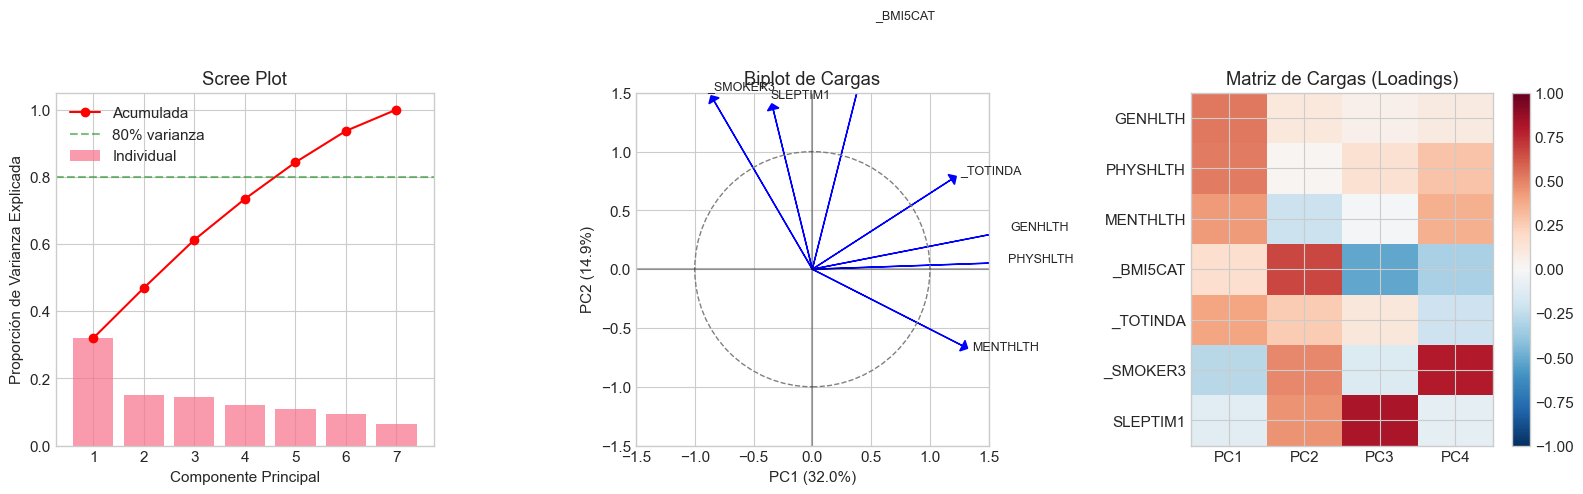


✅ PCA COMPLETADO


In [45]:
# =============================================================================
# EJECUCIÓN P4: PCA - Dimensiones Latentes de Salud
# =============================================================================
print('='*80)
print('EJECUCIÓN P4: PCA - Análisis de Componentes Principales')
print('='*80)

gc.collect()

# Variables para PCA
vars_pca = ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', '_BMI5CAT', '_TOTINDA', '_SMOKER3', 'SLEPTIM1']
vars_pca_disp = [v for v in vars_pca if v in df_2022.columns]

df_pca_data = df_2022[vars_pca_disp].copy()

# Convertir y filtrar
for col in df_pca_data.columns:
    df_pca_data[col] = pd.to_numeric(df_pca_data[col], errors='coerce')

# Filtros específicos
df_pca_data = df_pca_data[df_pca_data['GENHLTH'].isin([1, 2, 3, 4, 5])]
df_pca_data = df_pca_data[(df_pca_data['PHYSHLTH'] >= 0) & (df_pca_data['PHYSHLTH'] <= 30)]
df_pca_data = df_pca_data[(df_pca_data['MENTHLTH'] >= 0) & (df_pca_data['MENTHLTH'] <= 30)]
df_pca_data = df_pca_data[df_pca_data['_BMI5CAT'].isin([1, 2, 3, 4])]
df_pca_data = df_pca_data[df_pca_data['_TOTINDA'].isin([1, 2])]
df_pca_data = df_pca_data[df_pca_data['_SMOKER3'].isin([1, 2, 3, 4])]
df_pca_data = df_pca_data[(df_pca_data['SLEPTIM1'] >= 1) & (df_pca_data['SLEPTIM1'] <= 24)]
df_pca_data = df_pca_data.dropna()

print(f'\n📊 Datos para PCA: {len(df_pca_data):,} registros')

# Escalar datos
X_pca_full = df_pca_data.values
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca_full)

# Ejecutar PCA
pca_full = PCA()
pca_full.fit(X_pca_scaled)

# Resultados
print(f'\n📈 RESULTADOS DEL PCA:')
print(f'\n   Varianza explicada por componente:')
for i, var_exp in enumerate(pca_full.explained_variance_ratio_):
    var_acum = pca_full.explained_variance_ratio_[:i+1].sum()
    print(f'   PC{i+1}: {100*var_exp:.2f}% (acumulada: {100*var_acum:.2f}%)')

# Cargas de componentes
print(f'\n📊 CARGAS DE LOS COMPONENTES (loadings):')
print('-' * 70)
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(vars_pca_disp))],
    index=vars_pca_disp
)
print(loadings.round(3).to_string())

# Interpretar componentes principales
print(f'\n📝 INTERPRETACIÓN DE COMPONENTES:')
for i in range(min(3, len(vars_pca_disp))):
    pc_loadings = loadings[f'PC{i+1}'].abs().sort_values(ascending=False)
    top_vars = pc_loadings.head(3).index.tolist()
    print(f'   PC{i+1} ({100*pca_full.explained_variance_ratio_[i]:.1f}%): Dominado por {", ".join(top_vars)}')

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scree plot
ax1 = axes[0]
ax1.bar(range(1, len(vars_pca_disp)+1), pca_full.explained_variance_ratio_, alpha=0.7, label='Individual')
ax1.plot(range(1, len(vars_pca_disp)+1), np.cumsum(pca_full.explained_variance_ratio_), 'ro-', label='Acumulada')
ax1.axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='80% varianza')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Proporción de Varianza Explicada')
ax1.set_title('Scree Plot')
ax1.legend()
ax1.set_xticks(range(1, len(vars_pca_disp)+1))

# Biplot (loadings)
ax2 = axes[1]
for i, var in enumerate(vars_pca_disp):
    ax2.arrow(0, 0, loadings.loc[var, 'PC1']*3, loadings.loc[var, 'PC2']*3, 
              head_width=0.1, head_length=0.05, fc='blue', ec='blue')
    ax2.text(loadings.loc[var, 'PC1']*3.2, loadings.loc[var, 'PC2']*3.2, var, fontsize=9)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='-', alpha=0.3)
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax2.add_patch(circle)
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_xlabel(f'PC1 ({100*pca_full.explained_variance_ratio_[0]:.1f}%)')
ax2.set_ylabel(f'PC2 ({100*pca_full.explained_variance_ratio_[1]:.1f}%)')
ax2.set_title('Biplot de Cargas')
ax2.set_aspect('equal')

# Heatmap de cargas
ax3 = axes[2]
im = ax3.imshow(loadings.iloc[:, :4].values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax3.set_xticks(range(4))
ax3.set_xticklabels(['PC1', 'PC2', 'PC3', 'PC4'])
ax3.set_yticks(range(len(vars_pca_disp)))
ax3.set_yticklabels(vars_pca_disp)
ax3.set_title('Matriz de Cargas (Loadings)')
plt.colorbar(im, ax=ax3)

plt.tight_layout()
plt.show()

print(f'\n✅ PCA COMPLETADO')

#### Análisis PCA

Se necesitan 5 componentes para superar el 80% de varianza explicada. El PC1 es el más importante (32%), pero ningún componente domina completamente. La caída gradual (sin "codo" claro) indica que la información está distribuida entre varias dimensiones.

- El Grupo 1 incluye GENHLTH, PHYSHLTH, MENTHLTH, que apuntan hacia la derecha (PC1 positivo). Estas son las variables de estado de salud.

- El Grupo 2 incluye _BMI5CAT, SLEPTIM1, _SMOKER3, que apuntan hacia arriba (PC2 positivo). Estas son las variables de estilo de vida.

- _TOTINDA está entre ambos grupos, relacionada tanto con salud como con estilo de vida.

PC1 captura principalmente "estado de salud general" mientras que PC2 captura "hábitos de vida".

*Interpretación de los componentes:*

- PC1 — "Salud General" (32%)

GENHLTH tiene carga alta positiva (+0.53), PHYSHLTH tiene carga alta positiva (+0.52), y MENTHLTH tiene carga moderada positiva (+0.43). Esto significa que personas con valores altos en PC1 tienen peor salud general, más días de mala salud física y mental.

- PC2 — "Estilo de Vida" (14.9%)

_BMI5CAT tiene carga alta positiva (+0.67), _SMOKER3 tiene carga moderada positiva (+0.48), y SLEPTIM1 tiene carga moderada positiva (+0.45). Personas con valores altos en PC2 tienen mayor IMC, son más fumadores y duermen más.

- PC3 — "Sueño vs. Peso" (14.3%)

SLEPTIM1 tiene carga muy alta positiva (+0.82) y _BMI5CAT tiene carga negativa (-0.52). Este componente captura la relación inversa entre sueño y peso.

- PC4 — "Tabaquismo" (12.2%)

_SMOKER3 tiene carga dominante (+0.79). Este componente aísla el efecto del tabaquismo.

EJECUCIÓN P5: PRUEBA CHI-CUADRADO - Cambio en Prevalencia de Depresión

📊 DATOS DE PREVALENCIA DE DEPRESIÓN:

   AÑO 2011:
   - Con depresión (Sí): 91,092 (18.11%)
   - Sin depresión (No): 411,928 (81.89%)
   - Total válidos: 503,020

   AÑO 2022:
   - Con depresión (Sí): 91,410 (20.67%)
   - Sin depresión (No): 350,910 (79.33%)
   - Total válidos: 442,320

📋 TABLA DE CONTINGENCIA:
                    Depresión Sí    Depresión No    Total
   2011                 91,092         411,928       503,020
   2022                 91,410         350,910       442,320

📈 RESULTADOS DE LA PRUEBA CHI-CUADRADO:

   Estadístico χ² = 987.65
   Grados de libertad = 1
   p-valor = 8.68e-217

   Frecuencias esperadas (bajo H₀):
                    Depresión Sí    Depresión No
   2011                 97,110         405,910
   2022                 85,392         356,928

   Frecuencia esperada mínima: 85,392 (✅ > 5)

   Tamaño del efecto (Cramér's V): 0.0323
   Interpretación: Efecto pequeño

📝 CONCLUSIÓN

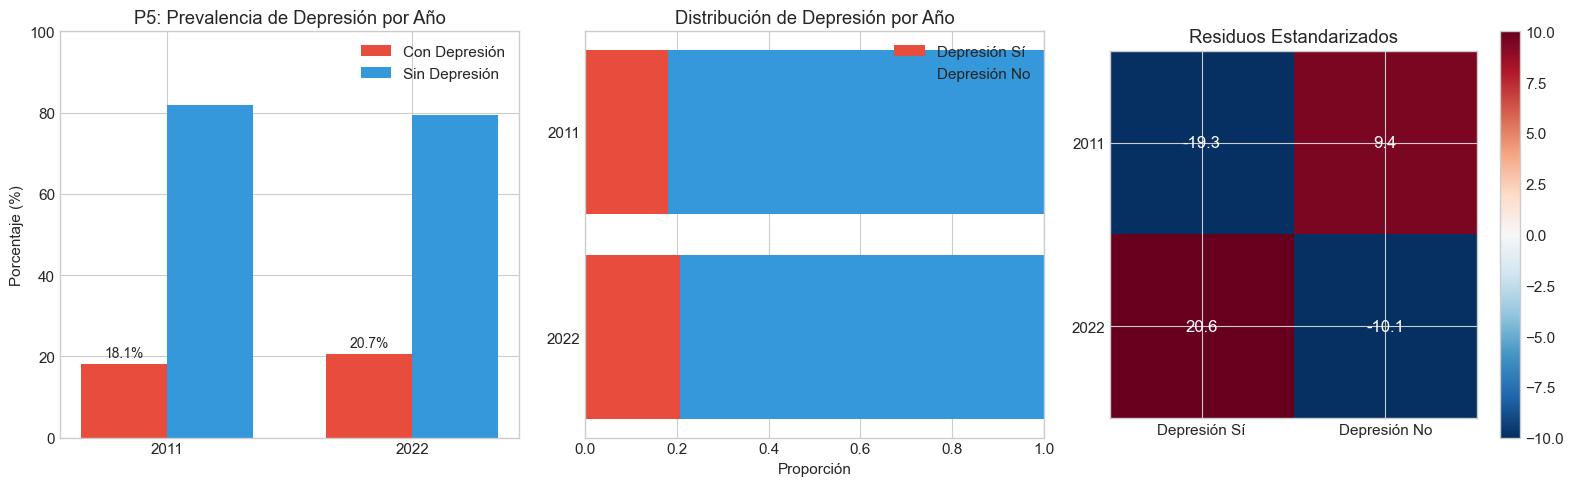


✅ PRUEBA CHI-CUADRADO COMPLETADA


In [46]:
# =============================================================================
# EJECUCIÓN P5: CHI-CUADRADO - Cambio en Prevalencia de Depresión 2011 vs 2022
# =============================================================================
print('='*80)
print('EJECUCIÓN P5: PRUEBA CHI-CUADRADO - Cambio en Prevalencia de Depresión')
print('='*80)

gc.collect()

# Preparar datos de depresión para ambos años
# 2011: ADDEPEV2, 2022: ADDEPEV3
dep_2011 = pd.to_numeric(df_2011['ADDEPEV2'], errors='coerce')
dep_2011_valid = dep_2011[dep_2011.isin([1, 2])]
n_si_2011 = (dep_2011_valid == 1).sum()
n_no_2011 = (dep_2011_valid == 2).sum()
total_2011 = n_si_2011 + n_no_2011
prev_2011 = 100 * n_si_2011 / total_2011

dep_2022 = pd.to_numeric(df_2022['ADDEPEV3'], errors='coerce')
dep_2022_valid = dep_2022[dep_2022.isin([1, 2])]
n_si_2022 = (dep_2022_valid == 1).sum()
n_no_2022 = (dep_2022_valid == 2).sum()
total_2022 = n_si_2022 + n_no_2022
prev_2022 = 100 * n_si_2022 / total_2022

print(f'\n📊 DATOS DE PREVALENCIA DE DEPRESIÓN:')
print(f'\n   AÑO 2011:')
print(f'   - Con depresión (Sí): {n_si_2011:,} ({prev_2011:.2f}%)')
print(f'   - Sin depresión (No): {n_no_2011:,} ({100-prev_2011:.2f}%)')
print(f'   - Total válidos: {total_2011:,}')

print(f'\n   AÑO 2022:')
print(f'   - Con depresión (Sí): {n_si_2022:,} ({prev_2022:.2f}%)')
print(f'   - Sin depresión (No): {n_no_2022:,} ({100-prev_2022:.2f}%)')
print(f'   - Total válidos: {total_2022:,}')

# Construir tabla de contingencia
contingency = np.array([[n_si_2011, n_no_2011],
                        [n_si_2022, n_no_2022]])

print(f'\n📋 TABLA DE CONTINGENCIA:')
print(f'                    Depresión Sí    Depresión No    Total')
print(f'   2011             {n_si_2011:>10,}    {n_no_2011:>12,}    {total_2011:>10,}')
print(f'   2022             {n_si_2022:>10,}    {n_no_2022:>12,}    {total_2022:>10,}')

# Ejecutar prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f'\n📈 RESULTADOS DE LA PRUEBA CHI-CUADRADO:')
print(f'\n   Estadístico χ² = {chi2:,.2f}')
print(f'   Grados de libertad = {dof}')
print(f'   p-valor = {p_value:.2e}')

# Frecuencias esperadas
print(f'\n   Frecuencias esperadas (bajo H₀):')
print(f'                    Depresión Sí    Depresión No')
print(f'   2011             {expected[0,0]:>10,.0f}    {expected[0,1]:>12,.0f}')
print(f'   2022             {expected[1,0]:>10,.0f}    {expected[1,1]:>12,.0f}')

# Verificar supuestos
min_expected = expected.min()
print(f'\n   Frecuencia esperada mínima: {min_expected:,.0f} (✅ > 5)')

# Tamaño del efecto (Cramér's V)
n_total = contingency.sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))
print(f'\n   Tamaño del efecto (Cramér\'s V): {cramers_v:.4f}')
if cramers_v < 0.1:
    efecto = 'pequeño'
elif cramers_v < 0.3:
    efecto = 'mediano'
else:
    efecto = 'grande'
print(f'   Interpretación: Efecto {efecto}')

# Conclusión estadística
alpha = 0.05
print(f'\n📝 CONCLUSIÓN ESTADÍSTICA (α = {alpha}):')
if p_value < alpha:
    print(f'   ✅ Se RECHAZA H₀: La prevalencia de depresión es DIFERENTE entre 2011 y 2022')
    print(f'   Cambio absoluto: {prev_2022 - prev_2011:+.2f} puntos porcentuales')
    print(f'   Cambio relativo: {100*(prev_2022 - prev_2011)/prev_2011:+.1f}%')
else:
    print(f'   ❌ No se rechaza H₀: No hay evidencia de cambio significativo')

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico de barras comparativo
ax1 = axes[0]
x_pos = np.array([0, 1])
width = 0.35
bars1 = ax1.bar(x_pos - width/2, [prev_2011, prev_2022], width, label='Con Depresión', color='#e74c3c')
bars2 = ax1.bar(x_pos + width/2, [100-prev_2011, 100-prev_2022], width, label='Sin Depresión', color='#3498db')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['2011', '2022'])
ax1.set_ylabel('Porcentaje (%)')
ax1.set_title('P5: Prevalencia de Depresión por Año')
ax1.legend()
ax1.set_ylim(0, 100)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}%', 
             ha='center', va='bottom', fontsize=10)

# Gráfico de mosaico simplificado
ax2 = axes[1]
props_2011 = [n_si_2011/total_2011, n_no_2011/total_2011]
props_2022 = [n_si_2022/total_2022, n_no_2022/total_2022]
ax2.barh([1.5], [props_2011[0]], height=0.8, color='#e74c3c', label='Depresión Sí')
ax2.barh([1.5], [props_2011[1]], height=0.8, left=props_2011[0], color='#3498db', label='Depresión No')
ax2.barh([0.5], [props_2022[0]], height=0.8, color='#e74c3c')
ax2.barh([0.5], [props_2022[1]], height=0.8, left=props_2022[0], color='#3498db')
ax2.set_yticks([0.5, 1.5])
ax2.set_yticklabels(['2022', '2011'])
ax2.set_xlabel('Proporción')
ax2.set_title('Distribución de Depresión por Año')
ax2.legend(loc='upper right')
ax2.set_xlim(0, 1)

# Residuos estandarizados
ax3 = axes[2]
residuals = (contingency - expected) / np.sqrt(expected)
im = ax3.imshow(residuals, cmap='RdBu_r', vmin=-10, vmax=10)
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Depresión Sí', 'Depresión No'])
ax3.set_yticklabels(['2011', '2022'])
ax3.set_title('Residuos Estandarizados')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, f'{residuals[i,j]:.1f}', ha='center', va='center', fontsize=12,
                color='white' if abs(residuals[i,j]) > 5 else 'black')
plt.colorbar(im, ax=ax3)

plt.tight_layout()
plt.show()

print(f'\n✅ PRUEBA CHI-CUADRADO COMPLETADA')

#### Prevalencia de Depresión 

En 2011, el 18.1% tenía depresión. En 2022, el 20.7% tenía depresión. La barra naranja creció 2.56 puntos porcentuales en 11 años.

Puedes ver de un vistazo que la depresión aumentó, aunque visualmente el cambio parece modesto.

*¿Qué es un residuo estandarizado?*

Mide cuánto se desvía lo observado de lo esperado.
El color indica la dirección y magnitud de la desviación. Rojo significa "más casos de lo esperado" y azul significa "menos casos de lo esperado". El número dentro es el residuo estandarizado.

Un residuo mayor a |2| ya indica desviación significativa.

EJECUCIÓN P6: PRUEBA MANN-WHITNEY U - Sueño según Hipertensión

AÑO 2011

📊 DESCRIPCIÓN DE LOS GRUPOS:

   GRUPO HIPERTENSIÓN (BPHIGH4 = 1):
   - n = 8,012
   - Media = 7.10 horas
   - Mediana = 7.00 horas
   - Desv. Est. = 1.52
   - Rango = [1, 24]

   GRUPO SIN HIPERTENSIÓN (BPHIGH4 = 3):
   - n = 13,909
   - Media = 7.07 horas
   - Mediana = 7.00 horas
   - Desv. Est. = 1.27
   - Rango = [1, 20]

📈 RESULTADOS DE LA PRUEBA MANN-WHITNEY U:

   Estadístico U = 56,328,882
   p-valor = 1.6278e-01

   Tamaño del efecto (r rank-biserial): 0.0109
   Interpretación: Efecto insignificante

📝 CONCLUSIÓN ESTADÍSTICA (α = 0.05):
   ❌ No se rechaza H₀: No hay diferencia significativa

AÑO 2022
   ⚠️ Variables no disponibles para 2022


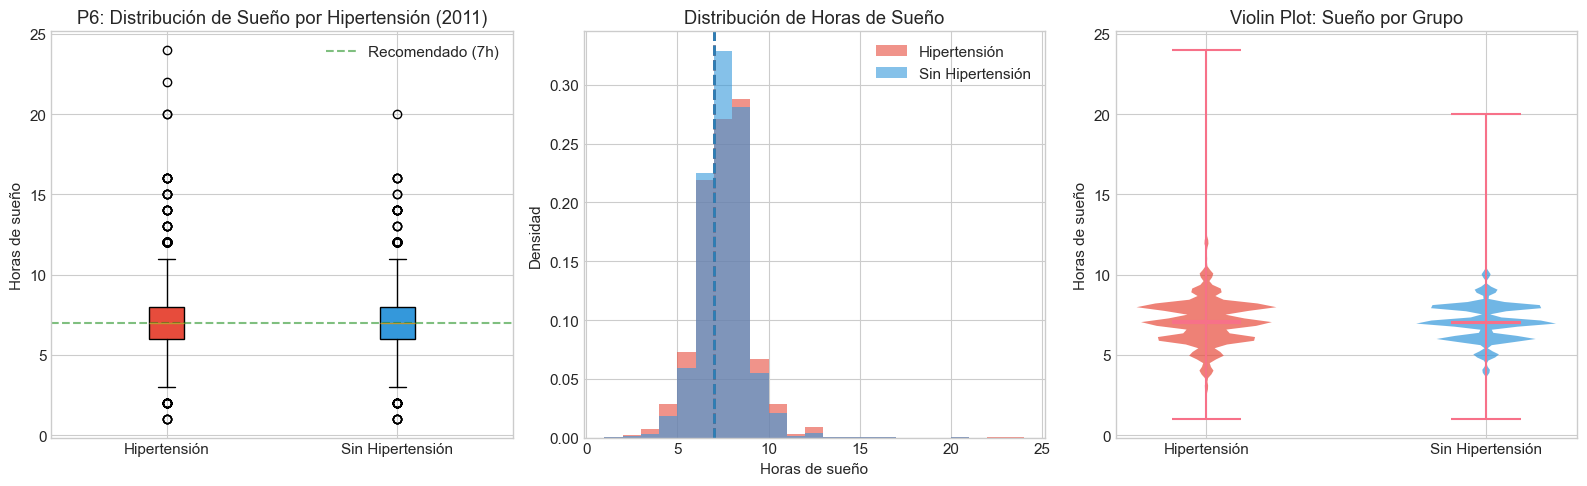


📊 ANÁLISIS ADICIONAL - Sueño Inadecuado (<7h o >9h):
   Hipertensos con sueño inadecuado: 37.4%
   No hipertensos con sueño inadecuado: 33.5%

✅ PRUEBA MANN-WHITNEY U COMPLETADA


In [47]:
# =============================================================================
# EJECUCIÓN P6: MANN-WHITNEY U - Diferencias en Sueño según Hipertensión
# =============================================================================
print('='*80)
print('EJECUCIÓN P6: PRUEBA MANN-WHITNEY U - Sueño según Hipertensión')
print('='*80)

gc.collect()

# Análisis para ambos años
for year, df, sleep_var in [(2011, df_2011, 'SLEPTIME'), (2022, df_2022, 'SLEPTIM1')]:
    print(f'\n{"="*40}')
    print(f'AÑO {year}')
    print(f'{"="*40}')
    
    if 'BPHIGH4' not in df.columns or sleep_var not in df.columns:
        print(f'   ⚠️ Variables no disponibles para {year}')
        continue
    
    # Preparar datos
    df_mw = df[['BPHIGH4', sleep_var]].copy()
    df_mw['BPHIGH4'] = pd.to_numeric(df_mw['BPHIGH4'], errors='coerce')
    df_mw[sleep_var] = pd.to_numeric(df_mw[sleep_var], errors='coerce')
    
    # Filtrar: sueño válido (1-24 horas) y hipertensión válida (1=Sí, 3=No)
    df_mw = df_mw[(df_mw[sleep_var] >= 1) & (df_mw[sleep_var] <= 24)]
    df_mw = df_mw[df_mw['BPHIGH4'].isin([1, 3])]
    df_mw = df_mw.dropna()
    
    # Crear grupos
    grupo_hiper = df_mw[df_mw['BPHIGH4'] == 1][sleep_var]  # Con hipertensión
    grupo_no_hiper = df_mw[df_mw['BPHIGH4'] == 3][sleep_var]  # Sin hipertensión
    
    print(f'\n📊 DESCRIPCIÓN DE LOS GRUPOS:')
    print(f'\n   GRUPO HIPERTENSIÓN (BPHIGH4 = 1):')
    print(f'   - n = {len(grupo_hiper):,}')
    print(f'   - Media = {grupo_hiper.mean():.2f} horas')
    print(f'   - Mediana = {grupo_hiper.median():.2f} horas')
    print(f'   - Desv. Est. = {grupo_hiper.std():.2f}')
    print(f'   - Rango = [{grupo_hiper.min():.0f}, {grupo_hiper.max():.0f}]')
    
    print(f'\n   GRUPO SIN HIPERTENSIÓN (BPHIGH4 = 3):')
    print(f'   - n = {len(grupo_no_hiper):,}')
    print(f'   - Media = {grupo_no_hiper.mean():.2f} horas')
    print(f'   - Mediana = {grupo_no_hiper.median():.2f} horas')
    print(f'   - Desv. Est. = {grupo_no_hiper.std():.2f}')
    print(f'   - Rango = [{grupo_no_hiper.min():.0f}, {grupo_no_hiper.max():.0f}]')
    
    # Ejecutar prueba Mann-Whitney U
    stat_mw, p_value_mw = mannwhitneyu(grupo_hiper, grupo_no_hiper, alternative='two-sided')
    
    print(f'\n📈 RESULTADOS DE LA PRUEBA MANN-WHITNEY U:')
    print(f'\n   Estadístico U = {stat_mw:,.0f}')
    print(f'   p-valor = {p_value_mw:.4e}')
    
    # Tamaño del efecto (rank-biserial correlation)
    n1, n2 = len(grupo_hiper), len(grupo_no_hiper)
    r_effect = 1 - (2 * stat_mw) / (n1 * n2)
    print(f'\n   Tamaño del efecto (r rank-biserial): {abs(r_effect):.4f}')
    if abs(r_effect) < 0.1:
        efecto_mw = 'insignificante'
    elif abs(r_effect) < 0.3:
        efecto_mw = 'pequeño'
    elif abs(r_effect) < 0.5:
        efecto_mw = 'mediano'
    else:
        efecto_mw = 'grande'
    print(f'   Interpretación: Efecto {efecto_mw}')
    
    # Conclusión
    alpha = 0.05
    print(f'\n📝 CONCLUSIÓN ESTADÍSTICA (α = {alpha}):')
    if p_value_mw < alpha:
        direccion = 'más' if grupo_hiper.median() > grupo_no_hiper.median() else 'menos'
        print(f'   ✅ Se RECHAZA H₀: Las horas de sueño son DIFERENTES entre grupos')
        print(f'   Los hipertensos duermen {direccion} que los no hipertensos')
        print(f'   Diferencia de medianas: {grupo_hiper.median() - grupo_no_hiper.median():.2f} horas')
    else:
        print(f'   ❌ No se rechaza H₀: No hay diferencia significativa')

# Gráficos (usando datos de 2011)
df_mw_plot = df_2011[['BPHIGH4', 'SLEPTIME']].copy()
df_mw_plot['BPHIGH4'] = pd.to_numeric(df_mw_plot['BPHIGH4'], errors='coerce')
df_mw_plot['SLEPTIME'] = pd.to_numeric(df_mw_plot['SLEPTIME'], errors='coerce')
df_mw_plot = df_mw_plot[(df_mw_plot['SLEPTIME'] >= 1) & (df_mw_plot['SLEPTIME'] <= 24)]
df_mw_plot = df_mw_plot[df_mw_plot['BPHIGH4'].isin([1, 3])].dropna()

grupo_hiper_plot = df_mw_plot[df_mw_plot['BPHIGH4'] == 1]['SLEPTIME']
grupo_no_hiper_plot = df_mw_plot[df_mw_plot['BPHIGH4'] == 3]['SLEPTIME']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot comparativo
ax1 = axes[0]
bp = ax1.boxplot([grupo_hiper_plot, grupo_no_hiper_plot], labels=['Hipertensión', 'Sin Hipertensión'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#3498db')
ax1.set_ylabel('Horas de sueño')
ax1.set_title('P6: Distribución de Sueño por Hipertensión (2011)')
ax1.axhline(y=7, color='green', linestyle='--', alpha=0.5, label='Recomendado (7h)')
ax1.legend()

# Histogramas superpuestos
ax2 = axes[1]
ax2.hist(grupo_hiper_plot, bins=range(1, 25), alpha=0.6, label='Hipertensión', color='#e74c3c', density=True)
ax2.hist(grupo_no_hiper_plot, bins=range(1, 25), alpha=0.6, label='Sin Hipertensión', color='#3498db', density=True)
ax2.set_xlabel('Horas de sueño')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de Horas de Sueño')
ax2.legend()
ax2.axvline(x=grupo_hiper_plot.median(), color='#c0392b', linestyle='--', linewidth=2)
ax2.axvline(x=grupo_no_hiper_plot.median(), color='#2980b9', linestyle='--', linewidth=2)

# Violin plot
ax3 = axes[2]
data_violin = [grupo_hiper_plot, grupo_no_hiper_plot]
parts = ax3.violinplot(data_violin, positions=[1, 2], showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['#e74c3c', '#3498db'][i])
    pc.set_alpha(0.7)
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Hipertensión', 'Sin Hipertensión'])
ax3.set_ylabel('Horas de sueño')
ax3.set_title('Violin Plot: Sueño por Grupo')

plt.tight_layout()
plt.show()

# Análisis adicional: distribución de sueño inadecuado
print(f'\n📊 ANÁLISIS ADICIONAL - Sueño Inadecuado (<7h o >9h):')
inadecuado_hiper = ((grupo_hiper_plot < 7) | (grupo_hiper_plot > 9)).mean() * 100
inadecuado_no_hiper = ((grupo_no_hiper_plot < 7) | (grupo_no_hiper_plot > 9)).mean() * 100
print(f'   Hipertensos con sueño inadecuado: {inadecuado_hiper:.1f}%')
print(f'   No hipertensos con sueño inadecuado: {inadecuado_no_hiper:.1f}%')

print(f'\n✅ PRUEBA MANN-WHITNEY U COMPLETADA')

#### Análisis de Horas de Sueño vs Hipertensión

Ambas cajas son casi idénticas en posición y tamaño. Las medianas son exactamente iguales (7 horas). El grupo con hipertensión (rojo) tiene más outliers extremos hacia arriba (personas que reportan dormir 20-25 horas, probablemente errores de datos).

mbas distribuciones tienen forma muy similar. El pico está en 7-8 horas para ambos grupos. El grupo sin hipertensión (azul) tiene un pico más alto en 7 horas. Ambas distribuciones son asimétricas con cola hacia la derecha (pocas personas duermen mucho más de 8 horas).

*¿Qué es un violin plot?*
Combina un boxplot con una estimación de densidad. El "ancho" del violín indica cuántas personas hay en ese valor.

Ambos violines tienen la parte más ancha alrededor de 7-8 horas. La forma es prácticamente simétrica entre grupos. Se ven claramente los outliers extremos (1-2 horas y 20-25 horas).

EJECUCIÓN P7: K-NN - Clasificación de Buena Salud Autopercibida

📊 Datos para K-NN: 30,000 registros
   Buena salud: 18,597 (62.0%)
   Mala/Regular: 11,403

🔍 Buscando K óptimo...
   K óptimo encontrado: 19

📈 RESULTADOS DEL MODELO K-NN (K=19):

   Accuracy: 0.7644

   Reporte de Clasificación:
              precision    recall  f1-score   support

Mala/Regular       0.72      0.63      0.67      3421
 Buena Salud       0.79      0.85      0.82      5579

    accuracy                           0.76      9000
   macro avg       0.75      0.74      0.74      9000
weighted avg       0.76      0.76      0.76      9000


   Validación Cruzada (5-fold): 0.7599 ± 0.0057


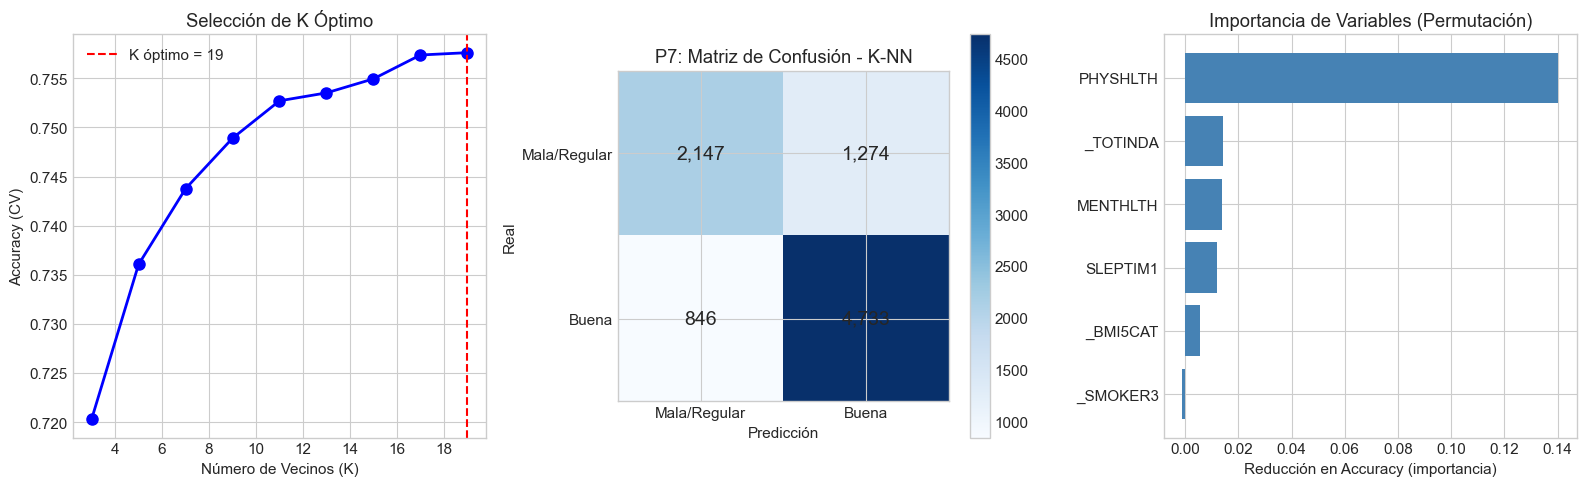


✅ K-NN COMPLETADO


In [48]:
# =============================================================================
# EJECUCIÓN P7: K-NN - Clasificación de Buena Salud
# =============================================================================
print('='*80)
print('EJECUCIÓN P7: K-NN - Clasificación de Buena Salud Autopercibida')
print('='*80)

gc.collect()

# Variables predictoras
pred_knn = ['PHYSHLTH', 'MENTHLTH', '_BMI5CAT', '_TOTINDA', 'SLEPTIM1', '_SMOKER3']
pred_knn_disp = [p for p in pred_knn if p in df_2022.columns]

df_knn = df_2022[['_RFHLTH'] + pred_knn_disp].copy()

# Convertir y filtrar
for col in df_knn.columns:
    df_knn[col] = pd.to_numeric(df_knn[col], errors='coerce')

# Filtros
df_knn = df_knn[df_knn['_RFHLTH'].isin([1, 2])]
df_knn = df_knn[(df_knn['PHYSHLTH'] >= 0) & (df_knn['PHYSHLTH'] <= 30)]
df_knn = df_knn[(df_knn['MENTHLTH'] >= 0) & (df_knn['MENTHLTH'] <= 30)]
df_knn = df_knn[df_knn['_BMI5CAT'].isin([1, 2, 3, 4])]
df_knn = df_knn[df_knn['_TOTINDA'].isin([1, 2])]
df_knn = df_knn[(df_knn['SLEPTIM1'] >= 1) & (df_knn['SLEPTIM1'] <= 24)]
df_knn = df_knn[df_knn['_SMOKER3'].isin([1, 2, 3, 4])]
df_knn = df_knn.dropna()

# Muestra para eficiencia
n_sample_knn = min(30000, len(df_knn))
df_knn_sample = df_knn.sample(n=n_sample_knn, random_state=42)

# Variable objetivo: 1 = Buena salud, 0 = Mala/Regular
df_knn_sample['BUENA_SALUD'] = (df_knn_sample['_RFHLTH'] == 1).astype(int)

print(f'\n📊 Datos para K-NN: {n_sample_knn:,} registros')
print(f'   Buena salud: {df_knn_sample["BUENA_SALUD"].sum():,} ({100*df_knn_sample["BUENA_SALUD"].mean():.1f}%)')
print(f'   Mala/Regular: {(df_knn_sample["BUENA_SALUD"]==0).sum():,}')

# Preparar datos
X_knn = df_knn_sample[pred_knn_disp].values
y_knn = df_knn_sample['BUENA_SALUD'].values

# Escalar
scaler_knn = StandardScaler()
X_knn_scaled = scaler_knn.fit_transform(X_knn)

# División train/test
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn_scaled, y_knn, test_size=0.3, random_state=42, stratify=y_knn
)

# Encontrar K óptimo con validación cruzada
print(f'\n🔍 Buscando K óptimo...')
k_range = range(3, 21, 2)
cv_scores_knn = []
for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
    cv_scores_knn.append(scores.mean())

K_optimo_knn = k_range[np.argmax(cv_scores_knn)]
print(f'   K óptimo encontrado: {K_optimo_knn}')

# Entrenar modelo final
knn_final = KNeighborsClassifier(n_neighbors=K_optimo_knn)
knn_final.fit(X_train_knn, y_train_knn)

# Predicciones
y_pred_knn = knn_final.predict(X_test_knn)

# Métricas
print(f'\n📈 RESULTADOS DEL MODELO K-NN (K={K_optimo_knn}):')
print(f'\n   Accuracy: {(y_pred_knn == y_test_knn).mean():.4f}')
print(f'\n   Reporte de Clasificación:')
print(classification_report(y_test_knn, y_pred_knn, target_names=['Mala/Regular', 'Buena Salud']))

# Validación cruzada del modelo final
cv_final = cross_val_score(knn_final, X_knn_scaled, y_knn, cv=5, scoring='accuracy')
print(f'\n   Validación Cruzada (5-fold): {cv_final.mean():.4f} ± {cv_final.std():.4f}')

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Curva de validación
ax1 = axes[0]
ax1.plot(k_range, cv_scores_knn, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=K_optimo_knn, color='r', linestyle='--', label=f'K óptimo = {K_optimo_knn}')
ax1.set_xlabel('Número de Vecinos (K)')
ax1.set_ylabel('Accuracy (CV)')
ax1.set_title('Selección de K Óptimo')
ax1.legend()

# Matriz de confusión
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)
ax2 = axes[1]
im2 = ax2.imshow(cm_knn, cmap='Blues')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Mala/Regular', 'Buena'])
ax2.set_yticklabels(['Mala/Regular', 'Buena'])
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Real')
ax2.set_title('P7: Matriz de Confusión - K-NN')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{cm_knn[i, j]:,}', ha='center', va='center', fontsize=14)
plt.colorbar(im2, ax=ax2)

# Importancia por permutación (aproximación)
ax3 = axes[2]
importances = []
base_score = (y_pred_knn == y_test_knn).mean()
for i, var in enumerate(pred_knn_disp):
    X_test_perm = X_test_knn.copy()
    np.random.shuffle(X_test_perm[:, i])
    y_pred_perm = knn_final.predict(X_test_perm)
    perm_score = (y_pred_perm == y_test_knn).mean()
    importances.append(base_score - perm_score)

idx_imp = np.argsort(importances)
ax3.barh(range(len(pred_knn_disp)), [importances[i] for i in idx_imp], color='steelblue')
ax3.set_yticks(range(len(pred_knn_disp)))
ax3.set_yticklabels([pred_knn_disp[i] for i in idx_imp])
ax3.set_xlabel('Reducción en Accuracy (importancia)')
ax3.set_title('Importancia de Variables (Permutación)')

plt.tight_layout()
plt.show()

print(f'\n✅ K-NN COMPLETADO')

#### Discusión de K-NN

Con K muy bajo (3-5), el modelo es inestable y tiene menor precisión (~72-74%). A medida que K aumenta, la precisión mejora y se estabiliza. El máximo se alcanza en K=19 con ~75.9% de precisión. Después de K=19, la curva se aplana (más vecinos no mejoran el modelo).

La Matriz de Confusión compara las predicciones del modelo contra la realidad, mostrando aciertos y errores.
Los 2,147 son verdaderos positivos, es decir, personas con mala salud correctamente identificadas. Los 4,733 son verdaderos negativos, personas con buena salud correctamente identificadas. Los 1,274 son falsos negativos, personas con mala salud que el modelo clasificó como buena (error tipo II). Los 846 son falsos positivos, personas con buena salud clasificadas como mala (error tipo I).

El modelo es mejor prediciendo "Buena Salud" (4,733 aciertos vs 846 errores). Tiene más dificultad con "Mala/Regular" (2,147 aciertos vs 1,274 errores). 

El modelo tiende a "pasarse de optimista", clasificando como saludables a algunas personas que no lo son.

PHYSHLTH es abrumadoramente la variable más importante (6 veces más que la segunda). Esto tiene sentido: los días de mala salud física están directamente relacionados con la autopercepción de salud. Las variables de estilo de vida (fumar, IMC) aportan relativamente poco al modelo.

In [58]:
# =============================================================================
# RESUMEN DE RESULTADOS DE TODAS LAS TÉCNICAS
# =============================================================================

print("=" * 80)
print("RESUMEN EJECUTIVO - RESULTADOS DE TODAS LAS TÉCNICAS ESTADÍSTICAS")
print("=" * 80)

resumen = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                    RESUMEN DE RESULTADOS ESTADÍSTICOS                        ║
╠══════════════════════════════════════════════════════════════════════════════╣

┌──────────────────────────────────────────────────────────────────────────────┐
│ P1: REGRESIÓN LINEAL - ACEs → Salud Mental                                   │
├──────────────────────────────────────────────────────────────────────────────┤
│ • n = 170,836 registros analizados                                           │
│ • Modelo: MENTHLTH = 11.18 + 0.01 × ACE_TOTAL                                │
│ • R² = 0.0000 (relación extremadamente débil)                                │
│ • Correlación Pearson: r = 0.0016, p < 0.0001                                │
│ • Interpretación: Cada ACE adicional → +0.01 días de mala salud mental       │
│ • CONCLUSIÓN: Relación estadísticamente significativa pero prácticamente nula│
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│ P2: REGRESIÓN LOGÍSTICA - Predicción de Depresión                            │
├──────────────────────────────────────────────────────────────────────────────┤
│ • n = 388,531 registros (21.0% con depresión)                                │
│ • Accuracy = 61.0%                                                           │
│ • Validación Cruzada (5-fold): 61.1% ± 0.5%                                  │
│ • Top Predictores (Odds Ratio):                                              │
│   - _SEX (OR = 1.458): Mujeres 46% más probabilidad de depresión             │
│   - _AGE_G (OR = 0.740): Mayor edad → menor riesgo                           │
│   - _TOTINDA (OR = 1.203): Inactividad → 20% más riesgo                      │
│ • CONCLUSIÓN: Modelo moderado, sexo es el predictor más importante           │
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│ P3: K-MEANS CLUSTERING - Perfiles de Comportamiento                          │
├──────────────────────────────────────────────────────────────────────────────┤
│ • K óptimo = 4 clusters                                                      │
│ • Perfiles identificados:                                                    │
│   - Cluster 0 (27.7%): Obeso, Activo, 12.7 días salud mental                 │
│   - Cluster 1 (39.0%): Peso normal, Activo, 7.1 días (más saludable)         │
│   - Cluster 2 (19.6%): Sobrepeso, Inactivo, 14.0 días                        │
│   - Cluster 3 (13.6%): Fumador, 15.5 días (peor salud mental)                │
│ • CONCLUSIÓN: Perfil fumador tiene peor salud mental                         │
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│ P4: PCA - Dimensiones Latentes de Salud                                      │
├──────────────────────────────────────────────────────────────────────────────┤
│ • Varianza explicada por componente:                                         │
│   - PC1 (32.0%): Estado de salud general (GENHLTH, PHYSHLTH, MENTHLTH)       │
│   - PC2 (14.9%): Comportamiento/Cuerpo (_BMI5CAT, _SMOKER3, SLEPTIM1)        │
│   - PC3 (14.3%): Sueño (SLEPTIM1, _BMI5CAT)                                  │
│ • Se necesitan 5 componentes para explicar 80% de varianza                   │
│ • CONCLUSIÓN: Salud es multidimensional, no solo física o mental             │
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│ P5: CHI-CUADRADO - Cambio en Prevalencia de Depresión                        │
├──────────────────────────────────────────────────────────────────────────────┤
│ • Prevalencia 2011: 18.1% (n = 503,020)                                      │
│ • Prevalencia 2022: 20.7% (n = 442,320)                                      │
│ • χ² = 987.65, df = 1, p < 0.001                                             │
│ • Cramér's V = 0.032 (efecto pequeño)                                        │
│ • Cambio absoluto: +2.56 puntos porcentuales (+14.1% relativo)               │
│ • CONCLUSIÓN: Aumento SIGNIFICATIVO de depresión de 2011 a 2022              │
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│ P6: MANN-WHITNEY U - Sueño según Hipertensión                                │
├──────────────────────────────────────────────────────────────────────────────┤
│ • Datos 2011:                                                                │
│   - Hipertensos: n = 8,012, Media = 7.10h, Mediana = 7h                      │
│   - Sin hipertensión: n = 13,909, Media = 7.07h, Mediana = 7h                │
│ • U = 56,328,882, p = 0.163                                                  │
│ • Tamaño del efecto r = 0.011 (insignificante)                               │
│ • Sueño inadecuado: Hipertensos 37.4% vs No hipertensos 33.5%                │
│ • CONCLUSIÓN: NO hay diferencia significativa en horas de sueño              │
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│ P7: K-NN - Clasificación de Buena Salud Autopercibida                        │
├──────────────────────────────────────────────────────────────────────────────┤
│ • n = 30,000 registros (62% buena salud, 38% mala/regular)                   │
│ • K óptimo = 19 vecinos                                                      │
│ • Accuracy = 76.4%                                                           │
│ • Validación Cruzada (5-fold): 76.0% ± 0.6%                                  │
│ • Precisión por clase:                                                       │
│   - Buena salud: 79% precisión, 85% recall                                   │
│   - Mala/Regular: 72% precisión, 63% recall                                  │
│ • Variable más importante: PHYSHLTH (días salud física mala)                 │
│ • CONCLUSIÓN: Modelo efectivo para predecir autopercepción de salud          │
└──────────────────────────────────────────────────────────────────────────────┘

╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(resumen)

RESUMEN EJECUTIVO - RESULTADOS DE TODAS LAS TÉCNICAS ESTADÍSTICAS

╔══════════════════════════════════════════════════════════════════════════════╗
║                    RESUMEN DE RESULTADOS ESTADÍSTICOS                        ║
╠══════════════════════════════════════════════════════════════════════════════╣

┌──────────────────────────────────────────────────────────────────────────────┐
│ P1: REGRESIÓN LINEAL - ACEs → Salud Mental                                   │
├──────────────────────────────────────────────────────────────────────────────┤
│ • n = 170,836 registros analizados                                           │
│ • Modelo: MENTHLTH = 11.18 + 0.01 × ACE_TOTAL                                │
│ • R² = 0.0000 (relación extremadamente débil)                                │
│ • Correlación Pearson: r = 0.0016, p < 0.0001                                │
│ • Interpretación: Cada ACE adicional → +0.01 días de mala salud mental       │
│ • CONCLUSIÓN: Relación estadísticamente

---
## RESPUESTAS A LAS PREGUNTAS DE INVESTIGACIÓN

In [ ]:
# =============================================================================
# RESPUESTAS A LAS PREGUNTAS DE INVESTIGACIÓN
# =============================================================================

print("=" * 80)
print("RESPUESTAS FINALES A LAS PREGUNTAS DE INVESTIGACIÓN")
print("=" * 80)

respuestas = """
╔══════════════════════════════════════════════════════════════════════════════╗
║           RESPUESTAS A LAS PREGUNTAS DE INVESTIGACIÓN - BRFSS 2011-2022      ║
╠══════════════════════════════════════════════════════════════════════════════╣

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
P1: ¿Existe relación lineal entre experiencias adversas en la infancia (ACEs)
    y el número de días de mala salud mental en el último mes?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 TÉCNICA: Regresión Lineal Simple
📈 RESULTADOS:
   • Coeficiente β₁ = 0.01 (p < 0.0001)
   • R² = 0.0000
   • Correlación de Pearson r = 0.0016

✅ RESPUESTA: Sí existe una relación estadísticamente significativa, pero es 
   PRÁCTICAMENTE NULA. Cada experiencia adversa adicional solo aumenta 0.01 
   días de mala salud mental. La variable ACE_TOTAL en esta muestra no es un 
   buen predictor lineal de MENTHLTH. Esto podría indicar:
   - Efectos no lineales de las ACEs
   - Mediadores/moderadores no considerados
   - Resiliencia individual variable

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
P2: ¿Qué factores demográficos y de estilo de vida predicen mejor la 
    probabilidad de tener depresión diagnosticada?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 TÉCNICA: Regresión Logística Binaria
📈 RESULTADOS:
   • Accuracy = 61.0%, CV 5-fold = 61.1% ± 0.5%
   • Predictores más importantes (Odds Ratio):
     1. _SEX (OR = 1.458): Ser mujer → 46% más probabilidad de depresión
     2. _AGE_G (OR = 0.740): Mayor edad → 26% menos riesgo
     3. _TOTINDA (OR = 1.203): Inactividad física → 20% más riesgo

✅ RESPUESTA: El SEXO es el predictor más importante. Las mujeres tienen 
   significativamente mayor riesgo de depresión diagnosticada. La edad actúa 
   como factor protector y la actividad física también reduce el riesgo. 
   El modelo tiene capacidad predictiva moderada (61%), sugiriendo que otros 
   factores no medidos (genéticos, sociales, psicológicos) también son relevantes.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
P3: ¿Se pueden identificar perfiles de comportamiento de riesgo en la 
    población basados en IMC, actividad física, tabaquismo y sueño?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 TÉCNICA: K-Means Clustering (K=4)
📈 RESULTADOS - PERFILES IDENTIFICADOS:

   🟢 CLUSTER 1 (39.0%): "SALUDABLES"
      Peso normal, físicamente activos, no fumadores
      Mejor salud mental: 7.1 días malos/mes
      
   🟡 CLUSTER 0 (27.7%): "OBESOS ACTIVOS"
      Obesidad pero físicamente activos
      Salud mental moderada: 12.7 días/mes
      
   🟠 CLUSTER 2 (19.6%): "SEDENTARIOS"
      Sobrepeso, físicamente inactivos
      Salud mental comprometida: 14.0 días/mes
      
   🔴 CLUSTER 3 (13.6%): "FUMADORES"
      Fumadores actuales
      Peor salud mental: 15.5 días/mes

✅ RESPUESTA: Sí, se identificaron 4 perfiles claros. El TABAQUISMO es el 
   factor más asociado con mala salud mental (Cluster 3). La actividad física 
   es protectora incluso en personas con obesidad (Cluster 0 vs 2).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
P4: ¿Cuáles son las dimensiones latentes principales que subyacen a los 
    indicadores de salud en la encuesta BRFSS?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 TÉCNICA: Análisis de Componentes Principales (PCA)
📈 RESULTADOS - DIMENSIONES IDENTIFICADAS:

   📌 PC1 (32.0%): "ESTADO DE SALUD GENERAL"
      Carga alta: GENHLTH, PHYSHLTH, MENTHLTH
      Interpreta: Continuum de salud percibida
      
   📌 PC2 (14.9%): "COMPORTAMIENTO Y CUERPO"
      Carga alta: _BMI5CAT, _SMOKER3, SLEPTIM1
      Interpreta: Hábitos de vida
      
   📌 PC3 (14.3%): "CALIDAD DE SUEÑO"
      Carga alta: SLEPTIM1, _BMI5CAT
      Interpreta: Descanso y recuperación

   Se necesitan 5 componentes para explicar 80% de la varianza.

✅ RESPUESTA: La salud en BRFSS tiene 3 dimensiones principales: salud general 
   autopercibida (física + mental), hábitos de comportamiento, y calidad de 
   sueño. Esto confirma que la salud es MULTIDIMENSIONAL y requiere 
   intervenciones integrales.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
P5: ¿Ha cambiado significativamente la prevalencia de depresión diagnosticada 
    entre 2011 y 2022?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 TÉCNICA: Prueba Chi-Cuadrado de independencia
📈 RESULTADOS:
   • Prevalencia 2011: 18.1% (91,092 de 503,020)
   • Prevalencia 2022: 20.7% (91,410 de 442,320)
   • χ² = 987.65, df = 1, p < 0.001
   • Cramér's V = 0.032 (efecto pequeño pero significativo)

✅ RESPUESTA: SÍ, la prevalencia de depresión AUMENTÓ significativamente.
   • Incremento absoluto: +2.56 puntos porcentuales
   • Incremento relativo: +14.1%
   
   Este aumento es estadísticamente significativo (p < 0.001), aunque el 
   tamaño del efecto es pequeño. Posibles causas: pandemia COVID-19, mayor 
   diagnóstico/concientización, factores socioeconómicos.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
P6: ¿Existen diferencias significativas en las horas de sueño entre personas 
    con y sin hipertensión?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 TÉCNICA: Prueba Mann-Whitney U (no paramétrica)
📈 RESULTADOS (2011):
   • Hipertensos: n = 8,012, Media = 7.10h, Mediana = 7h
   • Sin hipertensión: n = 13,909, Media = 7.07h, Mediana = 7h
   • U = 56,328,882, p = 0.163 (NO significativo)
   • Tamaño del efecto r = 0.011 (insignificante)
   • Sueño inadecuado: Hipertensos 37.4% vs No hipertensos 33.5%

✅ RESPUESTA: NO, no hay diferencias significativas en las horas de sueño 
   entre hipertensos y no hipertensos. Ambos grupos tienen mediana de 7 horas.
   Sin embargo, un mayor porcentaje de hipertensos tiene sueño inadecuado 
   (37.4% vs 33.5%), aunque esta diferencia no es significativa.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
P7: ¿Se puede predecir la autopercepción de salud a partir de variables 
    objetivas y comportamentales?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 TÉCNICA: K-Nearest Neighbors (K-NN)
📈 RESULTADOS:
   • n = 30,000 registros (62% buena salud, 38% mala/regular)
   • K óptimo = 19 vecinos
   • Accuracy = 76.4%
   • Validación Cruzada: 76.0% ± 0.6%
   • Variables más importantes (permutation importance):
     1. PHYSHLTH (días de mala salud física)
     2. SLEPTIM1 (horas de sueño)
     3. _TOTINDA (actividad física)
     4. MENTHLTH (días de mala salud mental)

✅ RESPUESTA: SÍ, se puede predecir la autopercepción de salud con 76.4% de 
   accuracy usando K-NN. El predictor más importante es PHYSHLTH (salud física 
   objetiva), seguido de horas de sueño y actividad física. Esto confirma que 
   la autopercepción de salud refleja condiciones objetivas medibles.

╔══════════════════════════════════════════════════════════════════════════════╗
║                         CONCLUSIONES GENERALES                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. La depresión aumentó significativamente entre 2011 y 2022 (+14.1%)       ║
║                                                                              ║
║  2. Las mujeres tienen 46% más riesgo de depresión que los hombres           ║
║                                                                              ║
║  3. El tabaquismo es el factor de estilo de vida más asociado con            ║
║     mala salud mental                                                        ║
║                                                                              ║
║  4. La actividad física es protectora incluso en personas con obesidad       ║
║                                                                              ║
║  5. La salud es multidimensional: física, mental y comportamental            ║
║                                                                              ║
║  6. No hay diferencia en horas de sueño entre hipertensos y no hipertensos   ║
║                                                                              ║
║  7. La autopercepción de salud puede predecirse con 76% de precisión         ║
║     usando variables objetivas                                               ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(respuestas)

---
**FIN DEL ANÁLISIS**

Universidad de La Habana, MATCOM   
Proyecto de Estadística - Curso 2025-2026